## Step 1 — Imports

In [1]:
# ── Cell 1 — Imports ──────────────────────────────────────────────────────────
import textwrap
from collections import Counter

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy.stats import chisquare

## Step 2 — Configuration and Constants

In [2]:
# ── Cell 2 — Configuration and Constants ──────────────────────────────────────

FILE_PATH = "./data/Survey_SoftwareDevelopmentInEraGenAI_polished.xlsx"
SHEETS: dict = {}

# ── Visual style constants ─────────────────────────────────────────────────────
BG_COLOR      = "#F7F9FC"
TITLE_COLOR   = "#2C3E50"
FOOTNOTE_COLOR= "#7F8C8D"
GRID_COLOR    = "#D5DCE8"
SPINE_COLOR   = "#C0C8D4"
AXIS_LBL_COLOR= "#5A6475"

PALETTE = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3",
    "#937860", "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD",
]

# ── Scale definitions ──────────────────────────────────────────────────────────
SCALE_USEFULNESS = {
    "order":  ["Not Useful", "Somewhat Useful", "Very Useful", "Essential"],
    "na":     "Not Applicable",
    "colors": ["#C44E52", "#DD8452", "#4C72B0", "#2A6099"],
}

SCALE_IMPORTANCE_CHANGE = {
    "order":  ["Decreasing in Importance", "No Change",
               "Slightly Increasing", "Strongly Increasing"],
    "na":     None,
    "colors": ["#C44E52", "#8C8C8C", "#55A868", "#2A6099"],
}

# ── Question registry ──────────────────────────────────────────────────────────
QUESTION_REGISTRY = {
    "Q01": {"type": "multi",   "label": "Primary role in software development"},
    "Q02": {
        "type": "single", "label": "Years of experience",
        "order": ["< 1 year", "1 - 3 years", "4 - 6 years",
                  "7 - 10 years", "> 10 years"],
    },
    "Q03": {
        "type": "single", "label": "Organisation size",
        "order": ["Startup (1-10 employees)", "Small (11-50 employees)",
                  "Medium Business (51-100 employees)",
                  "Large Enterprise (100+ employees)"],
    },
    "Q04": {"type": "multi",   "label": "Primary programming languages"},
    "Q05": {"type": "single",  "label": "Highest education level (Dutch system)"},
    "Q06": {
        "type": "single", "label": "Highest academic qualification",
        "order": ["Associate degree", "Bachelor's degree (BSc, BA, etc.)",
                  "Master's degree (MSc, MA, etc.)", "PhD (Doctorate)"],
    },
    "Q07": {"type": "single",  "label": "Organisation's stance on AI tools"},
    "Q08": {
        "type": "single", "label": "Frequency of GenAI tool usage",
        "order": ["Rarely (a few times a month)",
                  "Occasionally (a few times a week)",
                  "Regularly (daily or almost daily)"],
    },
    "Q09": {"type": "multi",   "label": "Tasks where GenAI is used"},
    "Q10": {
        "type": "scaling", "label": "Usefulness of GenAI per task",
        "scale": SCALE_USEFULNESS,
    },
    "Q11": {"type": "multi",   "label": "Common issues experienced with GenAI"},
    "Q12": {
        "type": "single", "label": "Estimated % of AI-assisted developer work (5 yrs)",
        "order": ["21% - 40%", "41 % - 60 %", "61 % - 80 %", "More than 80 %"],
    },
    "Q13": {"type": "multi",   "label": "SDLC phases where GenAI will have most impact"},
    "Q14": {
        "type": "scaling", "label": "Expected change in skill importance",
        "scale": SCALE_IMPORTANCE_CHANGE,
    },
    "Q16": {"type": "multi",   "label": "Most essential skills for future developers"},
    "Q17": {"type": "multi",   "label": "Main challenges in AI-assisted development"},
    "Q18": {
        "type": "single", "label": "Trust in AI-generated code without review",
        "order": ["Not at all", "Somewhat", "Mostly"],
    },
    "Q19": {"type": "single",  "label": "Will AI replace traditional development roles?"},
    "Q20": {"type": "single",  "label": "AI impact on junior developer learning curve"},
    "Q21": {"type": "open",    "label": "Greatest risk of heavy reliance on AI-generated code"},
    "Q22": {"type": "open",    "label": "How hiring will change with mainstream AI tools"},
    "Q23": {"type": "open",    "label": "Additional comments on AI in software development"},
}

## Step 3 — Data Loading and Parsing Helpers

In [3]:
# ── Cell 3 — Data Loading and Parsing Helpers ─────────────────────────────────

def load_data(path: str) -> dict:
    """Read all sheets from the Excel file, update SHEETS in-place, return it."""
    global SHEETS
    loaded = pd.read_excel(path, sheet_name=None, header=None)
    SHEETS.update(loaded)
    print(f"Loaded {len(SHEETS)} sheets: {list(SHEETS.keys())}")
    return SHEETS


def _split_choices(cell_value) -> list[str]:
    """Split a semicolon-delimited cell into a clean list, discarding empty strings."""
    return [c.strip() for c in str(cell_value).split(";") if c.strip()]


def _get_responses(qid: str) -> pd.Series:
    """Return the raw response column for a standard question as a clean Series.

    Drops NaN, casts to str. Covers column 1, rows 2 onward (0-indexed row 1+).
    """
    return SHEETS[qid].iloc[1:, 1].dropna().astype(str).reset_index(drop=True)


def get_standard_question(qid: str) -> pd.DataFrame:
    """Return DataFrame [id, response] for single / multi / open questions."""
    df = SHEETS[qid].iloc[1:].copy()
    df.columns = ["id", "response"]
    return df.reset_index(drop=True)


def get_scaling_question(qid: str) -> pd.DataFrame:
    """Return DataFrame (id as index, item labels as columns) for Q10 / Q14.

    Cleans non-breaking spaces (\\xa0) from item labels.
    """
    raw     = SHEETS[qid]
    options = [str(o).replace("\xa0", " ").strip() for o in raw.iloc[1, 1:].tolist()]
    df      = raw.iloc[2:].copy()
    df.columns = ["id"] + options
    return df.set_index("id")


def get_multichoice(qid: str) -> pd.DataFrame:
    """Return DataFrame [id, response, choices] where choices is a list of strings."""
    df = get_standard_question(qid)
    df["choices"] = df["response"].apply(
        lambda x: _split_choices(x) if pd.notna(x) else []
    )
    return df


def _flat_choices(qid: str) -> tuple[pd.Series, int]:
    """Return (flat Series of all choices, n_respondents) for a multi-choice question.

    n_respondents = rows with any response (denominator for % calculations).
    """
    raw        = SHEETS[qid].iloc[1:, 1].dropna().astype(str)
    n_resp     = len(raw)
    all_choices = [choice for cell in raw for choice in _split_choices(cell)]
    return pd.Series(all_choices), n_resp


# ── Load data immediately ──────────────────────────────────────────────────────
SHEETS = load_data(FILE_PATH)  # FILE_PATH must be defined in Cell 2 before running this cell

Loaded 24 sheets: ['complete', 'Q01', 'Q02', 'Q03', 'Q04', 'Q05', 'Q06', 'Q07', 'Q08', 'Q09', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23']


## Step 4 — Validation

In [4]:
# ── Cell 4 — Validation ───────────────────────────────────────────────────────

def validate(sheets: dict) -> None:
    """Run data-integrity checks and print PASS / FAIL per assertion."""

    def _check(label: str, actual, expected) -> None:
        status = "PASS" if actual == expected else "FAIL"
        print(f"  [{status}] {label}")
        if status == "FAIL":
            print(f"         expected : {expected}")
            print(f"         actual   : {actual}")

    def _check_contains(label: str, haystack: str, *needles: str) -> None:
        ok = all(n in haystack for n in needles)
        print(f"  [{'PASS' if ok else 'FAIL'}] {label}")
        if not ok:
            missing = [n for n in needles if n not in haystack]
            print(f"         missing  : {missing}")
            print(f"         actual   : {haystack[:120]}")

    print("=" * 60)
    print("VALIDATION")
    print("=" * 60)

    # Q10 id=3 — scaling
    df10 = get_scaling_question("Q10")
    row3 = df10.loc[3].dropna().to_dict()
    _check("Q10 id=3 — Brainstorming",
           row3.get("Brainstorming"), "Somewhat Useful")
    _check("Q10 id=3 — Code generation / auto-completion",
           row3.get("Code generation / auto-completion"), "Very Useful")
    _check("Q10 id=3 — Code Documentation",
           row3.get("Code Documentation"), "Very Useful")
    non_na_items = {k: v for k, v in row3.items() if v != "Not Applicable"}
    _check("Q10 id=3 — all others Not Applicable",
           set(non_na_items.keys()),
           {"Brainstorming", "Self-development and Learning",
            "Code generation / auto-completion", "Refactoring existing code",
            "Test / Test case generation", "Code Documentation"})

    # Q10 id=24 — scaling
    row24 = df10.loc[24].dropna().to_dict()
    _check("Q10 id=24 — Brainstorming",
           row24.get("Brainstorming"), "Very Useful")
    _check("Q10 id=24 — Code generation / auto-completion",
           row24.get("Code generation / auto-completion"), "Essential")
    _check("Q10 id=24 — only 2 answers given", len(row24), 2)

    # Q08 id=2 — single
    df8  = get_standard_question("Q08")
    val8 = df8[df8["id"] == 2]["response"].values[0]
    _check("Q08 id=2", val8, "Regularly (daily or almost daily)")

    # Q23 id=6 — open
    df23 = get_standard_question("Q23")
    val23 = df23[df23["id"] == 6]["response"].values[0]
    _check_contains("Q23 id=6 contains expected phrases",
                    val23, "Low-Code is dead", "Context Engineering")

    # Q16 id=14 — multi-choice
    df16    = get_multichoice("Q16")
    choices = df16[df16["id"] == 14]["choices"].values[0]
    _check("Q16 id=14 — choice count", len(choices), 3)
    _check("Q16 id=14 — choice 1",
           "Critical thinking and code review skills" in choices, True)
    _check("Q16 id=14 — choice 2",
           "Secure coding and ethical AI awareness" in choices, True)
    _check("Q16 id=14 — choice 3",
           "Data privacy and regulatory compliance awareness" in choices, True)

    print("=" * 60)


validate(SHEETS)

VALIDATION
  [PASS] Q10 id=3 — Brainstorming
  [PASS] Q10 id=3 — Code generation / auto-completion
  [PASS] Q10 id=3 — Code Documentation
  [PASS] Q10 id=3 — all others Not Applicable
  [PASS] Q10 id=24 — Brainstorming
  [PASS] Q10 id=24 — Code generation / auto-completion
  [PASS] Q10 id=24 — only 2 answers given
  [PASS] Q08 id=2
  [PASS] Q23 id=6 contains expected phrases
  [PASS] Q16 id=14 — choice count
  [PASS] Q16 id=14 — choice 1
  [PASS] Q16 id=14 — choice 2
  [PASS] Q16 id=14 — choice 3


## Step 5 — Statistical Analysis Helpers

In [5]:
# ── Cell 5 — Statistical Analysis Helpers ─────────────────────────────────────

def _wilson_ci(n_success: int, n_total: int, z: float = 1.96) -> tuple[float, float]:
    """Wilson score 95 % confidence interval for a proportion.

    Returns (lower, upper). Returns (0.0, 0.0) when n_total = 0.
    """
    if n_total == 0:
        return (0.0, 0.0)
    p      = n_success / n_total
    denom  = 1 + z ** 2 / n_total
    centre = p + z ** 2 / (2 * n_total)
    margin = z * np.sqrt((p * (1 - p) + z ** 2 / (4 * n_total)) / n_total)
    return (round((centre - margin) / denom, 4),
            round((centre + margin) / denom, 4))


def _shannon_entropy(counts_array: list) -> tuple[float, float]:
    """Return (entropy_bits, normalised_entropy ∈ [0, 1]).

    Normalised: 0 = full consensus, 1 = uniform distribution.
    Zero counts are ignored (contribute 0 to entropy).
    """
    total = sum(counts_array)
    if total == 0:
        return 0.0, 0.0
    probs  = np.array([c / total for c in counts_array if c > 0])
    h      = float(-np.sum(probs * np.log2(probs)))
    h_max  = np.log2(len(counts_array))
    h_norm = round(h / h_max, 4) if h_max > 0 else 0.0
    return round(h, 4), h_norm


def _chi2_uniform(counts_array: list) -> tuple[float | None, float | None]:
    """Chi-squared goodness-of-fit against a uniform distribution.

    Returns (None, None) when fewer than 2 categories.
    """
    if len(counts_array) < 2:
        return None, None
    chi2, p = chisquare(counts_array)
    return round(float(chi2), 4), round(float(p), 6)


def _ordinal_stats(values_series: pd.Series, scale_map: dict) -> dict:
    """Map text labels → scores; return descriptive stats + bootstrap CI on mean.

    Parameters
    ----------
    values_series : Series of text labels (may include unmapped values, which are dropped)
    scale_map     : dict mapping label → integer score (1-indexed, low → high)

    Returns dict with keys: n, mean, std, median, mean_ci_95.
    Bootstrap uses n_boot=2000, seed=42.
    """
    numeric = values_series.map(scale_map).dropna()
    if numeric.empty:
        return {}
    n   = len(numeric)
    rng = np.random.default_rng(42)
    boot_means = [
        rng.choice(numeric.values, size=n, replace=True).mean()
        for _ in range(2000)
    ]
    lo, hi = np.percentile(boot_means, [2.5, 97.5])
    return {
        "n":          n,
        "mean":       round(float(numeric.mean()), 3),
        "std":        round(float(numeric.std(ddof=1)), 3),
        "median":     round(float(numeric.median()), 3),
        "mean_ci_95": (round(lo, 3), round(hi, 3)),
    }

## Step 6 — Statistical Analysis: Public Function and Report Printers

In [6]:
# ── Cell 6 — Statistical Analysis: Public Function and Report Printers ─────────

def _print_separator(width: int = 74, char: str = "─") -> None:
    """Print a horizontal rule of given width and character."""
    print(char * width)


def _print_categorical_report(results: dict) -> None:
    """Print frequency table + entropy + χ² for single / multi questions."""
    qid, qtype = results["qid"], results["question_type"]
    q_wrapped  = "\n  ".join(textwrap.wrap(results["question"], 70))

    print(f"\n{'═' * 74}")
    print(f"  {qid}  [{qtype}]")
    print(f"  {q_wrapped}")
    print(f"{'═' * 74}")
    extra = (f"   |   Total selections: {results['n_answers']}"
             if results["n_answers"] != results["n_respondents"] else "")
    print(f"  Respondents: {results['n_respondents']}{extra}")
    _print_separator()
    print(f"  {'Category':<46} {'n':>4}  {'%':>6}  {'95 % CI (Wilson)':>18}")
    _print_separator()

    for cat, cnt in results["counts"].items():
        pct    = results["proportions"][cat] * 100
        lo, hi = results["wilson_ci_95"][cat]
        label  = (cat[:43] + "...") if len(cat) > 46 else cat
        print(f"  {label:<46} {cnt:>4}  {pct:>5.1f}%  [{lo:.3f}, {hi:.3f}]")

    _print_separator()
    print(f"  Dominant    : {results['dominant_category']}")
    h_b, h_n = results["entropy_bits"], results["entropy_norm"]
    print(f"  Entropy     : {h_b:.3f} bits  (normalised: {h_n:.3f}  — 0=consensus, 1=uniform)")
    chi2, p = results["chi2_uniform"], results["p_uniform"]
    if chi2 is not None:
        sig = "✓ significant" if p < 0.05 else "✗ not significant"
        print(f"  χ² (uniform): {chi2:.3f}   p = {p:.4f}  → {sig} at α = 0.05")
    print()


def _print_scaling_report(results: dict) -> None:
    """Print per-item distribution blocks + ordinal stats for scaling questions."""
    qid = results["qid"]
    q_wrapped = "\n  ".join(textwrap.wrap(results["question"], 84))

    print(f"\n{'═' * 88}")
    print(f"  {qid}  [scaling]")
    print(f"  {q_wrapped}")
    print(f"  Scale: {' → '.join(results['scale_order'])}")
    print(f"{'═' * 88}")
    print(f"  n = {results['n_respondents']} respondents\n")

    for item, d in results["items"].items():
        label = (item[:34] + "..") if len(item) > 36 else item
        dist  = "  ".join(
            f"{lvl[:12]}: {d['counts'][lvl]:>2} ({d['proportions'][lvl]*100:.0f}%)"
            for lvl in results["scale_order"]
        )
        os = d["ordinal_stats"]
        print(f"  ┌─ {label}")
        print(f"  │  {dist}")
        if os:
            print(f"  │  mean={os['mean']} CI{os['mean_ci_95']}  "
                  f"median={os['median']}  std={os['std']}")
        print(f"  │  dominant='{d['dominant_level']}'  "
              f"positive={d['positive_pct']}%  "
              f"entropy={d['entropy_bits']:.3f} bits  "
              f"N/A={d['n_na']}")
        print()


def analyse_question(
    sheets: dict,
    qid: str,
    question_type: str,
    *,
    top_n: int = None,
    scale: dict = None,
    na_label: str = None,
    print_report: bool = True,
    return_results: bool = False,
) -> dict | None:
    """Compute statistical summary for a survey question.

    Parameters
    ----------
    sheets        : SHEETS dict
    qid           : sheet key, e.g. 'Q08'
    question_type : 'single' | 'multi' | 'scaling'
    top_n         : keep only top-N categories (categorical types)
    scale         : scale dict (required for 'scaling')
    na_label      : override scale['na'] when supplied directly
    print_report  : print formatted report to stdout
    return_results: return results dict when True

    Returns dict or None.
    """
    results = {"qid": qid, "question_type": question_type}

    # ── categorical: single / multi ───────────────────────────────────────────
    if question_type in ("single", "multi"):
        question = str(sheets[qid].iloc[0, 1])
        if question_type == "multi":
            choices, n_resp = _flat_choices(qid)
        else:
            choices = _get_responses(qid)
            n_resp  = len(choices)

        counts_raw = Counter(choices)
        counts     = dict(counts_raw.most_common(top_n) if top_n
                          else counts_raw.most_common())
        n_answers  = sum(counts.values())
        props      = {k: round(v / n_resp, 4) for k, v in counts.items()}
        ci         = {k: _wilson_ci(v, n_resp) for k, v in counts.items()}
        h_bits, h_norm = _shannon_entropy(list(counts.values()))
        chi2, p_val    = _chi2_uniform(list(counts.values()))

        results.update({
            "question":          question,
            "n_respondents":     n_resp,
            "n_answers":         n_answers,
            "counts":            counts,
            "proportions":       props,
            "wilson_ci_95":      ci,
            "dominant_category": max(counts, key=counts.get),
            "entropy_bits":      h_bits,
            "entropy_norm":      h_norm,
            "chi2_uniform":      chi2,
            "p_uniform":         p_val,
        })
        if print_report:
            _print_categorical_report(results)

    # ── scaling ───────────────────────────────────────────────────────────────
    elif question_type == "scaling":
        if scale is None:
            raise ValueError("Provide a `scale` dict for question_type='scaling'.")

        scale_order = scale["order"]
        na          = na_label or scale.get("na")
        question    = str(sheets[qid].iloc[0, 1])
        df          = get_scaling_question(qid)
        n_resp      = df.shape[0]
        scale_map   = {lvl: i + 1 for i, lvl in enumerate(scale_order)}

        items_data: dict = {}
        for item in df.columns:
            col   = df[item].dropna().astype(str)
            na_n  = int((col == na).sum()) if na else 0
            valid = col[col != na] if na else col
            n_v   = len(valid)

            counts = {lvl: int((valid == lvl).sum()) for lvl in scale_order}
            props  = {lvl: round(counts[lvl] / n_v, 4) if n_v else 0.0
                      for lvl in scale_order}
            pos_pct = round(
                sum(counts.get(l, 0) for l in scale_order[-2:]) / n_v * 100, 1
            ) if n_v else 0.0
            h_bits, h_norm = _shannon_entropy(list(counts.values()))

            items_data[item] = {
                "n_valid":        n_v,
                "n_na":           na_n,
                "counts":         counts,
                "proportions":    props,
                "dominant_level": max(counts, key=counts.get),
                "positive_pct":   pos_pct,
                "ordinal_stats":  _ordinal_stats(valid, scale_map),
                "entropy_bits":   h_bits,
                "entropy_norm":   h_norm,
            }

        results.update({
            "question":      question,
            "n_respondents": n_resp,
            "scale_order":   scale_order,
            "items":         items_data,
        })
        if print_report:
            _print_scaling_report(results)

    else:
        raise ValueError(
            f"Unknown question_type='{question_type}'. "
            "Use 'single', 'multi', or 'scaling'."
        )

    return results if return_results else None

## Step 7 — Visualisation Helpers

In [7]:
# ── Cell 7 — Visualisation Helpers ────────────────────────────────────────────

def _fig_setup(figsize: tuple) -> tuple[plt.Figure, plt.Axes]:
    """Create a figure and single axes with the shared background colour."""
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor(BG_COLOR)
    return fig, ax


def _style_axes(ax: plt.Axes) -> None:
    """Apply shared axis styling: remove noisy spines, set grid and tick params."""
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(SPINE_COLOR)
    ax.grid(axis="x", color=GRID_COLOR, linewidth=0.7, linestyle="--", zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis="y", length=0, labelsize=8.5)
    ax.tick_params(axis="x", labelsize=8)


def _add_title(ax: plt.Axes, qid: str, question: str, wrap_width: int = 80) -> None:
    """Add a bold, left-aligned QID-prefixed title to the axes."""
    wrapped = "\n".join(textwrap.wrap(question, width=wrap_width))
    ax.set_title(
        f"{qid}  |  {wrapped}",
        fontsize=9.5, fontweight="bold", color=TITLE_COLOR,
        loc="left", pad=10,
    )


def _add_footnote(fig: plt.Figure, text: str) -> None:
    """Add a small grey footnote at the bottom-left of the figure."""
    fig.text(0.0, -0.02, text, fontsize=7.5, color=FOOTNOTE_COLOR)


def _save_or_show(fig: plt.Figure, save_path: str | None) -> None:
    """Save figure to file or show interactively; always close afterwards."""
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"Saved → {save_path}")
    else:
        plt.show()
    plt.close(fig)


def _wrap_labels(labels: list[str], width: int) -> list[str]:
    """Wrap each label to `width` characters; return list of newline-joined strings."""
    return ["\n".join(textwrap.wrap(lbl, width=width)) for lbl in labels]


def _annotate_bar(
    ax: plt.Axes,
    bar,
    value: int,
    pct: float,
    x_max: float,
    show_pct: bool,
) -> None:
    """Annotate a horizontal bar with count and optional percentage at its right edge."""
    label = f"  {value}  ({pct:.0f}%)" if show_pct else f"  {value}"
    ax.text(
        bar.get_width() + x_max * 0.01,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center", ha="left",
        fontsize=8, color=TITLE_COLOR, fontweight="bold",
    )

## Step 8 — Visualisation: Pie Chart (single-choice)

In [8]:
# ── Cell 8 — Visualisation: Pie Chart (single-choice) ─────────────────────────

def plot_pie(
    sheets: dict,
    qid: str,
    *,
    order: list = None,
    colors: list = None,
    min_pct_label: float = 3.0,
    figsize: tuple = (8, 5),
    save_path: str = None,
) -> None:
    """Pie chart with right-hand legend for single-choice questions.

    Parameters
    ----------
    order         : enforced slice order; unmatched labels appended by frequency
    colors        : override PALETTE
    min_pct_label : suppress inline % label for slices smaller than this %
    """
    question  = str(sheets[qid].iloc[0, 1])
    responses = _get_responses(qid)
    n_resp    = len(responses)
    counts    = Counter(responses)

    labels = (
        [o for o in order if o in counts] +
        [k for k in sorted(counts, key=lambda k: -counts[k]) if k not in (order or [])]
    ) if order else sorted(counts, key=lambda k: -counts[k])

    sizes = [counts[l] for l in labels]
    clrs  = (colors or PALETTE)[:len(labels)]

    fig, (ax_pie, ax_leg) = plt.subplots(
        1, 2, figsize=figsize,
        gridspec_kw={"width_ratios": [1, 1]},
    )
    fig.patch.set_facecolor(BG_COLOR)
    ax_pie.set_facecolor(BG_COLOR)
    ax_leg.set_facecolor(BG_COLOR)

    def _autopct(pct):
        return f"{pct:.1f}%" if pct >= min_pct_label else ""

    _, _, autotexts = ax_pie.pie(
        sizes, labels=None, colors=clrs,
        autopct=_autopct, startangle=140, pctdistance=0.75,
        wedgeprops={"linewidth": 1.2, "edgecolor": "white"},
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_color("white")
        at.set_fontweight("bold")

    ax_leg.axis("off")
    handles = [
        mpatches.Patch(
            color=clr,
            label="\n".join(lbl[i:i+40] for i in range(0, len(lbl), 40))
                  + f"\n  n={sz}  ({sz/n_resp*100:.1f}%)",
        )
        for lbl, sz, clr in zip(labels, sizes, clrs)
    ]
    ax_leg.legend(handles=handles, loc="center left", frameon=False,
                  fontsize=8.5, labelspacing=1.0,
                  handleheight=1.4, handlelength=1.2)

    wrapped_q = "\n".join(textwrap.wrap(question, width=70))
    fig.suptitle(f"{qid}  |  {wrapped_q}", fontsize=10, fontweight="bold",
                 color=TITLE_COLOR, x=0.5, y=1.02, ha="center")
    _add_footnote(fig, f"Total responses: {n_resp}")
    plt.tight_layout()
    _save_or_show(fig, save_path)

## Step 9 — Visualisation: Horizontal Bar Chart (multi-choice)

In [9]:
# ── Cell 9 — Visualisation: Horizontal Bar Chart (multi-choice) ───────────────

def plot_multichoice(
    sheets: dict,
    qid: str,
    *,
    order: list = None,
    top_n: int = None,
    wrap_width: int = 42,
    show_pct: bool = True,
    color: str = None,
    figsize: tuple = None,
    save_path: str = None,
) -> None:
    """Horizontal bar chart for multiple-choice questions.

    Parameters
    ----------
    order      : enforced bar order (top → bottom); unmatched appended by frequency
    top_n      : show only the N most frequent choices
    wrap_width : max chars before wrapping y-axis labels
    show_pct   : annotate bars with '(x%)' where x = % of respondents
    color      : single bar colour; defaults to PALETTE[0]
    """
    question         = str(sheets[qid].iloc[0, 1])
    choices, n_resp  = _flat_choices(qid)
    counts           = Counter(choices)

    # Build label order: ascending so top of rendered chart = most common
    if order:
        labels = (
            [o for o in order if o in counts] +
            [k for k in sorted(counts, key=counts.get) if k not in order]
        )
    else:
        labels = sorted(counts, key=counts.get)   # ascending

    if top_n:
        top_set = {k for k, _ in counts.most_common(top_n)}
        labels  = [l for l in labels if l in top_set]

    values  = [counts[l] for l in labels]
    pcts    = [v / n_resp * 100 for v in values]
    x_max   = max(values) if values else 1
    n_bars  = len(labels)

    if figsize is None:
        figsize = (10, max(3.5, 0.55 * n_bars + 1.5))

    fig, ax = _fig_setup(figsize)
    _style_axes(ax)

    bar_color = color or PALETTE[0]
    bars      = ax.barh(_wrap_labels(labels, wrap_width), values,
                        color=bar_color, edgecolor="white",
                        linewidth=0.8, height=0.6)

    for bar, v, pct in zip(bars, values, pcts):
        _annotate_bar(ax, bar, v, pct, x_max, show_pct)

    ax.set_xlim(0, x_max * 1.22)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_xlabel("Number of respondents", fontsize=8.5, color=AXIS_LBL_COLOR)

    _add_title(ax, qid, question, wrap_width=80)
    _add_footnote(
        fig,
        f"n = {n_resp} respondents  •  % = share of respondents  "
        "•  multiple selections allowed",
    )
    plt.tight_layout()
    _save_or_show(fig, save_path)

## Step 10 — Visualisation: Stacked Bar Chart (scaling)

In [10]:
# ── Cell 10 — Visualisation: Stacked Bar Chart (scaling) ─────────────────────

def _positive_pct(counts: dict, scale_order: list, n_valid: int) -> float:
    """Return share of top-2 positive levels as a float 0–100."""
    pos = sum(counts.get(l, 0) for l in scale_order[-2:])
    return pos / n_valid if n_valid else 0.0


def plot_scaling(
    sheets: dict,
    qid: str,
    scale: dict,
    *,
    item_order: list = None,
    top_n: int = None,
    wrap_width: int = 38,
    show_na_bar: bool = True,
    show_counts: bool = True,
    min_seg_pct: float = 6.0,
    figsize: tuple = None,
    save_path: str = None,
) -> None:
    """100 % stacked horizontal bar chart for scaling / Likert-matrix questions.

    Parameters
    ----------
    scale        : SCALE_* dict with keys 'order', 'colors', 'na'
    item_order   : pin row order (top → bottom); unmatched appended by positive %
    top_n        : show only the N items with highest positive response share
    show_na_bar  : print 'N/A=n' annotation at right edge when applicable
    show_counts  : annotate segments with count when segment ≥ min_seg_pct %
    min_seg_pct  : minimum segment width (%) for showing a count annotation
    """
    question    = str(sheets[qid].iloc[0, 1])
    df          = get_scaling_question(qid)
    scale_order = scale["order"]
    na_label    = scale.get("na")
    colors      = scale["colors"]
    items       = list(df.columns)

    # Pre-compute per-item stats
    stats: dict = {}
    for item in items:
        col   = df[item].dropna().astype(str)
        na_n  = int((col == na_label).sum()) if na_label else 0
        valid = col[col != na_label] if na_label else col
        n_v   = len(valid)
        counts = {lvl: int((valid == lvl).sum()) for lvl in scale_order}
        stats[item] = {"counts": counts, "n_valid": n_v, "na_n": na_n}

    # Determine row order
    if item_order:
        ordered = (
            [i for i in item_order if i in stats] +
            [i for i in items if i not in item_order]
        )
    else:
        ordered = sorted(
            items,
            key=lambda i: _positive_pct(stats[i]["counts"], scale_order,
                                         stats[i]["n_valid"]),
        )  # ascending → most positive ends up at top of chart

    if top_n:
        ordered = sorted(
            ordered,
            key=lambda i: _positive_pct(stats[i]["counts"], scale_order,
                                         stats[i]["n_valid"]),
        )[-top_n:]

    n_rows = len(ordered)
    if figsize is None:
        figsize = (12, max(4.0, 0.52 * n_rows + 2.2))

    fig, ax = _fig_setup(figsize)
    _style_axes(ax)

    y_pos = np.arange(n_rows)

    for yi, item in enumerate(ordered):
        d      = stats[item]
        n_v    = d["n_valid"] if d["n_valid"] > 0 else 1
        x_left = 0.0

        for lvl, clr in zip(scale_order, colors):
            n   = d["counts"].get(lvl, 0)
            pct = n / n_v * 100
            ax.barh(yi, pct, left=x_left, height=0.62,
                    color=clr, edgecolor="white", linewidth=0.6)
            if show_counts and pct >= min_seg_pct:
                ax.text(x_left + pct / 2, yi, str(n),
                        ha="center", va="center",
                        fontsize=7.5, color="white", fontweight="bold")
            x_left += pct

        if show_na_bar and na_label and d["na_n"] > 0:
            ax.text(102, yi, f"N/A={d['na_n']}",
                    va="center", ha="left", fontsize=7, color=FOOTNOTE_COLOR)

    ax.set_xlim(0, 100)
    ax.set_ylim(-0.6, n_rows - 0.4)
    ax.set_xlabel("% of valid respondents", fontsize=8.5, color=AXIS_LBL_COLOR)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.set_yticks(y_pos)
    ax.set_yticklabels(_wrap_labels(ordered, wrap_width))

    # Legend above chart
    handles = [mpatches.Patch(color=c, label=l)
               for c, l in zip(colors, scale_order)]
    ax.legend(handles=handles, loc="lower right",
              bbox_to_anchor=(1.0, 1.01), ncol=len(scale_order),
              frameon=False, fontsize=8)

    _add_title(ax, qid, question, wrap_width=90)
    note = f"n = {df.shape[0]} respondents"
    if na_label:
        note += "  •  % excludes 'Not Applicable' responses"
    _add_footnote(fig, note)
    plt.tight_layout()
    _save_or_show(fig, save_path)

## Step 11 — Dispatcher

In [11]:
# ── Cell 11 — Dispatcher ──────────────────────────────────────────────────────

def _display_open(sheets: dict, qid: str, meta: dict) -> None:
    """Print question text and all responses verbatim, numbered.

    Handles both plain-text and semicolon-delimited open responses.
    """
    question = str(sheets[qid].iloc[0, 1])
    raw      = sheets[qid].iloc[1:, 1].dropna().astype(str)
    is_multi = raw.str.contains(";").any()

    responses = (
        [choice for cell in raw for choice in _split_choices(cell)]
        if is_multi else raw.tolist()
    )

    q_wrapped = "\n  ".join(textwrap.wrap(question, 74))
    print(f"\n{'═' * 78}")
    print(f"  {qid}  [open-ended]  —  {meta['label']}")
    print(f"  {q_wrapped}")
    print(f"{'═' * 78}")
    print(f"  {len(responses)} response(s)\n")
    for i, resp in enumerate(responses, 1):
        print(textwrap.fill(resp, width=72,
                            initial_indent=f"  {i:>2}. ",
                            subsequent_indent="      "))
        print()


def show_question(
    sheets: dict,
    qid: str | int,
    *,
    top_n: int = None,
    order: list = None,
    figsize: tuple = None,
    save_path: str = None,
    print_stats: bool = True,
    return_results: bool = False,
) -> dict | None:
    """Dispatch to the correct analysis + visualisation functions for any question.

    Parameters
    ----------
    sheets         : SHEETS dict
    qid            : question id as string ('Q08') or integer (8)
    top_n          : limit to top-N categories / items (analysis + chart)
    order          : override registry default display order
    figsize        : passed to the visualisation function
    save_path      : save figure to this path instead of displaying
    print_stats    : print statistical report before the chart
    return_results : return raw results dict from analyse_question()

    Returns dict | None.
    """
    # ── normalise qid ─────────────────────────────────────────────────────────
    if isinstance(qid, int):
        qid = f"Q{qid:02d}"
    qid = qid.upper().strip()

    # ── Q15 edge case ─────────────────────────────────────────────────────────
    if qid == "Q15":
        print("Q15: no data collected for this question.")
        return None

    if qid not in QUESTION_REGISTRY:
        raise ValueError(
            f"'{qid}' not found in QUESTION_REGISTRY. "
            f"Valid keys: {sorted(QUESTION_REGISTRY)}"
        )

    meta            = QUESTION_REGISTRY[qid]
    qtype           = meta["type"]
    effective_order = order if order is not None else meta.get("order")
    results         = None

    # ── single ────────────────────────────────────────────────────────────────
    if qtype == "single":
        results = analyse_question(
            sheets, qid, "single",
            top_n=top_n, print_report=print_stats, return_results=True,
        )
        plot_pie(sheets, qid,
                 order=effective_order, figsize=figsize, save_path=save_path)

    # ── multi ─────────────────────────────────────────────────────────────────
    elif qtype == "multi":
        results = analyse_question(
            sheets, qid, "multi",
            top_n=top_n, print_report=print_stats, return_results=True,
        )
        plot_multichoice(sheets, qid,
                         order=effective_order, top_n=top_n,
                         figsize=figsize, save_path=save_path)

    # ── scaling ───────────────────────────────────────────────────────────────
    elif qtype == "scaling":
        scale = meta.get("scale")
        if scale is None:
            raise ValueError(f"No 'scale' defined in QUESTION_REGISTRY for {qid}.")
        results = analyse_question(
            sheets, qid, "scaling",
            scale=scale, top_n=top_n, print_report=print_stats, return_results=True,
        )
        plot_scaling(sheets, qid, scale,
                     item_order=effective_order, top_n=top_n,
                     figsize=figsize, save_path=save_path)

    # ── open ──────────────────────────────────────────────────────────────────
    elif qtype == "open":
        _display_open(sheets, qid, meta)

    return results if return_results else None

## Usage Examples


══════════════════════════════════════════════════════════════════════════
  Q01  [multi]
  What is your primary role in software development? (Select all that
  apply - max 3)
══════════════════════════════════════════════════════════════════════════
  Respondents: 31   |   Total selections: 53
──────────────────────────────────────────────────────────────────────────
  Category                                          n       %    95 % CI (Wilson)
──────────────────────────────────────────────────────────────────────────
  Team Lead / Manager                              16   51.6%  [0.348, 0.680]
  Software Engineer                                16   51.6%  [0.348, 0.680]
  Software Architect                                7   22.6%  [0.114, 0.398]
  Data Engineer                                     4   12.9%  [0.051, 0.288]
  DevOps Engineer                                   3    9.7%  [0.034, 0.249]
  Data Scientist                                    3    9.7%  [0.034, 0.249]
  

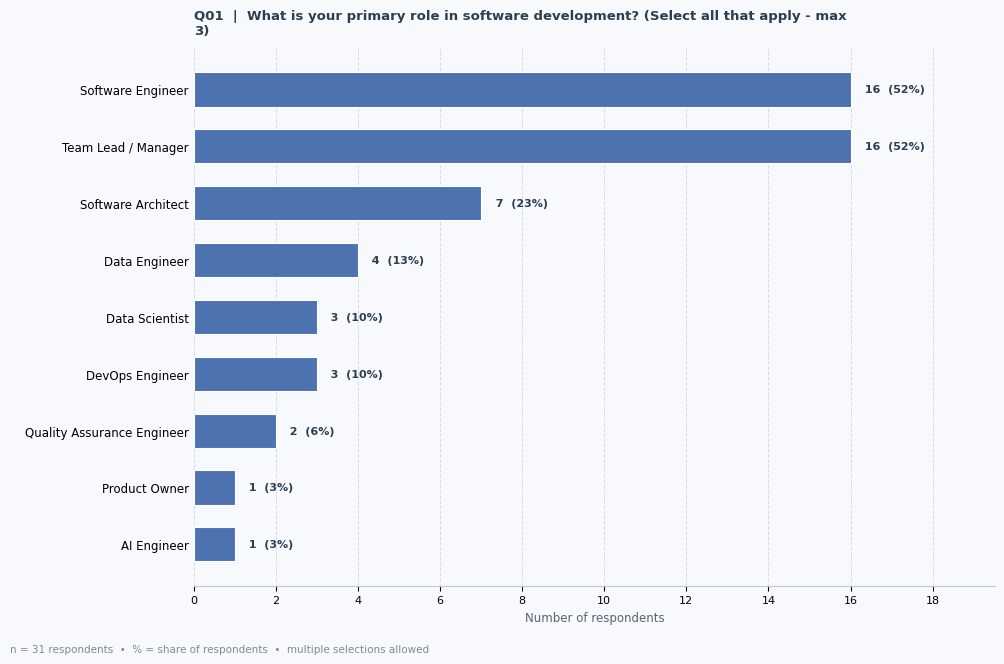


══════════════════════════════════════════════════════════════════════════
  Q02  [single]
  How many years of experience do you have in software development?
  (Select one)
══════════════════════════════════════════════════════════════════════════
  Respondents: 31
──────────────────────────────────────────────────────────────────────────
  Category                                          n       %    95 % CI (Wilson)
──────────────────────────────────────────────────────────────────────────
  > 10 years                                       14   45.2%  [0.292, 0.622]
  4 - 6 years                                       7   22.6%  [0.114, 0.398]
  1 - 3 years                                       5   16.1%  [0.071, 0.326]
  7 - 10 years                                      4   12.9%  [0.051, 0.288]
  < 1 year                                          1    3.2%  [0.006, 0.162]
──────────────────────────────────────────────────────────────────────────
  Dominant    : > 10 years
  Entrop

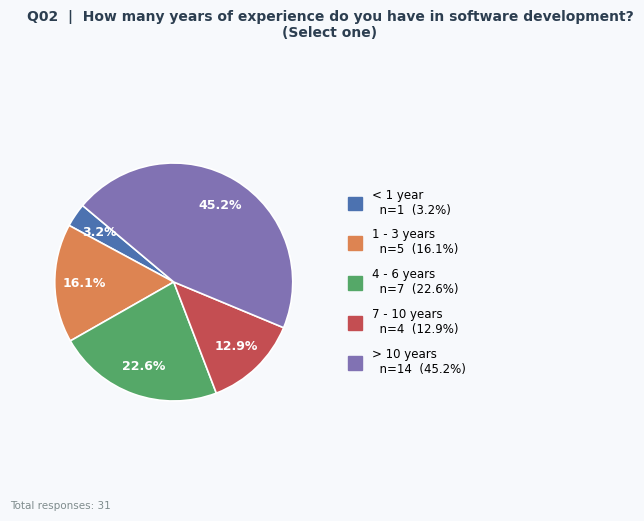


══════════════════════════════════════════════════════════════════════════
  Q03  [single]
  How would you categorize the size of your organization? (Select one)
══════════════════════════════════════════════════════════════════════════
  Respondents: 31
──────────────────────────────────────────────────────────────────────────
  Category                                          n       %    95 % CI (Wilson)
──────────────────────────────────────────────────────────────────────────
  Small (11-50 employees)                          13   41.9%  [0.264, 0.592]
  Large Enterprise (100+ employees)                13   41.9%  [0.264, 0.592]
  Medium Business (51-100 employees)                4   12.9%  [0.051, 0.288]
  Startup (1-10 employees)                          1    3.2%  [0.006, 0.162]
──────────────────────────────────────────────────────────────────────────
  Dominant    : Small (11-50 employees)
  Entropy     : 1.593 bits  (normalised: 0.796  — 0=consensus, 1=uniform)
  χ² (unifo

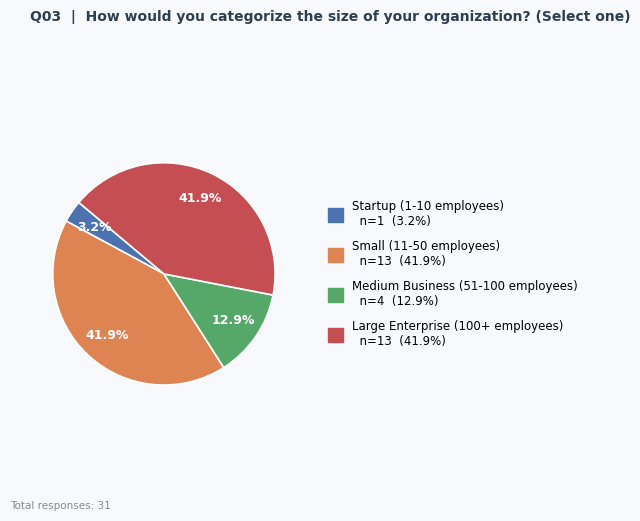


══════════════════════════════════════════════════════════════════════════
  Q04  [multi]
  What programming languages do you use primarily? (Select all that
  apply)
══════════════════════════════════════════════════════════════════════════
  Respondents: 31   |   Total selections: 67
──────────────────────────────────────────────────────────────────────────
  Category                                          n       %    95 % CI (Wilson)
──────────────────────────────────────────────────────────────────────────
  C#                                               18   58.1%  [0.408, 0.736]
  TypeScript                                       14   45.2%  [0.292, 0.622]
  Python                                           11   35.5%  [0.211, 0.530]
  JavaScript                                       11   35.5%  [0.211, 0.530]
  Java                                              4   12.9%  [0.051, 0.288]
  PHP                                               2    6.5%  [0.018, 0.207]
  C / C++   

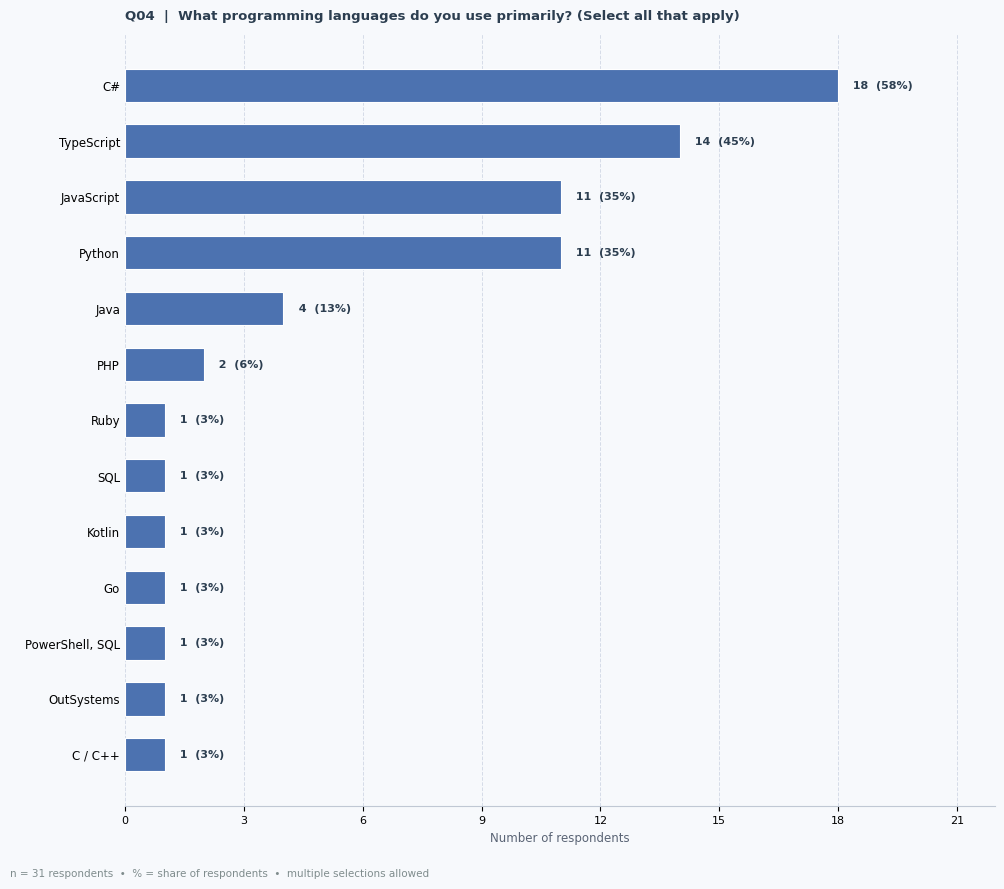


══════════════════════════════════════════════════════════════════════════
  Q05  [single]
  What is the highest level of education you have completed in the Dutch
  education system? (Select one)
══════════════════════════════════════════════════════════════════════════
  Respondents: 31
──────────────────────────────────────────────────────────────────────────
  Category                                          n       %    95 % CI (Wilson)
──────────────────────────────────────────────────────────────────────────
  HBO (Hoger beroepsnderwijs – University of ...   19   61.3%  [0.438, 0.763]
  WO (wetenschappelijk onderwijs – Research U...   12   38.7%  [0.237, 0.562]
──────────────────────────────────────────────────────────────────────────
  Dominant    : HBO (Hoger beroepsnderwijs – University of Applied Sciences)
  Entropy     : 0.963 bits  (normalised: 0.963  — 0=consensus, 1=uniform)
  χ² (uniform): 1.581   p = 0.2087  → ✗ not significant at α = 0.05



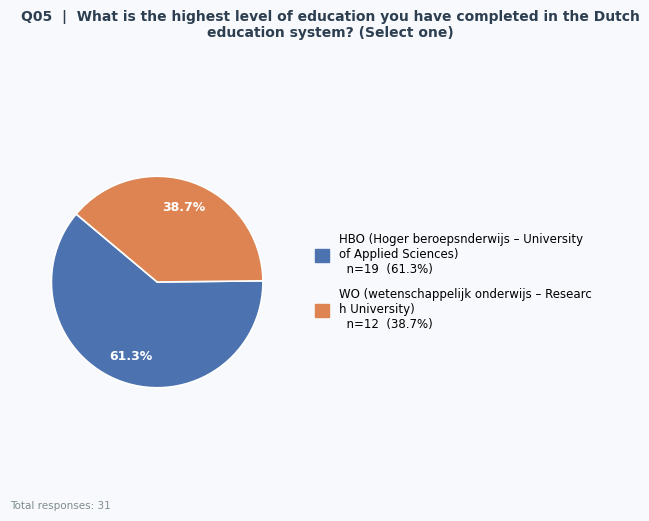


══════════════════════════════════════════════════════════════════════════
  Q06  [single]
  What is your highest academic qualification? (Select one)
══════════════════════════════════════════════════════════════════════════
  Respondents: 31
──────────────────────────────────────────────────────────────────────────
  Category                                          n       %    95 % CI (Wilson)
──────────────────────────────────────────────────────────────────────────
  Bachelor’s degree (BSc, BA, etc.)                21   67.7%  [0.501, 0.814]
  Master’s degree (MSc, MA, etc.)                   5   16.1%  [0.071, 0.326]
  PhD (Doctorate)                                   4   12.9%  [0.051, 0.288]
  Associate degree                                  1    3.2%  [0.006, 0.162]
──────────────────────────────────────────────────────────────────────────
  Dominant    : Bachelor’s degree (BSc, BA, etc.)
  Entropy     : 1.346 bits  (normalised: 0.673  — 0=consensus, 1=uniform)
  χ² (unifor

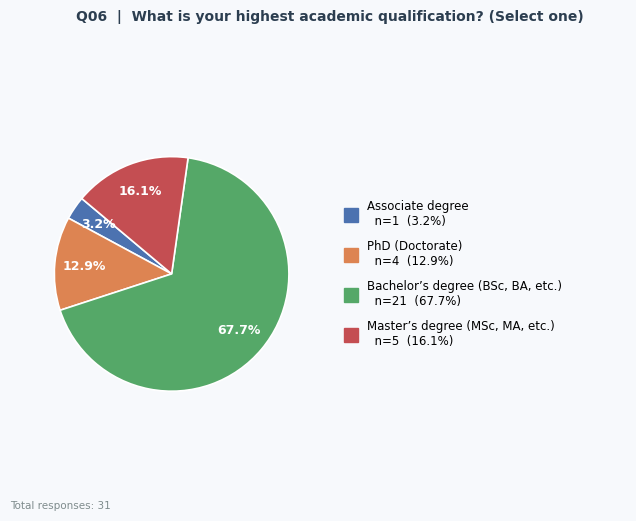

In [ ]:
# Background Anlysis
# ── Single call ───────────────────────────────────────────────────────────────
for q in range(1,7):
    show_question(SHEETS, q)
# show_question(SHEETS, 'Q08')           # single-choice  → stats + pie chart
# show_question(SHEETS, 'Q11')           # multi-choice   → stats + bar chart
# show_question(SHEETS, 'Q10')           # scaling        → stats + stacked bar
# show_question(SHEETS, 'Q21')           # open-ended     → verbatim list

# # ── Integer shorthand ─────────────────────────────────────────────────────────
# show_question(SHEETS, 8)

# # ── Options ───────────────────────────────────────────────────────────────────
# show_question(SHEETS, 'Q16', top_n=5)                         # top-5 choices only
# show_question(SHEETS, 'Q02', print_stats=False)               # chart only
# show_question(SHEETS, 'Q10', figsize=(14, 7))                 # wider chart
# show_question(SHEETS, 'Q08', save_path='figures/Q08.png')     # save to file

# # ── Capture results for downstream analysis ───────────────────────────────────
# r = show_question(SHEETS, 'Q08', return_results=True, print_stats=False)
# print(r['dominant_category'], r['entropy_norm'])

# r14 = show_question(SHEETS, 'Q14', return_results=True, print_stats=False)
# for item, d in sorted(r14['items'].items(), key=lambda x: -x[1]['positive_pct'])[:3]:
#     print(f"{item}: {d['positive_pct']}% positive")

# # ── Sweep all non-open questions and save figures ─────────────────────────────
# import os
# os.makedirs('figures', exist_ok=True)
# for qid, meta in QUESTION_REGISTRY.items():
#     show_question(SHEETS, qid,
#                   print_stats=False,
#                   save_path=f'figures/{qid}.png' if meta['type'] != 'open' else None)

## Q01 — Primary Role in Software Development

### Observation

The sample of 31 respondents generated 53 total selections (mean 1.71 roles per respondent), indicating that a substantial proportion of participants occupy more than one professional role simultaneously. Two roles dominate the distribution with exactly equal frequency: **Team Lead / Manager** and **Software Engineer**, each selected by 16 respondents (51.6%). Software Architect follows at 22.6% (n=7), while the remaining six roles — Data Engineer, DevOps Engineer, Data Scientist, QA Engineer, AI Engineer, and Product Owner — each represent fewer than 13% of respondents.

### Statistical Support

The normalised Shannon entropy of **0.812** (2.574 bits out of a theoretical maximum of 3.170 bits for nine categories) indicates a moderately high spread across roles, yet the distribution is far from uniform. The chi-squared goodness-of-fit test against a uniform distribution yields χ²(8) = 49.057, p < 0.001, confirming that the concentration in the top two categories is statistically significant and not attributable to chance. The Wilson 95% confidence intervals for the two dominant roles are [0.348, 0.680], reflecting genuine uncertainty due to the small sample size — the true population proportion for either role could plausibly range from just over one-third to roughly two-thirds of Dutch ICT practitioners.

### Interpretation

The near-perfect tie between Team Lead / Manager and Software Engineer is a substantive finding in the context of this research. It suggests that the survey reached professionals who are simultaneously practitioners *and* decision-makers — people who both write or review code themselves and bear organisational responsibility for development teams. This dual profile is especially relevant for a study on GenAI adoption: these respondents are well-positioned to assess GenAI tools not only from a technical productivity standpoint but also from a skills-management and hiring perspective. Their responses on future skill requirements (Q16), AI impact on junior developers (Q20), and hiring change (Q22) carry particular weight because they reflect the viewpoint of those who will directly shape team composition and training investments.

The 22.6% representation of Software Architects is also notable. Architects operate at the intersection of technical decision-making and long-term system design — precisely the domain where concerns about AI-generated code quality, technical debt, and security (Q17) are most acute. Their presence in the sample enriches the reliability of findings on those themes.

The very low representation of AI Engineers (3.2%, n=1) is meaningful in the opposite direction: the sample is not skewed toward AI specialists who might hold systematically more optimistic views on GenAI capabilities. The findings therefore better reflect the perspective of mainstream software development professionals encountering GenAI as an externally-imposed tool rather than as a domain of personal expertise.

### Limitation

Four caveats apply to this question specifically. First, with n=31 the Wilson CIs are wide — even the dominant categories span a 33-percentage-point range — so point estimates should be treated as indicative rather than precise. Second, the survey permits up to three role selections per respondent, which means the 51.6% figures do not represent 51.6% of distinct individuals holding only that role; role overlap is unquantified and could inflate apparent representation. Third, the sample is regionally constrained to the Rotterdam area of the Netherlands, and the role distribution may not generalise to other national or international ICT markets. Fourth, the absence of a "Student" or "Junior Developer" category means the sample skews toward experienced professionals, which is relevant when interpreting questions about the learning curve for junior developers.

## Q02 — Years of Experience in Software Development

### Observation

All 31 respondents answered this question. The distribution is right-skewed toward seniority: the single largest group is **"> 10 years"** at 45.2% (n=14), making experienced developers the clear plurality. Combining the two most senior bands ("> 10 years" and "7–10 years") yields 58.1% of the sample — meaning nearly three in five respondents have at least seven years of professional experience. At the other end, only one respondent (3.2%) reported less than one year of experience, and early-career professionals (1–3 years) represent just 16.1% (n=5).

### Statistical Support

The normalised Shannon entropy of **0.848** (1.968 bits out of a maximum of 2.322 bits for five categories) signals a fairly broad spread across experience bands — the distribution is neither tightly clustered nor uniform. The chi-squared test against a uniform distribution yields χ²(4) = 15.290, p = 0.004, confirming that the observed skew toward senior respondents is statistically significant. The Wilson CI for the dominant category [0.292, 0.622] is wide, as expected for n=31, but its lower bound still exceeds 29%, making it unlikely that the true population proportion of highly experienced respondents falls below roughly one-third.

### Interpretation

The seniority profile of the sample has direct and important consequences for interpreting every substantive finding in this survey. Respondents with more than seven years of experience have lived through multiple technological transitions in software development — from waterfall to agile, from on-premise to cloud, from manual testing to CI/CD — and are therefore evaluating GenAI adoption through a lens of comparative experience rather than novelty alone. This likely produces more measured, critical assessments of GenAI capabilities and risks than a sample dominated by early-career developers might yield.

This is particularly relevant for questions about trust in AI-generated code (Q18), perceived risks of over-reliance (Q21), and the impact on junior developer learning curves (Q20). When senior practitioners express concern about de-skilling or code quality degradation, those concerns carry empirical weight: they are not reacting from fear of the unfamiliar but from a baseline understanding of what high-quality software development looks like without AI assistance.

The relative underrepresentation of early-career professionals (< 3 years: 19.4% combined) is a structural limitation but also a meaningful finding in itself. It suggests that either junior developers are less present in the Rotterdam ICT companies surveyed, or they were less inclined to participate — possibly because GenAI adoption decisions are perceived as a senior-level concern. Either way, the survey captures the perspective of those most likely to be *setting* GenAI policy within their organisations rather than simply following it.

The crossover between Q01 and Q02 is also worth noting: the dominance of Team Lead / Manager and Software Architect roles in Q01 aligns naturally with the seniority distribution here. These are not entry-level designations, and the experience data confirms the sample is internally consistent.

### Limitation

The ordinal nature of this scale means that within-band heterogeneity is hidden: a respondent with 11 years of experience and one with 25 years both fall into "> 10 years", despite potentially very different relationships with GenAI tools. The single respondent with less than one year of experience is too isolated to draw any inference about junior perspectives, and their presence or absence has a disproportionate effect on the χ² result. As with Q01, the small total sample (n=31) produces wide confidence intervals, and the regional concentration in the Rotterdam area limits generalisability to the broader Dutch or European ICT workforce.

## Q03 — Organisation Size

### Observation

All 31 respondents answered this question. The distribution is strikingly bimodal: **Small (11–50 employees)** and **Large Enterprise (100+ employees)** each account for exactly 41.9% of the sample (n=13 each), together representing 83.9% of all respondents. The middle tier — Medium Business (51–100 employees) — is markedly underrepresented at 12.9% (n=4), and only a single respondent (3.2%) works at a startup of fewer than 10 people. The two dominant categories share the same Wilson CI [0.264, 0.592] by symmetry, reflecting genuine uncertainty about which truly dominates in the broader population, but the bimodal pattern itself is robust.

### Statistical Support

The normalised Shannon entropy of **0.796** (1.593 bits out of a maximum of 2.0 bits for four categories) indicates a moderately spread distribution — higher than a pure two-category split would produce, but well below uniform. The chi-squared test against a uniform distribution yields χ²(3) = 14.806, p = 0.002, confirming that the hollowing-out of the middle and near-absence of startups is statistically significant and not a sampling artefact. The near-tie between the two dominant categories means the χ² signal is driven almost entirely by the underrepresentation of Medium Business and Startup, not by any dominance of one large category.

### Interpretation

The bimodal organisation size profile is a substantive finding that adds important texture to the survey's conclusions. Small and large organisations typically occupy very different positions in the GenAI adoption landscape, and having roughly equal representation of both means the survey captures a genuine tension between two distinct organisational realities.

**Large enterprises (100+ employees)** tend to have formalised AI governance structures, dedicated security and compliance teams, and institutional processes for evaluating and deploying new tools. Their respondents are more likely to encounter GenAI through top-down adoption mandates, approved tooling lists, and structured training programmes. Concerns about intellectual property, regulatory compliance, and data privacy (Q17) are likely to be especially salient for this group.

**Small organisations (11–50 employees)** operate with far less process overhead. GenAI adoption in this context tends to be bottom-up, driven by individual developers seeking productivity gains, with less formal oversight of code quality or security implications. This makes the findings on trust in AI-generated code (Q18) and issues with AI-generated code (Q11) particularly relevant for this segment — small teams may lack the senior review capacity to catch the kinds of errors that large enterprise code review processes would surface.

The near-absence of the medium-business tier (12.9%) and startups (3.2%) limits what can be said about those organisational contexts, but it reflects a real structural feature of the Rotterdam ICT ecosystem: the regional economy is characterised by a mix of established large firms (logistics, port operations, financial services) and a constellation of smaller specialised software houses and agencies, with relatively fewer mid-sized technology companies.

The coexistence of small and large organisations in roughly equal proportions also means that aggregate findings — particularly on GenAI frequency of use (Q08), organisational stance on AI tools (Q07), and anticipated skill changes (Q14) — should be interpreted with caution, since the two groups may hold systematically different views that cancel out in aggregate analysis. A cross-tabulation of Q03 against key outcome variables would be a natural and valuable next step.

### Limitation

The size bands used in this survey are relatively coarse and do not capture headcount within the software development function specifically. A 200-person logistics company with a three-person development team occupies a very different GenAI adoption context than a 150-person software consultancy, yet both fall into "Large Enterprise". The near-perfect tie between the two dominant categories means the "dominant" label assigned to Small (11–50) is statistically meaningless — it is dominant only by the arbitrary convention of alphabetical tie-breaking in the output. As with all questions in this survey, the n=31 sample size limits the precision of all estimates, and the regional scope constrains generalisability.

## Q04 — Primary Programming Languages

### Observation

The 31 respondents generated 67 total selections, a mean of 2.16 languages per respondent, confirming that most practitioners work across multiple languages simultaneously. The distribution has a clear top tier: **C#** leads decisively at 58.1% (n=18), followed by **TypeScript** at 45.2% (n=14), and then **Python** and **JavaScript** in a tie at 35.5% (n=11 each). These four languages together account for 54 of the 67 selections (80.6%), while the remaining nine languages each appear only once or twice, representing a long tail of niche or secondary tooling. Notable among the tail entries is OutSystems — a low-code platform rather than a traditional programming language — whose presence foreshadows the kinds of abstraction-layer debates that appear in the open-ended responses (Q23).

### Statistical Support

The normalised Shannon entropy of **0.774** (2.865 bits out of a maximum of 3.700 bits for thirteen categories) reflects a moderately concentrated distribution despite the large number of categories. The chi-squared test against a uniform distribution yields χ²(12) = 86.090, p < 0.001, confirming that the dominance of the top four languages is highly significant and not a product of random sampling. The Wilson CI for C# [0.408, 0.736] is the tightest of the top-tier languages, reflecting its clearest signal in the data; even the lower bound exceeds 40%, making C# dominance robust to sampling uncertainty.

### Interpretation

The language profile of this sample is distinctively shaped by the Rotterdam regional ICT ecosystem and carries direct implications for how GenAI tools are experienced in practice.

**C#'s dominance** (58.1%) is the most consequential finding. C# is the primary language of the Microsoft .NET ecosystem, which has a historically strong footprint in Dutch enterprise and government IT. This matters for GenAI adoption because GitHub Copilot — Microsoft's AI coding assistant, built on OpenAI models and deeply integrated into Visual Studio and VS Code — is the most natural GenAI tool for C# developers. The high C# representation therefore suggests that a significant portion of this sample's GenAI experience is mediated through Copilot specifically, rather than through general-purpose tools like ChatGPT used in isolation. This has implications for interpreting Q08 (frequency of use), Q09 (tasks), Q10 (usefulness ratings), and Q11 (issues encountered): Copilot's particular strengths and failure modes — strong code completion, weaker architectural reasoning, known hallucination patterns in less-represented libraries — may colour the responses more than the survey can explicitly capture.

**TypeScript at 45.2%** reflects the pervasive shift in professional web and full-stack development away from untyped JavaScript toward statically typed codebases. TypeScript's strong type system makes it one of the languages where AI-generated code errors are most immediately visible, since type mismatches surface at compile time rather than at runtime. This may partially explain the high reported rate of specification-following failures in Q11 — type-safe environments expose AI shortcomings that looser languages would silently accept.

**Python at 35.5%** connects this sample to the data engineering and data science roles identified in Q01 (12.9% and 9.7% respectively). Python is the dominant language for AI/ML workloads, and its presence suggests a non-trivial proportion of respondents are working in contexts where they are not merely using GenAI tools as coding assistants but are potentially building or maintaining AI-adjacent systems themselves. This creates an interesting reflexivity: some respondents may be developing the data pipelines or model infrastructure that underpins the very GenAI tools they are being asked to evaluate.

**JavaScript alongside TypeScript** (both at 35.5%) indicates significant front-end and Node.js development in the sample, consistent with a modern full-stack or web-services orientation. The combination of C#, TypeScript, and JavaScript suggests many respondents work in multi-language environments — a .NET backend with a TypeScript/JavaScript front-end is one of the most common enterprise web application stacks in the Netherlands.

The **long tail of single-mention languages** (Go, Kotlin, Ruby, PHP, C/C++, SQL) is informative precisely because of its thinness. The near-absence of Java (12.9%, n=4) is notable given Java's historically large enterprise footprint; this may reflect the Rotterdam-area sample's Microsoft ecosystem orientation, or a genuine generational shift away from Java in newer projects. The presence of PowerShell/SQL as a combined entry and SQL as a standalone entry by different respondents suggests inconsistent interpretation of "programming language" — some respondents included query and scripting languages while others did not, introducing minor measurement noise.

### Limitation

The multi-select format with no defined maximum creates asymmetry: a respondent listing C#, TypeScript, Python, and JavaScript contributes four selections, while one listing only C# contributes one, yet both count equally as "respondents" in the denominator. This means the 58.1% for C# reflects the proportion of respondents who use it, not the proportion of their working time spent in it — intensity of use is entirely unobserved. The tail languages each appear once, making their Wilson CIs [0.006, 0.162] nearly identical and essentially uninformative beyond confirming they are rare in this sample. Finally, the OutSystems entry signals that the boundary between "programming language" and "development platform" was interpreted loosely by at least one respondent, which may mean other low-code or no-code tools are underreported.

## Q05 — Highest Education Level (Dutch System)

### Observation

All 31 respondents answered this question. The distribution splits the sample into two groups defined by the Dutch higher education binary: **HBO** (Hoger Beroepsonderwijs — University of Applied Sciences) at 61.3% (n=19) and **WO** (Wetenschappelijk Onderwijs — Research University) at 38.7% (n=12). HBO is the plurality, but the margin is modest — roughly three-to-two in favour of applied-sciences graduates over research-university graduates.

### Statistical Support

This is the only question in the survey so far where the chi-squared test against a uniform distribution is **not significant**: χ²(1) = 1.581, p = 0.209. With only two categories, a uniform distribution is simply a 50/50 split, and the observed 61/39 division is insufficiently far from that benchmark to reject the null hypothesis at α = 0.05. The normalised Shannon entropy of **0.963** — the highest recorded across all questions analysed so far — confirms this: with only two categories, the theoretical maximum entropy is 1.0 bit, and 0.963 bits represents a near-maximally uncertain distribution. In practical terms, knowing a randomly selected respondent's education level gives almost no predictive power about which category they fall into. The Wilson CIs overlap substantially: [0.438, 0.763] for HBO and [0.237, 0.562] for WO, with the intervals sharing the range [0.438, 0.562]. This overlap means the true population proportions could plausibly be much closer to parity than the point estimates suggest.

### Interpretation

The near-even split between HBO and WO graduates carries meaningful implications for this research, particularly because the Dutch higher education system encodes a fundamental distinction in educational philosophy that maps directly onto how developers are likely to engage with GenAI tools.

**HBO programmes** are vocationally oriented: they emphasise applied skills, project-based learning, and direct workplace readiness. HBO graduates in software development typically enter the workforce with strong practical competencies in specific languages, frameworks, and development methodologies, but with less exposure to theoretical computer science, formal methods, or research-oriented problem decomposition. In the context of GenAI adoption, HBO-trained developers may be more inclined toward pragmatic tool acceptance — using GenAI to accelerate tasks they already know how to do — and may be more immediately productive with code-completion tools like Copilot.

**WO programmes** are research-oriented: they emphasise theoretical foundations, algorithmic thinking, and scientific reasoning. WO graduates are more likely to have formal training in complexity theory, software engineering principles, and systematic evaluation of tools and systems. This background may predispose them toward more critical assessment of GenAI outputs — more likely to scrutinise generated code for correctness, security vulnerabilities, or architectural soundness before accepting it. The concerns about AI-generated code quality and de-skilling risks that will likely appear in Q17, Q20, and Q21 may be disproportionately voiced by WO-educated respondents.

The near-parity of the two groups means the aggregate survey responses represent a genuine blend of these two educational orientations. This is actually an asset for the research: findings are less likely to be systematically biased toward either a purely theoretical or purely practical viewpoint on GenAI in software development.

In the broader Dutch labour market context, the 61/39 HBO-to-WO ratio is broadly consistent with national patterns — HBO graduates outnumber WO graduates in the Dutch ICT workforce, and the applied-sciences pathway has historically been the primary feeder into commercial software development roles. The slight HBO majority in this sample therefore reflects realistic workforce composition rather than a sampling anomaly.

### Limitation

The binary nature of this question — an artefact of the Dutch system's two-track structure — makes it impossible to capture important within-category variation. HBO graduates range from two-year associate programmes to four-year bachelor degrees with honours tracks; WO graduates range from three-year bachelor degrees to five-year master's programmes and beyond. The question captures the type of education but not the level within that type, which Q06 addresses with finer granularity. The non-significant chi-squared result should not be over-interpreted as evidence that the two groups are equivalent in their views on GenAI — it simply means the sample does not allow us to determine which educational track is more prevalent in the population. With n=31, the statistical power to detect a 61/39 split as significantly different from 50/50 is low, and a larger sample would likely resolve the ambiguity.

## Q06 — Highest Academic Qualification

### Observation

All 31 respondents answered this question. The distribution is strongly right-skewed toward bachelor-level education: **Bachelor's degree** dominates at 67.7% (n=21), making it by far the modal qualification. Master's degree holders represent 16.1% (n=5), PhD holders 12.9% (n=4), and a single respondent (3.2%) holds an Associate degree. Taken together, postgraduate qualifications (Master's + PhD) account for 29.0% of the sample — nearly three in ten respondents hold a degree beyond bachelor level.

### Statistical Support

The normalised Shannon entropy of **0.673** (1.346 bits out of a maximum of 2.0 bits for four categories) is notably lower than Q03 and Q04, reflecting a more concentrated, less evenly spread distribution. The chi-squared test against a uniform distribution yields χ²(3) = 31.323, p < 0.001, confirming that bachelor-degree dominance is highly significant. The Wilson CI for the bachelor category [0.501, 0.814] is the tightest of all dominant categories encountered so far — even its lower bound exceeds 50%, establishing with confidence that bachelor-level education is genuinely the plurality qualification in this population, not merely an artefact of sampling. The PhD category's CI [0.051, 0.288] is notably wide for its size (n=4), spanning from near-negligible to over a quarter of the population, making inferences about doctoral representation unreliable.

### Interpretation

Read alongside Q05, Q06 substantially sharpens the educational profile of the sample. The 61.3% HBO majority in Q05 translates logically into the 67.7% bachelor dominance in Q06: HBO programmes in the Netherlands culminate in a Bachelor of Applied Sciences (BAS), so the majority of bachelor-degree holders here are applied-sciences graduates rather than research-university graduates. This consistency between Q05 and Q06 provides a useful internal validity check — the two questions are measuring related constructs and produce coherent results.

The **bachelor-dominant profile** has direct relevance for the research question. Bachelor-level software developers in applied-sciences programmes receive training that is deliberately oriented toward current industry practice and tooling. This means they are, on average, closer to the coalface of GenAI adoption: they entered the workforce recently enough to encounter these tools as a standard part of the development environment, and their training institutions are actively adapting curricula to include AI-assisted development. Their assessments of GenAI usefulness (Q10) and their views on essential future skills (Q16) are therefore grounded in relatively recent, practice-oriented formation.

The **unexpected prevalence of PhD holders** (12.9%, n=4) is worth pausing on. In most commercial software development samples, doctoral qualification rates are well below 10%. Their presence here — four out of 31 respondents — likely reflects the Rotterdam-area sample's inclusion of individuals working at the boundary between academic research and industrial application, or at large enterprises with dedicated R&D functions. PhD holders typically bring deeper theoretical foundations and stronger habits of systematic evaluation, which may make them disproportionately influential in shaping team-level responses to GenAI adoption. Their views on AI limitations, code quality, and de-skilling risks may be more technically grounded and more sceptical than those of the bachelor-majority.

The near-absence of associate degree holders (3.2%, n=1) is consistent with the Dutch educational landscape: the associate degree (*Associate degree* or *AD*) is a relatively recent two-year qualification introduced in the Dutch system and has not yet achieved wide uptake in the ICT sector. Its near-invisibility here does not indicate a sampling bias so much as an accurate reflection of current qualification distribution in the Dutch software development workforce.

Combining Q05 and Q06 also reveals an interesting pattern regarding the Master's degree group (16.1%, n=5). Given that 38.7% of respondents hold WO qualifications (Q05), but only 16.1% hold a Master's degree (Q06), it appears that a substantial proportion of WO-educated respondents completed their bachelor's degree at a research university without proceeding to master's level. This is consistent with the Dutch WO system, where the bachelor's degree is a standalone qualification — unlike in many other European countries where WO bachelor graduates almost automatically continue to master's level.

### Limitation

The qualification categories used conflate HBO and WO bachelor degrees under a single "Bachelor's degree" label, which partially undermines the nuance recovered by Q05. A respondent with an HBO bachelor and one with a WO bachelor are classified identically in Q06 despite the substantive pedagogical differences discussed under Q05. With only four PhD holders in the sample, any conclusions about the doctoral subgroup must be treated as highly tentative — the Wilson CI spanning [0.051, 0.288] could accommodate anything from marginal to substantial doctoral representation in the true population. Finally, the question captures the highest qualification obtained but not the field of study, leaving open the question of whether computer science, information technology, mathematics, or other disciplines dominate the sample's academic backgrounds.


══════════════════════════════════════════════════════════════════════════
  Q07  [single]
  How would you describe your organization's stance on the use of AI-
  assisted coding tools (e.g., ChatGPT, Copilot, Bard, Code Llama,
  CodeWhisperer, etc.)? Select the option that best reflects your ...
══════════════════════════════════════════════════════════════════════════
  Respondents: 31
──────────────────────────────────────────────────────────────────────────
  Category                                          n       %    95 % CI (Wilson)
──────────────────────────────────────────────────────────────────────────
  allows the use of AI tools, but does not ac...   16   51.6%  [0.348, 0.680]
  actively encourages the use of AI coding to...   15   48.4%  [0.320, 0.652]
──────────────────────────────────────────────────────────────────────────
  Dominant    : allows the use of AI tools, but does not actively promote them.
  Entropy     : 0.999 bits  (normalised: 0.999  — 0=consensus, 1=

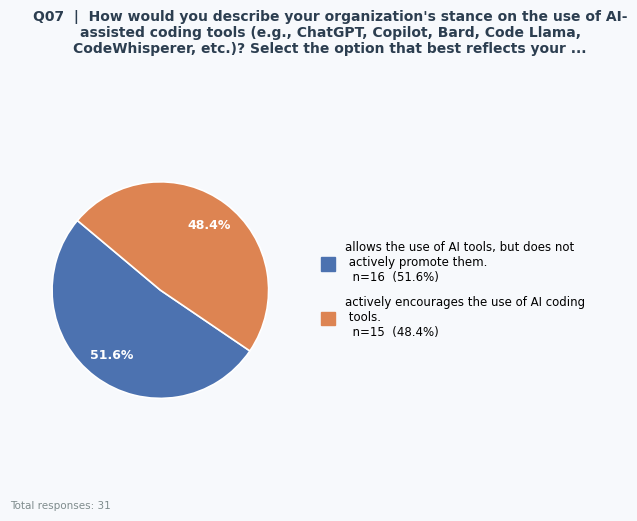


══════════════════════════════════════════════════════════════════════════
  Q08  [single]
  How frequently do you use generative AI tools (e.g., ChatGPT, Copilot,
  Bard, Code Llama) in your workflow? (Select one)
══════════════════════════════════════════════════════════════════════════
  Respondents: 31
──────────────────────────────────────────────────────────────────────────
  Category                                          n       %    95 % CI (Wilson)
──────────────────────────────────────────────────────────────────────────
  Regularly (daily or almost daily)                26   83.9%  [0.674, 0.929]
  Rarely (a few times a month)                      3    9.7%  [0.034, 0.249]
  Occasionally (a few times a week)                 2    6.5%  [0.018, 0.207]
──────────────────────────────────────────────────────────────────────────
  Dominant    : Regularly (daily or almost daily)
  Entropy     : 0.794 bits  (normalised: 0.501  — 0=consensus, 1=uniform)
  χ² (uniform): 35.677   p

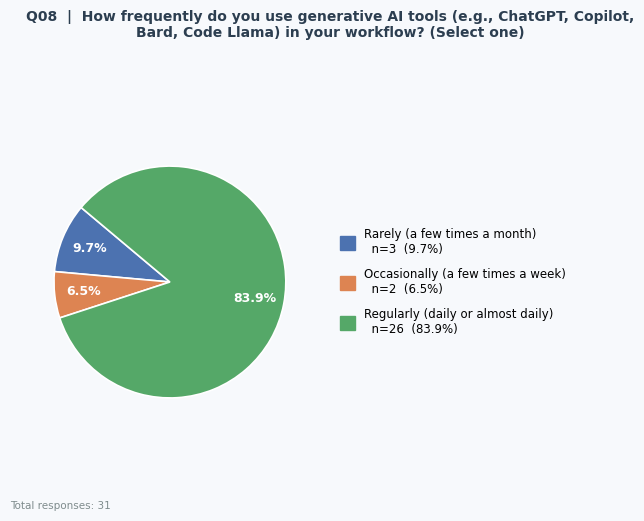


══════════════════════════════════════════════════════════════════════════
  Q09  [multi]
  For which tasks do you use generative AI? (Select all that apply)
══════════════════════════════════════════════════════════════════════════
  Respondents: 31   |   Total selections: 151
──────────────────────────────────────────────────────────────────────────
  Category                                          n       %    95 % CI (Wilson)
──────────────────────────────────────────────────────────────────────────
  Brainstorming                                    25   80.7%  [0.637, 0.908]
  Code generation / auto-completion                23   74.2%  [0.568, 0.863]
  Debugging / Error Explanation                    22   71.0%  [0.534, 0.839]
  Test / Test case generation                      15   48.4%  [0.320, 0.652]
  Code Documentation                               14   45.2%  [0.292, 0.622]
  Self-development and Learning                    14   45.2%  [0.292, 0.622]
  Refactoring existi

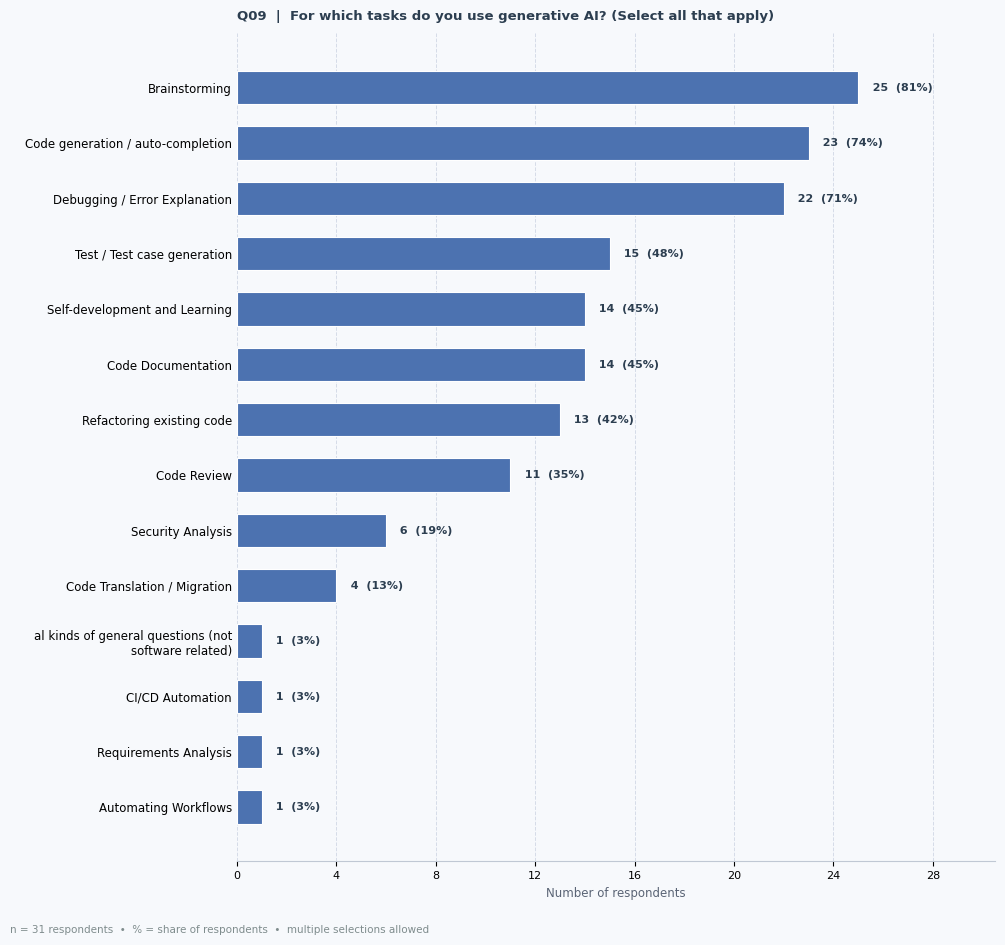


════════════════════════════════════════════════════════════════════════════════════════
  Q10  [scaling]
  How useful do you find generative AI is for the following tasks. (Please rate each
  from: Not Useful - Somewhat Useful - Very Useful - Essential - Not Applicable)
  Scale: Not Useful → Somewhat Useful → Very Useful → Essential
════════════════════════════════════════════════════════════════════════════════════════
  n = 31 respondents

  ┌─ Brainstorming
  │  Not Useful:  1 (3%)  Somewhat Use:  9 (29%)  Very Useful: 16 (52%)  Essential:  5 (16%)
  │  mean=2.806 CI(np.float64(2.548), np.float64(3.065))  median=3.0  std=0.749
  │  dominant='Very Useful'  positive=67.7%  entropy=1.595 bits  N/A=0

  ┌─ Self-development and Learning
  │  Not Useful:  1 (4%)  Somewhat Use: 10 (36%)  Very Useful: 16 (57%)  Essential:  1 (4%)
  │  mean=2.607 CI(np.float64(2.393), np.float64(2.821))  median=3.0  std=0.629
  │  dominant='Very Useful'  positive=60.7%  entropy=1.335 bits  N/A=2

  ┌─ Code

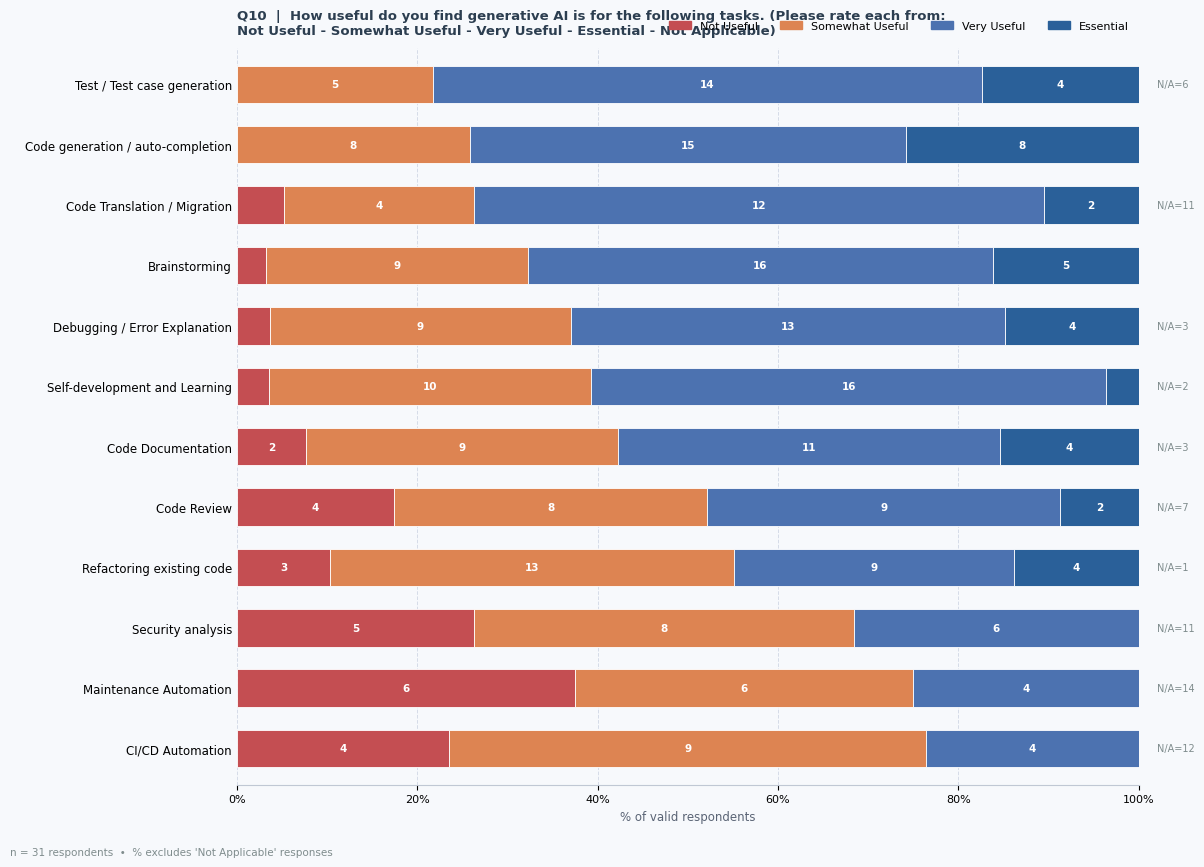

In [20]:
# Analysis: Usage of Generative AI in Software Development Questions 7, 8, 9, 10

for q in range(7,11):
    show_question(SHEETS,q)

## Q07 — Organisation's Stance on AI-Assisted Coding Tools

### Observation

All 31 respondents answered this question. The distribution is virtually identical across the two available categories: **"allows the use of AI tools, but does not actively promote them"** at 51.6% (n=16) and **"actively encourages the use of AI coding tools"** at 48.4% (n=15). The margin is a single respondent. Critically, neither a prohibitive stance nor a neutral-to-discouraging stance appears anywhere in the data — every single respondent works in an organisation that is at minimum permissive toward GenAI tool use.

### Statistical Support

This question produces the most statistically unremarkable distribution in the survey so far. The normalised Shannon entropy of **0.999** — effectively at the theoretical maximum of 1.0 for a two-category question — confirms a near-perfect 50/50 split. The chi-squared test against a uniform distribution yields χ²(1) = 0.032, p = 0.858, an emphatically non-significant result. The Wilson CIs overlap almost completely: [0.348, 0.680] versus [0.320, 0.652]. The "dominant" label assigned to the passive-permission category is statistically meaningless — it reflects a one-respondent numerical accident, not a genuine population tendency. Any inference about which stance is more prevalent in the Rotterdam ICT ecosystem would be unsupported by this data.

### Interpretation

Despite its statistical flatness, Q07 contains one of the most substantively significant findings in the entire survey: **the complete absence of organisations that prohibit or discourage GenAI tool use**. In a survey conducted between July and November 2025, this is a strong signal that, at least within the Rotterdam-area ICT companies represented here, the question of whether to permit GenAI tools has effectively been settled. The debate has moved on — not to adoption versus non-adoption, but to the degree of institutional enthusiasm and structure around adoption.

This finding has profound implications for interpreting all subsequent questions. Respondents are not describing a hypothetical or emerging technology landscape; they are reporting on lived, daily experience with GenAI tools that their employers have formally or implicitly sanctioned. When they report issues with AI-generated code (Q11), assess its usefulness for specific tasks (Q10), or express concerns about developer de-skilling (Q17, Q20), they do so from a position of actual, ongoing, employer-endorsed use. The survey is therefore measuring the *experienced reality* of GenAI adoption in professional settings, not attitudes toward a theoretical possibility.

The near-perfect split between passive permission and active encouragement is itself meaningful. Organisations in the "allows but does not actively promote" category have effectively adopted a laissez-faire stance: individual developers are free to use GenAI tools as they see fit, but the organisation has not invested in structured onboarding, best-practice guidelines, approved tooling lists, or systematic evaluation of outcomes. This is a common early-adoption posture — organisations recognise they cannot practically prohibit tools that developers are already using on personal devices and in personal workflows, but have not yet developed the institutional infrastructure to manage adoption proactively.

Organisations in the "actively encourages" category represent a more mature adoption posture — one where GenAI tool use has been explicitly endorsed, possibly with dedicated budget, tooling standardisation, or training investment. The roughly equal split between these two stances suggests the Rotterdam ICT sector is in a transitional phase: roughly half of organisations have moved from passive acceptance to active promotion, while the other half remain in a holding pattern of permission without investment.

This transition has direct implications for the skill development concerns at the heart of this research. Active encouragement without structured guidance — which characterises at least some of the "encourages" group — risks accelerating the de-skilling and over-reliance dynamics that respondents identify as major concerns elsewhere in the survey. Passive permission without evaluation — the posture of the "allows" group — may produce inconsistent and unmonitored GenAI use that accumulates technical debt silently. Neither stance, as described, includes the systematic skill-development frameworks that the research question suggests will be necessary.

### Limitation

The binary response scale is the most significant limitation of this question. The absence of prohibitive or discouraging stances in the data could reflect genuine reality — perhaps no surveyed organisation prohibits GenAI tools — or it could reflect a selection effect: developers working in restrictive environments may have been less likely to engage with a survey about GenAI use, since the topic would be less salient to their daily work. The question also captures organisational stance as perceived by the individual respondent, which may not accurately reflect formal policy: a respondent may perceive their organisation as "actively encouraging" based on informal team culture, while formal HR or IT policy remains neutral. The absence of a "prohibits" or "evaluating/undecided" option further constrains the interpretive range, making it impossible to assess whether any respondents self-censored by selecting the nearest available option rather than their true situation. Finally, as with Q05, the near-perfect two-way split means the chi-squared result will always be non-significant regardless of sample size, unless a true population preference exists — it is an inherent property of near-parity distributions rather than a sample-size artefact.

## Q08 — Frequency of Generative AI Tool Usage

### Observation

All 31 respondents answered this question. The distribution is sharply concentrated: **"Regularly (daily or almost daily)"** dominates at 83.9% (n=26), with only three respondents (9.7%) reporting rare use and two (6.5%) reporting occasional use. In practical terms, five in six respondents in this sample use GenAI tools as a routine, embedded part of their daily working practice rather than as an occasional resource to be consulted selectively.

### Statistical Support

The normalised Shannon entropy of **0.501** (0.794 bits out of a theoretical maximum of 1.585 bits for three categories) is the lowest recorded across all questions analysed so far, reflecting a highly concentrated, consensus-like distribution. This is reinforced by the chi-squared test against uniform: χ²(2) = 35.677, p < 0.001 — one of the strongest statistical signals in the survey. The Wilson CI for the dominant category [0.674, 0.929] is notably tight given the sample size: even its lower bound exceeds 67%, meaning there is less than a 5% chance that the true population proportion of daily GenAI users falls below two-thirds. The CIs for the minority categories are wide and overlapping — [0.034, 0.249] for rare use and [0.018, 0.207] for occasional use — confirming that little can be said with confidence about the relative size of these two groups beyond acknowledging that both are small.

### Interpretation

The 83.9% daily usage rate is the single most consequential demographic finding in this survey, and it fundamentally reframes the context in which all other responses must be read. This is not a sample of professionals experimenting with or evaluating GenAI tools — it is a sample of professionals for whom GenAI has already become infrastructure, as routine a part of the development workflow as an IDE, a version control system, or a code linter.

This finding connects directly and powerfully to Q07. There, every respondent reported working in an organisation that at minimum permits GenAI tool use, with roughly half actively encouraging it. Q08 reveals that permission has translated into pervasive, habitual adoption at the individual level. The gap between organisational stance and individual behaviour that characterises early-stage technology adoption — where tools are available but uptake is uneven — appears to have already closed in this sample. The organisation allows or encourages, and the individual uses, daily.

The intensity of daily use also sharpens the interpretation of the skill-development concerns that motivate this research. The de-skilling risks identified in Q17 and Q20, and the code quality concerns in Q11, are not theoretical future risks for this population — they are active, ongoing dynamics operating in the daily work of 83.9% of respondents. When a senior developer with ten-plus years of experience (the largest group in Q02) uses GenAI daily in an organisation that encourages its use (Q07), the question of whether AI assistance changes skill development trajectories is being answered in real time by the daily choices this person makes about when to reach for the AI tool and when to reason independently.

The small minority of non-daily users (five respondents combined) is worth briefly considering. The three rare users may represent a principled resistance, a role type that generates less code on a daily basis (consistent with the Product Owner and QA roles identified in Q01), or simply a preference for non-AI workflows that persists despite organisational permission. The two occasional users occupy an interesting middle position — they have integrated GenAI into their workflow but not to the point of daily reliance. With only five respondents across these two categories, no statistically grounded inference is possible, but their presence in the sample provides a modest comparative anchor: the survey is not entirely populated by maximally enthusiastic adopters.

In the broader context of the research question — what skills will future software developers need — the 83.9% daily usage figure establishes that the future being researched is already the present for this sample. The skill requirements being anticipated in Q14 and Q16 are not preparation for a coming transition; they are responses to a transition that is already underway and already embedded in daily professional practice.

### Limitation

The frequency categories used in this question conflate frequency with intensity and purpose. "Daily or almost daily" encompasses a developer who spends six hours per day in a Copilot-assisted coding session and one who asks ChatGPT a single question at the end of the day — both are "daily users" but their relationships with GenAI are qualitatively different. The absence of a "never" category is consistent with the self-selection dynamic discussed in Q07: professionals who never use GenAI tools are unlikely to engage with a survey focused on GenAI in software development, meaning the true population prevalence of non-use is likely underestimated relative to the broader Dutch ICT workforce. The ordering of response options in the original survey (which placed "Regularly" first) may also have introduced a mild anchoring effect, though this cannot be assessed post-hoc from the data alone.

## Q09 — Tasks for Which Generative AI Is Used

### Observation

The 31 respondents generated 151 total selections — a mean of **4.87 tasks per respondent** — the highest selection density of any multi-choice question in the survey so far. This alone signals that GenAI adoption in this sample is broad-spectrum rather than narrowly focused: respondents are not using these tools for one or two specialised purposes but deploying them across nearly five distinct task categories on average. The distribution has a clear three-tier structure. A **top tier** of near-universal tasks: Brainstorming (80.7%), Code generation / auto-completion (74.2%), and Debugging / Error Explanation (71.0%) — all selected by more than two-thirds of respondents. A **middle tier** of moderately common tasks: Test case generation (48.4%), Code Documentation (45.2%), Self-development and Learning (45.2%), Refactoring (41.9%), and Code Review (35.5%) — each selected by roughly one-third to one-half of respondents. A **long tail** of specialist or emerging tasks: Security Analysis (19.4%), Code Translation / Migration (12.9%), and four single-mention entries (3.2% each) covering workflow automation, requirements analysis, CI/CD automation, and general non-software queries.

### Statistical Support

The normalised Shannon entropy of **0.870** (3.310 bits out of a maximum of 3.807 bits for fourteen categories) is the highest of any question analysed so far, indicating that GenAI usage is genuinely distributed across a wide range of tasks rather than concentrated in one or two dominant categories. Despite this breadth, the chi-squared test against uniform yields χ²(13) = 90.152, p < 0.001, confirming that the three-tier structure — with its top-tier dominance and sparse tail — is statistically significant and not a product of random variation. The Wilson CIs for the top three tasks are the tightest in the question — [0.637, 0.908] for Brainstorming, [0.568, 0.863] for Code generation, [0.534, 0.839] for Debugging — reflecting robust signals that are unlikely to reverse with a larger sample.

### Interpretation

The task profile revealed by Q09 maps with striking coherence onto the software development lifecycle and onto what is known about GenAI tool capabilities and limitations in 2025.

**Brainstorming as the most common use case** (80.7%) is a finding that cuts against the popular narrative that GenAI adoption in software development is primarily about code generation productivity. The single most widespread use is cognitive and exploratory rather than generative: developers are using these tools to think through problems, explore solution spaces, evaluate architectural options, and articulate requirements before writing a line of code. This is precisely the use case where GenAI's lack of deep contextual knowledge about a specific codebase matters least — brainstorming about design patterns, technology choices, or problem decomposition does not require the tool to understand the particulars of the project, only to draw on broad knowledge of software engineering principles. It also suggests that the most immediate skill implication is not code-writing ability but the capacity to formulate productive, well-scoped prompts for exploratory conversations — a form of prompt engineering that is more Socratic than instructional.

**Code generation and Debugging forming the second and third positions** (74.2% and 71.0%) confirms that the core productivity use cases are well-established and near-universal. These are the capabilities that drove initial GenAI adoption in software development and continue to anchor daily usage, consistent with the 83.9% daily use rate in Q08. The near-equivalence of code generation and debugging frequency is noteworthy: it suggests that AI-generated code itself generates a corresponding need for AI-assisted debugging — a pattern consistent with Q11's finding that logic errors and specification-following failures are the most commonly reported issues. The tools are being used both to write code and to diagnose the problems that code introduces.

**The middle tier reveals the breadth of the integration** that distinguishes this sample from early adopters. Test case generation (48.4%), Documentation (45.2%), and Self-development and Learning (45.2%) represent tasks that extend well beyond the core coding loop. Their roughly equal frequency is meaningful: documentation and testing are traditionally the most neglected phases of software development — the tasks developers defer or skip under time pressure — and their appearance in the top half of this distribution suggests GenAI is specifically enabling engagement with aspects of software quality that were previously under-resourced. Self-development and Learning at 45.2% is particularly relevant to the research question: nearly half of respondents are using GenAI as a learning tool, which complicates the de-skilling narrative. The same tools that risk replacing skill development are being actively used as instruments of it — a paradox that deserves further investigation.

**Refactoring (41.9%) and Code Review (35.5%)** in the middle tier signal that GenAI use has penetrated the maintenance and quality-assurance phases of development, not just the initial construction phase. This is significant because refactoring and code review are precisely the activities where deep understanding of existing code is required — they demand comprehension, not just generation. Their appearance here suggests developers are using GenAI as an analytical tool, not merely as a generative one, though Q10 will reveal how useful respondents actually find these applications.

**Security Analysis at 19.4%** is the most striking gap between actual use and potential value. Given that security vulnerabilities in AI-generated code are the third most commonly reported issue in Q11 (17 respondents, 54.8%), the fact that only 6 respondents use GenAI specifically for security analysis represents a missed opportunity or an unmet need. Developers are experiencing AI-generated security problems more than twice as often as they are using AI to proactively detect or prevent them.

**The long tail** of single-mention entries — workflow automation, requirements analysis, CI/CD automation, and general questions — points toward an emerging frontier of GenAI use cases that have not yet achieved mainstream adoption. Their presence as write-in responses (rather than pre-defined options) also suggests the task taxonomy used in this survey is already slightly behind the actual breadth of practitioner use.

### Limitation

The 4.87 mean selections per respondent creates a complex interdependence among task categories that cannot be resolved from aggregate counts alone: it is unknown whether Brainstorming and Code generation tend to co-occur within the same individuals' usage patterns, or whether respondents cluster into distinct usage profiles (e.g., primarily generative users versus primarily analytical users). The long-tail categories each appear once and contribute negligibly to statistical inference — their Wilson CIs [0.006, 0.162] are effectively floor-level estimates. The pre-defined task list also shapes responses: tasks not listed (such as architecture diagram generation, sprint planning support, or stakeholder communication assistance) are invisible unless written in, meaning the 151 selections likely undercount the true breadth of GenAI application. Finally, frequency of task use is not captured — a respondent who uses GenAI for brainstorming once a month and for code generation daily is recorded identically to one who uses both with equal daily frequency.

## Q10 — Usefulness of Generative AI Per Task

### Observation

Q10 is the first scaling question in the survey, asking respondents to rate GenAI usefulness across 12 distinct development tasks on a four-point ordinal scale (Not Useful → Somewhat Useful → Very Useful → Essential), with a Not Applicable option. The 12 items form three clearly distinguishable tiers when ranked by positive response percentage (share of "Very Useful" + "Essential"):

**High-utility tier** (positive % ≥ 67%): Test / Test case generation (78.3%), Code generation / auto-completion (74.2%), Code Translation / Migration (73.7%), Brainstorming (67.7%)

**Moderate-utility tier** (positive % 44–64%): Debugging / Error Explanation (63.0%), Self-development and Learning (60.7%), Code Documentation (57.7%), Refactoring existing code (44.8%), Code Review (47.8%)

**Low-utility tier** (positive % ≤ 32%): Security analysis (31.6%), CI/CD Automation (23.5%), Maintenance Automation (25.0%)

The N/A counts vary substantially across items — from 0 (Brainstorming, Code generation) to 14 (Maintenance Automation) — indicating that several tasks are simply outside the daily scope of a meaningful fraction of respondents.

### Statistical Support

Ordinal means range from **1.875** (Maintenance Automation) to **3.000** (Code generation / auto-completion), spanning nearly the full width of the 1–4 scale. The 95% bootstrap confidence intervals are tight for items with low N/A counts and few Not Useful responses — Code generation CI [2.742, 3.258] and Test generation CI [2.696, 3.217] — and wider for items with greater N/A exclusions and more dispersed ratings — Maintenance Automation CI [1.500, 2.250] and Code Review CI [2.043, 2.739]. Shannon entropy varies from **1.335 bits** (Self-development and Learning, relatively concentrated) to **1.805 bits** (Code Review, most dispersed), reflecting meaningful differences in how much consensus exists around each item. Items in the low-utility tier show notably higher entropy, indicating greater disagreement rather than a clear shared assessment of limited value.

### Interpretation

**Code generation / auto-completion** is the only item to achieve a mean of exactly 3.0 with zero Not Useful responses and zero N/A responses — every single respondent who answered rated it at least Somewhat Useful, and 74.2% rated it Very Useful or Essential. This makes it the most unambiguously valued GenAI application in the entire survey. Combined with its 74.2% usage rate in Q09, the picture is clear: code generation is the settled, universal core of GenAI value in this sample, a finding consistent with the broader industry literature on developer productivity tools.

**Test case generation** achieves the highest positive percentage (78.3%) despite six N/A responses, suggesting that among those who actually use GenAI for this purpose the utility signal is exceptionally strong — mean 2.957, CI [2.696, 3.217], the tightest interval in the question. This is a striking contrast with the usage rate in Q09, where only 48.4% reported using GenAI for test generation. The gap between usage (48.4%) and rated utility (78.3% positive among users) suggests an **adoption lag**: many developers have not yet integrated GenAI into their testing workflows, but those who have find it highly valuable. This represents one of the clearest actionable findings in the survey — test case generation is an underutilised high-value application.

**Code Translation / Migration** shows a similarly interesting pattern: a 73.7% positive rate and mean of 2.789 among the 20 respondents who rated it, but 11 N/A responses — the joint highest alongside Security analysis. This suggests the task is highly valued when relevant but simply not applicable to a large proportion of roles and projects. The high utility rating among those who do use it makes sense: migration tasks are notoriously tedious, pattern-repetitive, and well-suited to GenAI's strengths in transforming syntactically structured code between languages or frameworks.

**Brainstorming**, the most commonly used task in Q09 (80.7%), rates fourth in utility at 67.7% positive and mean 2.806. This slight utility discount relative to its usage dominance reflects the inherently open-ended and difficult-to-evaluate nature of brainstorming outcomes — it is harder to judge whether an AI-assisted brainstorm was "Very Useful" than whether AI-generated code passed its tests. The non-zero entropy (1.595 bits) and presence of 10 Somewhat Useful responses (29%) indicate genuine variation in how much value respondents extract from GenAI-assisted exploratory thinking, likely reflecting differences in prompting skill and task context.

**Debugging / Error Explanation** (mean 2.741, 63.0% positive) rates slightly below its usage frequency rank (third in Q09). The 3 N/A responses and relatively high entropy (1.620 bits) suggest that utility here is context-dependent — highly useful for certain categories of error (syntax, common runtime exceptions, library usage mistakes) but less reliable for deep architectural bugs or context-specific logic failures. This is consistent with the known profile of large language models: strong on pattern-matched error recognition, weaker on reasoning through novel or highly contextual failures.

**Refactoring** and **Code Review** occupy the lower end of the moderate tier with means of 2.483 and 2.391 respectively — both below the scale midpoint of 2.5 relative to the full range. Code Review has the highest entropy in the question (1.805 bits) and the widest bootstrap CI [2.043, 2.739], indicating maximum disagreement about its value. Seventeen percent of respondents who rated Code Review found it Not Useful — the joint highest Not Useful rate alongside Maintenance Automation. This makes intuitive sense: effective code review requires deep contextual knowledge of the codebase, coding standards, architectural decisions, and team conventions that GenAI tools lack. The tool can identify obvious issues but misses the nuanced, project-specific judgements that experienced reviewers make.

**The low-utility tier — Security analysis, CI/CD Automation, and Maintenance Automation — is the most important finding for research on future skill requirements.** All three have means below 2.1 (on a 1–4 scale), no Essential ratings, and substantial Not Useful percentages. Security analysis's mean of 2.053 is particularly significant: given that 54.8% of respondents report experiencing security vulnerabilities in AI-generated code (Q11), the combination of AI-introduced security risks and limited AI utility for detecting them defines a clear and dangerous capability gap. Developers are encountering AI-generated security problems that they cannot reliably use AI to solve — a finding that strongly supports the emphasis on secure coding and security audit skills in Q14 and Q16.

CI/CD Automation (mean 2.0, 12 N/A) and Maintenance Automation (mean 1.875, 14 N/A, the lowest-rated item overall) share a common profile: high N/A rates suggesting limited current application, and among those who do apply GenAI here, a Somewhat Useful rating as the most common response with no Essential ratings. These are domains where automation requires deep integration with specific infrastructure, tooling, and organisational workflows — exactly the contextual specificity that current GenAI tools handle poorly. The high N/A counts also suggest these tasks fall outside the primary responsibilities of most respondents, consistent with the relatively low DevOps representation (9.7%) in Q01.

### Cross-Question Coherence

Reading Q10 alongside Q09 reveals a consistent and meaningful pattern across the task spectrum:

| Task | Q09 Usage | Q10 Positive % | Gap |
|---|---|---|---|
| Test case generation | 48.4% | 78.3% | +29.9% ← underutilised |
| Code Translation / Migration | 12.9% | 73.7% | +60.8% ← strongly underutilised |
| Code generation | 74.2% | 74.2% | 0% ← fully adopted |
| Brainstorming | 80.7% | 67.7% | −13.0% ← usage exceeds perceived utility |
| Security analysis | 19.4% | 31.6% | +12.2% ← low utility, low use |

Tasks where utility substantially exceeds usage represent the clearest opportunities for expanding GenAI adoption productively. Tasks where usage meets or exceeds utility (Brainstorming, Debugging) are already appropriately adopted. Tasks where both utility and usage are low (CI/CD, Maintenance, Security) signal genuine current limitations of GenAI tooling for those domains.

### Limitation

The N/A response option, while methodologically sound, creates unequal effective sample sizes across items — Maintenance Automation is rated by only 16 respondents while Code generation is rated by all 31. This means comparisons across items must account for the possibility that N/A respondents are systematically different from raters in ways that would shift the utility estimate if they had answered. The four-point scale without a true midpoint forces respondents to lean positive or negative, which may inflate the apparent positive rates relative to a five-point scale with a neutral option. The ordinal-to-numeric mapping (1–4) used for mean calculation assumes equal intervals between scale points, an assumption that is standard practice for Likert-type analysis but technically unverifiable. Finally, utility ratings reflect current GenAI capabilities as experienced in mid-2025 — a rapidly evolving baseline that limits the durability of the low-utility tier findings in particular.


══════════════════════════════════════════════════════════════════════════
  Q12  [single]
  In your opinion, what percentage of software developer's work will
  involve AI assistance in 5 years? (Select one)
══════════════════════════════════════════════════════════════════════════
  Respondents: 31
──────────────────────────────────────────────────────────────────────────
  Category                                          n       %    95 % CI (Wilson)
──────────────────────────────────────────────────────────────────────────
  41 % - 60 %                                      10   32.3%  [0.186, 0.499]
  61 % - 80 %                                       9   29.0%  [0.161, 0.466]
  More than 80 %                                    8   25.8%  [0.137, 0.432]
  21% - 40%                                         4   12.9%  [0.051, 0.288]
──────────────────────────────────────────────────────────────────────────
  Dominant    : 41 % - 60 %
  Entropy     : 1.930 bits  (normalised: 0.965  — 

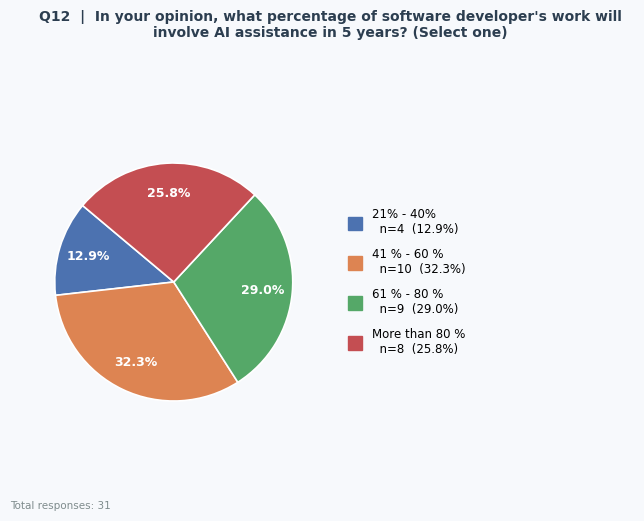


══════════════════════════════════════════════════════════════════════════
  Q13  [multi]
  In which phases of the software development life cycle do you
  anticipate generative AI will take over most human responsibilities
  within the next 3–5 years? (Select up to 3)
══════════════════════════════════════════════════════════════════════════
  Respondents: 30   |   Total selections: 72
──────────────────────────────────────────────────────────────────────────
  Category                                          n       %    95 % CI (Wilson)
──────────────────────────────────────────────────────────────────────────
  Documentation                                    17   56.7%  [0.392, 0.726]
  Code writing                                     15   50.0%  [0.332, 0.668]
  Debugging and issue resolution                   11   36.7%  [0.219, 0.545]
  Testing and quality assurance                    10   33.3%  [0.192, 0.512]
  Requirements analysis                             5   16.7%  [0

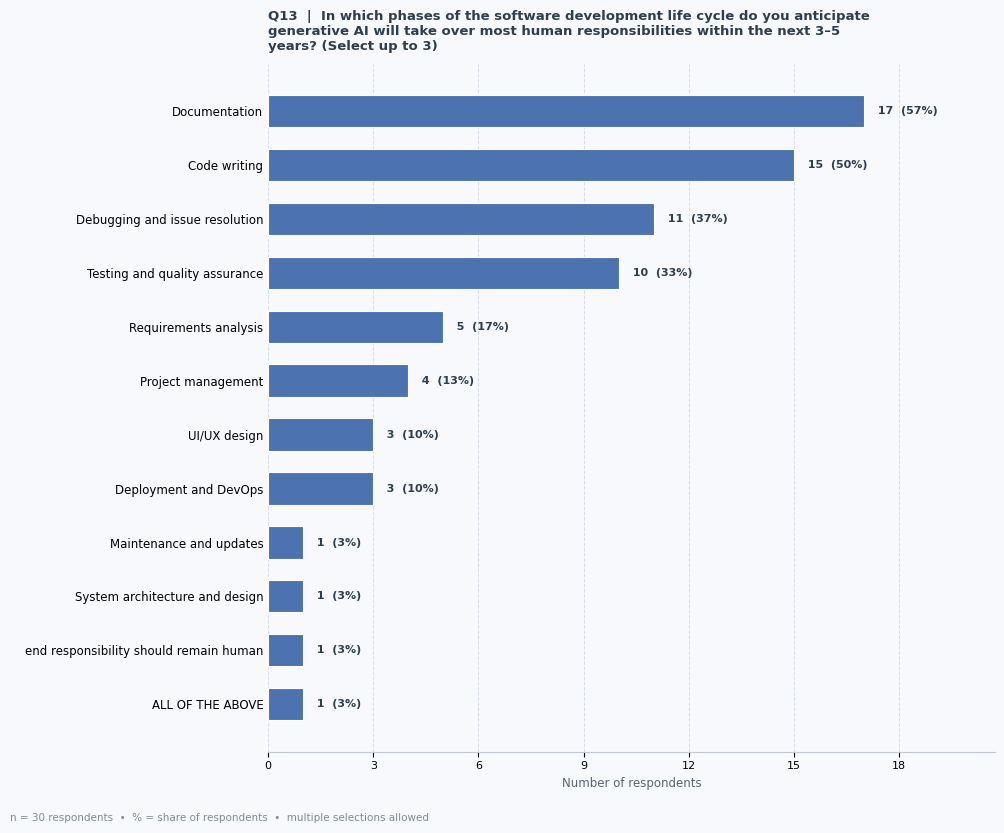


════════════════════════════════════════════════════════════════════════════════════════
  Q14  [scaling]
  Please rate how the importance of each skill is expected to change for future
  software developers in the context of AI-assisted software development. (Please rate
  each from: Decreasing, No Change, Slightly Increasing, Strongly Increasing)
  Scale: Decreasing in Importance → No Change → Slightly Increasing → Strongly Increasing
════════════════════════════════════════════════════════════════════════════════════════
  n = 31 respondents

  ┌─ Fundamental Concepts
  │  Decreasing i:  1 (4%)  No Change:  4 (15%)  Slightly Inc:  8 (30%)  Strongly Inc: 14 (52%)
  │  mean=3.296 CI(np.float64(2.963), np.float64(3.593))  median=4.0  std=0.869
  │  dominant='Strongly Increasing'  positive=81.5%  entropy=1.595 bits  N/A=0

  ┌─ Reviewing and interpreting AI-gene..
  │  Decreasing i:  1 (3%)  No Change:  2 (7%)  Slightly Inc: 11 (38%)  Strongly Inc: 15 (52%)
  │  mean=3.379 CI(np.float6

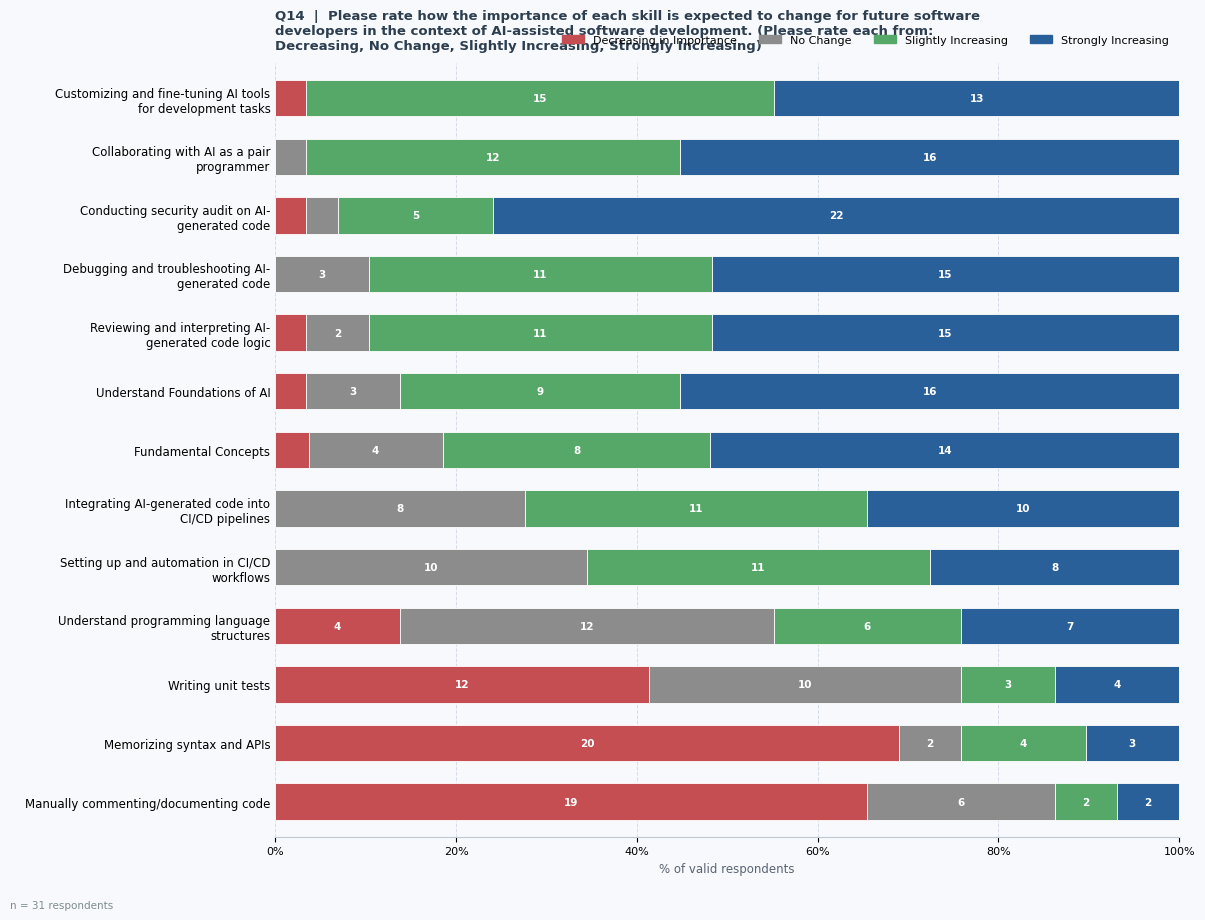

Q15: no data collected for this question.

══════════════════════════════════════════════════════════════════════════
  Q16  [multi]
  Which skills will be most essential for future software developers in
  an AI-assisted development environment? (Select up to 3)
══════════════════════════════════════════════════════════════════════════
  Respondents: 29   |   Total selections: 87
──────────────────────────────────────────────────────────────────────────
  Category                                          n       %    95 % CI (Wilson)
──────────────────────────────────────────────────────────────────────────
  Critical thinking and code review skills         23   79.3%  [0.616, 0.901]
  Understanding limitations of AI-generated code   17   58.6%  [0.407, 0.745]
  Effective prompt engineering for AI tools        10   34.5%  [0.199, 0.527]
  Secure coding and ethical AI awareness            8   27.6%  [0.147, 0.457]
  System design and architecture                    7   24.1%  [0.122, 0

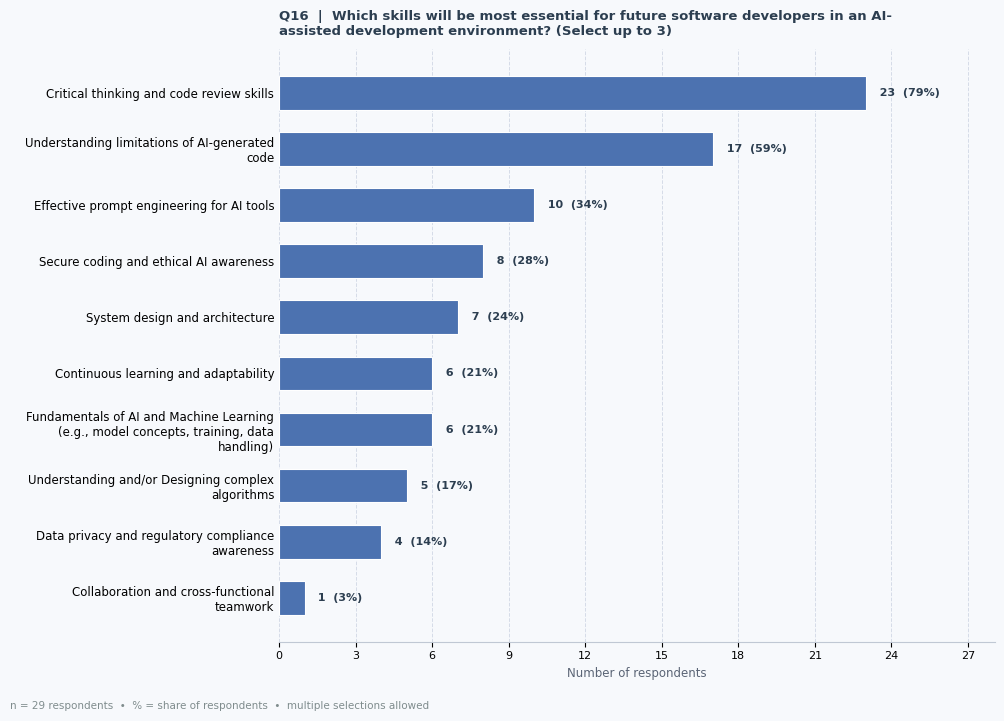


══════════════════════════════════════════════════════════════════════════
  Q17  [multi]
  What are the main challenges you foresee in the near future of AI-
  assisted software development? (Select all that apply)
══════════════════════════════════════════════════════════════════════════
  Respondents: 29   |   Total selections: 126
──────────────────────────────────────────────────────────────────────────
  Category                                          n       %    95 % CI (Wilson)
──────────────────────────────────────────────────────────────────────────
  Security and data privacy risks                  21   72.4%  [0.543, 0.853]
  Developer de-skilling or over-reliance on A...   20   69.0%  [0.508, 0.827]
  Accumulation of technical debt due to low-q...   18   62.1%  [0.440, 0.773]
  Hallucinations or factual inaccuracies in A...   15   51.7%  [0.344, 0.686]
  Lack of trust in AI-generated code               11   37.9%  [0.227, 0.560]
  Intellectual property or legal uncerta

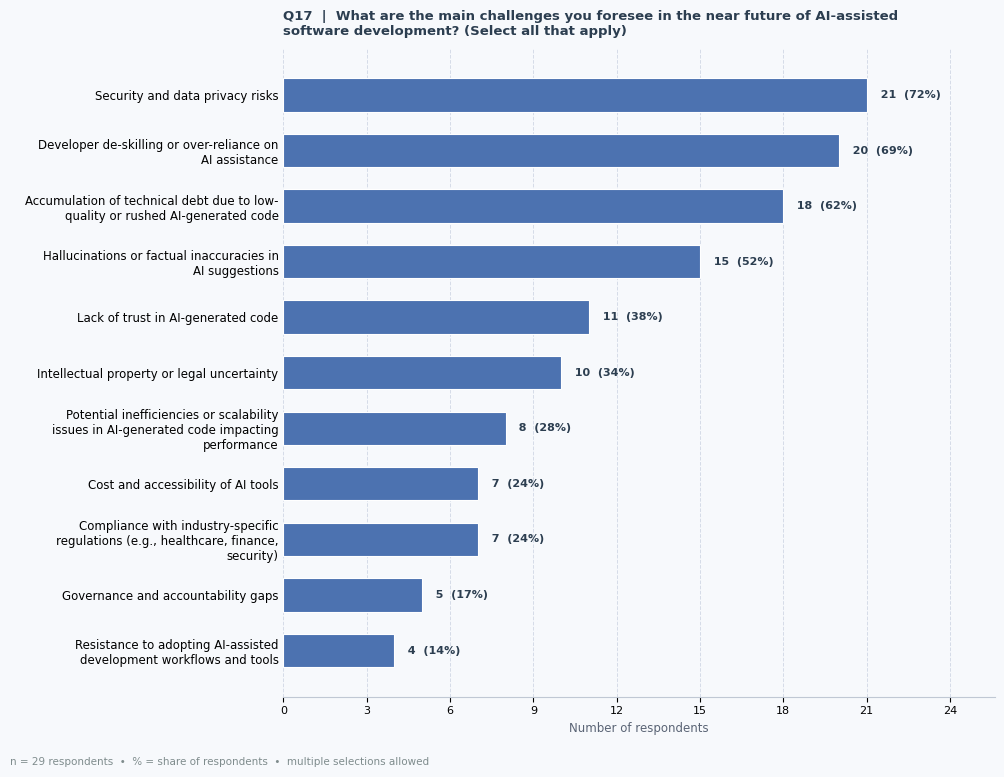

In [21]:
# Analysis: Future of AI in Software Development (Part 1). Questions 12, 13, 14, 15, 16, 17.

for q in range(12,18):
    show_question(SHEETS,q)

## Q12 — Estimated Percentage of AI-Assisted Developer Work in Five Years

### Observation

All 31 respondents answered this question. Notably, no respondent selected the lowest available band — the response options presumably included a category below 21% which received zero selections, meaning the entire sample believes AI assistance will account for at least a fifth of developer work within five years. The distribution across the four represented bands is remarkably flat: **41–60%** leads narrowly at 32.3% (n=10), followed by 61–80% at 29.0% (n=9), More than 80% at 25.8% (n=8), and 21–40% at 12.9% (n=4). Combining the upper two bands — those expecting AI involvement to exceed 60% of developer work — yields 54.8% of respondents, a slim majority anticipating a predominantly AI-assisted future.

### Statistical Support

The normalised Shannon entropy of **0.965** (1.930 bits out of a maximum of 2.0 bits for four categories) is the second highest in the survey, nearly identical to the Q05 binary split and approaching the theoretical maximum for this number of categories. This near-maximum entropy is directly confirmed by the chi-squared test: χ²(3) = 2.677, p = 0.444 — emphatically non-significant, indicating the distribution across the four bands is statistically indistinguishable from uniform. The Wilson CIs for all four categories overlap substantially, with the three leading bands sharing the range approximately [0.186, 0.432]. This means that despite 10 respondents selecting 41–60% as the dominant category, there is no statistical basis for asserting that any single band is more prevalent in the true population than any other. The 12.9% for the 21–40% band is the only outlier from uniformity, but even its CI [0.051, 0.288] overlaps with those of the others.

### Interpretation

The near-uniform distribution across four bands ranging from 21% to "more than 80%" is one of the most intellectually honest findings in the survey. It does not represent confusion or disengagement — it represents genuine, well-founded uncertainty among experienced practitioners about how rapidly and deeply AI assistance will penetrate software development workflows. These are professionals with a median of more than seven years of experience (Q02) who use GenAI daily (Q08) and have developed informed views about both its capabilities and its limitations. Their divergence of opinion about the five-year trajectory is not naivety; it is a calibrated acknowledgement that the rate of change is genuinely unpredictable.

The **complete absence of responses below 21%** is the single most unambiguous finding in this question. Regardless of how the upper range splits, every respondent in this sample — including the most sceptical — believes AI assistance will constitute a substantial and growing portion of developer work. The floor of the distribution has already moved well above zero. In the context of a 2025 survey where respondents already report 83.9% daily GenAI usage, this is perhaps unsurprising, but it establishes a professional consensus baseline: AI assistance in software development is not going away, it is going to increase.

The **near-uniform spread across the upper three bands** (29–32% each) reflects three coherent and defensible positions that experienced developers hold simultaneously in this sample:

Respondents selecting **41–60%** (the modal band, 32.3%) likely hold a measured incrementalist view: AI assistance will become pervasive for well-defined, repetitive coding tasks — generation, testing, documentation — while complex architectural reasoning, stakeholder communication, requirements negotiation, and system design remain predominantly human activities. This view is consistent with the utility profile in Q10, where AI scored highest on structured, bounded tasks and lowest on contextually demanding ones like Code Review, Maintenance Automation, and Security analysis.

Respondents selecting **61–80%** (29.0%) likely anticipate more aggressive capability improvement — tools that handle not just code generation but also a growing share of debugging, refactoring, and system integration work, pushing human involvement into an oversight and direction-setting role rather than a primary execution role. This is broadly consistent with the "AI as pair programmer" framing that appears in Q14.

Respondents selecting **"More than 80%"** (25.8%) hold the most transformative view: that the majority of current development work — including much of what currently requires senior developer judgment — will be AI-assisted or AI-mediated within five years. This position, held by one in four respondents, is not fringe thinking; it is a considered projection from practitioners who are already seeing rapid capability growth in their daily tools.

The **21–40% band** (12.9%, n=4) represents the most conservative position — substantial AI involvement but with human developers remaining the primary agents of the work. These respondents may weight the current limitations of GenAI more heavily than its growth trajectory, pointing to the persistent issues documented in Q11 (logic errors, specification failures, security vulnerabilities) as evidence that human oversight will remain the dominant mode for the foreseeable future.

The distribution's near-uniformity carries a direct and actionable implication for the research question. If a sample of experienced, daily GenAI users cannot reach consensus on whether AI will drive 40%, 60%, or 80%+ of developer work in five years, then skills education and workforce development policy cannot be designed around a single trajectory assumption. The appropriate response is a **portfolio approach** to skill development: investing in the skills that remain valuable across all scenarios (critical thinking, architectural reasoning, security awareness, AI oversight) rather than optimising for any single projected future.

### Cross-Question Context

Reading Q12 alongside Q08 creates a striking temporal contrast: 83.9% of respondents already use GenAI daily in 2025. The median respondent essentially already operates in a highly AI-assisted environment. Their projections for five years hence therefore represent extrapolations from an already-transformed present, not predictions about an untested future. The question implicitly being answered is: "from where we already are, how much further will this go?" — and the answer is a unanimous "further", with genuine disagreement only about how much.

### Limitation

The response bands are unequal in width — 21–40% spans 19 percentage points, 41–60% spans 19 points, 61–80% spans 19 points, but "More than 80%" is an open-ended upper category that could represent 81% or 100%. This asymmetry may have drawn conservative respondents toward the bounded bands and inflated the apparent preference for 41–60%. The question conflates two distinct dimensions — breadth (the proportion of tasks involving AI) and depth (the degree of AI involvement per task) — under the single heading of "percentage of work", which different respondents may have interpreted differently. The five-year timeframe is sufficiently short to be meaningful but sufficiently long to be highly uncertain, and anchoring effects from current usage patterns may systematically bias estimates upward relative to less frequent users. As with all forward-looking survey questions, responses reflect current sentiment and extrapolation rather than actual knowledge of future states.

## Q13 — SDLC Phases Where GenAI Will Take Over Most Human Responsibilities (3–5 Years)

### Observation

Thirty of 31 respondents answered this question, generating 72 total selections — a mean of 2.40 phases per respondent, close to the maximum of three permitted, indicating that most respondents used their allocation substantially. The distribution has a pronounced two-tier structure. A **dominant tier**: Documentation (56.7%, n=17) and Code writing (50.0%, n=15) each selected by roughly half the sample. A **secondary tier**: Debugging and issue resolution (36.7%, n=11) and Testing and quality assurance (33.3%, n=10), each selected by roughly one third. The remaining eight categories — Requirements analysis, Project management, Deployment/DevOps, UI/UX design, and four write-in responses — each fall below 17%, forming a sparse tail. One write-in response is particularly notable: "end responsibility should remain human" — a direct reframing of the question's premise that signals principled disagreement with the notion of AI taking over any SDLC phase.

### Statistical Support

The normalised Shannon entropy of **0.836** (2.997 bits out of a maximum of 3.585 bits for twelve categories) reflects a moderately concentrated distribution — broad participation across categories, but with a clear hierarchy. The chi-squared test yields χ²(11) = 61.000, p < 0.001, confirming that the dominance of Documentation and Code writing is statistically significant and not a sampling artefact. The Wilson CIs for the top two categories — [0.392, 0.726] for Documentation and [0.332, 0.668] for Code writing — are the tightest in the question and their lower bounds both exceed 33%, establishing that majority-or-near-majority expectations for AI takeover in these phases are robust to sampling uncertainty. The two secondary-tier categories have overlapping CIs ([0.219, 0.545] and [0.192, 0.512]), meaning their relative ranking cannot be distinguished statistically.

### Interpretation

The question's framing — "take over most human responsibilities" — is deliberately stronger than Q09's "tasks where you use GenAI" or Q10's "how useful is GenAI". It asks for a prediction about displacement, not current utility. This makes the responses a measure of respondents' threat models for their own profession, filtered through their daily experience of GenAI capabilities. The results reveal a coherent, layered mental model of where AI displacement is most and least plausible.

**Documentation at 56.7%** as the most anticipated site of AI takeover is both unsurprising and revealing. Documentation is widely regarded by developers as the most tedious, most frequently deferred, and least intellectually stimulating SDLC phase — the one where the gap between what should be done and what actually gets done is largest. GenAI's demonstrated ability to generate coherent, structured natural language from code makes this the path of least resistance for AI displacement. Importantly, this finding is consistent with the 45.2% documentation usage rate in Q09 and the 57.7% positive utility rating in Q10 — respondents are not predicting displacement in a domain where they lack personal experience; they are extrapolating from current, observed utility toward a near-term takeover scenario. The implication for skill development is significant: if documentation becomes predominantly AI-generated, the human skill that remains valuable is not writing documentation but specifying, evaluating, and maintaining documentation standards — a higher-order oversight competency rather than a production one.

**Code writing at 50.0%** is the second most anticipated displacement domain, and this finding demands careful interpretation. Half the sample — experienced, senior developers who use GenAI daily — believe that within three to five years, AI will take over most human responsibilities in the core act of writing code. This is not a fringe prediction; it represents the median professional outlook among this population. Read alongside Q12, where 54.8% of respondents expect AI to be involved in more than 60% of developer work within five years, the picture is coherent: the expectation of AI taking over code writing is the mechanism through which those high AI-involvement percentages would be realised. The implication for education and skill development is stark — if code writing is expected to be predominantly AI-mediated within five years, then training programmes centred on coding syntax, language-specific APIs, and implementation-level problem-solving face a fundamental validity challenge. The skills that remain relevant are those that precede and follow code writing: specification, architecture, review, and validation.

**Debugging and issue resolution (36.7%) and Testing and QA (33.3%)** form a coherent secondary tier representing the quality-assurance layer of the SDLC. Their selection by roughly one third of respondents is noteworthy given the relatively modest utility ratings these tasks received in Q10 — Debugging scored 63.0% positive but Testing scored highest of all items at 78.3%. The high utility of GenAI for test generation has apparently translated into a meaningful expectation of displacement in that domain. However, the fact that these phases were selected by only one-third of respondents, rather than the near-majority that selected Documentation and Code writing, suggests that practitioners see the analytical and judgement-intensive aspects of debugging and testing as more resistant to AI displacement than the production aspects. Finding a bug in AI-generated code, understanding why a system fails under edge conditions, or designing a meaningful test strategy may remain human responsibilities even as the mechanical execution of testing becomes AI-assisted.

**Requirements analysis (16.7%) and Project management (13.3%)** at the lower end of named categories represent the human-facing, stakeholder-intensive phases of the SDLC. Their low selection rates reflect a consistent practitioner view: the further a development activity is from structured, syntactic text and the closer it is to ambiguous human communication, negotiation, and organisational context, the less displacement from AI is anticipated. Requirements elicitation involves understanding unstated needs, resolving conflicting priorities, and building trust with non-technical stakeholders — capabilities that current GenAI tools demonstrably lack. Project management similarly involves real-time adaptive decision-making in socially complex environments. The low displacement expectations here are well-calibrated to current AI capabilities.

**Deployment and DevOps (10.0%) and UI/UX design (10.0%)** share the lowest named-category rates. DevOps' low score is somewhat surprising given the automation-friendliness of deployment pipelines, but is consistent with Q10's finding that CI/CD Automation was among GenAI's lowest-utility applications (mean 2.0, no Essential ratings). UI/UX design's low score reflects an understanding that design work is fundamentally about human perception, accessibility, and user psychology — domains where AI assistance is growing but displacement remains distant.

**The write-in responses** deserve individual attention. "ALL OF THE ABOVE" (one respondent) represents the maximally transformative position — a belief that no SDLC phase is immune to AI takeover. "End responsibility should remain human" is the survey's most philosophically charged data point: a respondent who not only declined to select any phase but actively asserted a normative position that human accountability must persist regardless of AI capability. "System architecture and design" and "Maintenance and updates" as write-ins highlight two phases that the pre-defined list omitted — architecture being arguably the highest-stakes omission, since it is the phase where AI displacement would have the most profound long-term consequences for system quality, and maintenance being the phase that consumes the majority of total software lifecycle costs.

### Cross-Question Coherence

Q13 maps with striking consistency onto the task-utility profile established in Q09 and Q10. The phases anticipated to be taken over correspond almost exactly to the tasks currently rated most useful:

| Q13 Phase anticipated for takeover | Q09 Usage | Q10 Positive % |
|---|---|---|
| Documentation | 45.2% | 57.7% |
| Code writing | 74.2% | 74.2% |
| Debugging | 71.0% | 63.0% |
| Testing / QA | 48.4% | 78.3% |
| Requirements analysis | 3.2% | — |
| Deployment / DevOps | 3.2% | 23.5% (CI/CD) |

The phases where GenAI is already most used and most useful are precisely the ones most respondents expect to see AI take over. This is not circular reasoning — it is practitioners extrapolating from observed capability trajectories, and the coherence across three distinct question framings strengthens confidence in the finding.

### Limitation

The question's framing — "take over most human responsibilities" — is normatively loaded and may have been interpreted differently by different respondents. Some may have read it as a prediction they believe is likely; others may have selected phases they believe AI could plausibly take over rather than those they expect it to. The single write-in rejecting the premise entirely suggests at least one respondent found the framing sufficiently objectionable to resist it rather than engage with it. The "select up to 3" constraint artificially limits the distribution — respondents who believe AI will take over five or six phases can only express three of them, which likely understates the breadth of displacement expectations for the most transformative thinkers in the sample. The absence of System architecture and design from the pre-defined options is a notable gap: this is precisely the phase where AI displacement questions are most consequential for the future of the profession, and its omission may have suppressed a potentially significant finding.

## Q14 — Expected Change in Skill Importance for Future Software Developers

### Observation

All 31 respondents rated all 13 skill items — there are zero N/A responses across the entire question, making this the most completely answered scaling question in the survey and indicating that every item was perceived as relevant to every respondent's professional context. The 13 items separate into three structurally distinct groups based on the direction and strength of expected change:

**Strongly increasing importance** (positive % ≥ 80%, mean ≥ 3.3): Collaborating with AI as a pair programmer (96.6%, mean 3.517), Customizing and fine-tuning AI tools (96.6%, mean 3.379), Conducting security audit on AI-generated code (93.1%, mean 3.655), Debugging and troubleshooting AI-generated code (89.7%, mean 3.414), Reviewing and interpreting AI-generated code (89.7%, mean 3.379), Understand Foundations of AI (86.2%, mean 3.379), Fundamental Concepts (81.5%, mean 3.296)

**Moderately increasing importance** (positive % 44–73%, mean 2.5–3.1): Integrating AI-generated code into CI/CD pipelines (72.4%, mean 3.069), Setting up and automation in CI/CD workflows (65.5%, mean 2.931), Understand programming language structures (44.8%, mean 2.552)

**Decreasing importance** (dominant = Decreasing, mean ≤ 2.0): Memorizing syntax and APIs (69% Decreasing, mean 1.655), Manually commenting/documenting code (66% Decreasing, mean 1.552), Writing unit tests (41% Decreasing, mean 1.966)

### Statistical Support

The ordinal means span the widest range of any scaling question in the survey: from **1.552** (Manually commenting/documenting code) to **3.655** (Conducting security audit on AI-generated code) — a spread of 2.103 points on a four-point scale. This range is exceptional: it indicates that respondents are not uniformly nudging all skills slightly upward or downward, but making sharply differentiated judgements about which competencies become more and which become less central in an AI-assisted future. The tightest bootstrap CIs belong to the items with the strongest consensus: Collaborating with AI as pair programmer [3.310, 3.724] and Conducting security audit [3.345, 3.897] — both with lower bounds exceeding 3.3, establishing near-certainty that these skills are seen as strongly increasing in importance. Conversely, Memorizing syntax and APIs [1.309, 2.069] has its upper bound below 2.1, establishing near-certainty that this skill is seen as decreasing. Shannon entropy ranges from **1.075 bits** (Conducting security audit — highest consensus in the question) to **1.886 bits** (Understand programming language structures — maximum disagreement, with responses distributed across all four levels almost uniformly).

### Interpretation

Q14 is the analytical centrepiece of this survey. More than any other question, it directly addresses the research objective: understanding what skill sets future software developers will require in the era of GenAI. The 13-item profile that emerges is not a minor recalibration of existing competency frameworks — it describes a fundamental restructuring of the software developer role, with three coherent themes running through the data.

---

**Theme 1: The Ascendancy of AI-Oversight Skills**

The four items with the highest means and tightest CIs — Conducting security audit on AI-generated code (3.655), Collaborating with AI as pair programmer (3.517), Debugging and troubleshooting AI-generated code (3.414), and Reviewing and interpreting AI-generated code (3.379) — share a common structure: they are all skills that operate *on* AI output rather than *instead of* AI. They represent a new category of meta-competency that did not exist as a distinct professional skill before the GenAI era: the ability to work with, direct, evaluate, and correct AI-generated artefacts.

**Conducting security audit on AI-generated code** achieves the highest mean (3.655) and the lowest entropy (1.075 bits) of any item in the question — making it simultaneously the most important and the most consensually agreed-upon skill in the entire survey. Seventy-six percent of respondents selected Strongly Increasing, with only two respondents (6%) combined selecting Decreasing or No Change. This finding must be read in direct dialogue with Q10 and Q11: respondents rate GenAI as low-utility for security analysis (mean 2.053, Q10) and simultaneously identify security vulnerabilities in AI-generated code as one of the top three reported issues (54.8%, Q11). The logical structure is clear — AI introduces security risks that AI cannot reliably detect, therefore human security audit capability must compensate. The skill gap this creates is one of the most urgent findings of the entire study.

**Collaborating with AI as a pair programmer** (96.6% positive, mean 3.517) and **Customizing and fine-tuning AI tools** (96.6% positive, mean 3.379) together define a new professional orientation that is less about producing code and more about orchestrating, directing, and configuring the AI systems that produce code. The near-unanimous endorsement of these skills — with zero Decreasing responses for collaboration and only one for customization — represents the strongest cross-cutting consensus in the survey. Practitioners are not divided about whether working effectively with AI will be a core developer competency; they are universally certain that it will be.

---

**Theme 2: The Enduring and Deepened Value of Foundational Knowledge**

**Fundamental Concepts** (81.5% positive, mean 3.296) and **Understand Foundations of AI** (86.2% positive, mean 3.379) both register as strongly increasing in importance — a finding that directly contradicts a common fear in educational discourse, namely that AI tools will erode the need for deep theoretical knowledge. The respondents in this survey, with their substantial experience and daily GenAI use, assert the opposite: foundational knowledge becomes *more* important in an AI-assisted environment, not less.

The logic is coherent and well-supported by the broader data. When code generation is partially automated, the developer's primary value shifts from production to evaluation. Evaluating AI-generated code — determining whether it is correct, efficient, maintainable, and secure — requires precisely the foundational understanding that the code itself might appear to render unnecessary. A developer who cannot reason about algorithmic complexity, memory management, or concurrency semantics cannot reliably judge whether AI-generated code is fit for purpose, even if they could not have written it themselves. Fundamental Concepts is not declining because AI can generate code; it is increasing because AI-generated code requires evaluation, and evaluation requires understanding.

This finding has profound implications for computer science and software engineering education. The argument that curricula can be simplified or shortened because AI handles implementation is directly refuted by the practitioners who use these tools daily.

---

**Theme 3: The Decline of Mechanical, AI-Substitutable Skills**

The three items with decreasing importance form a coherent and internally consistent group: **Memorizing syntax and APIs** (mean 1.655, 69% Decreasing), **Manually commenting/documenting code** (mean 1.552, 66% Decreasing), and **Writing unit tests** (mean 1.966, 41% Decreasing).

**Memorizing syntax and APIs** is the clearest and most expected finding in the survey. With a mean of 1.655 and an upper CI bound of 2.069, the evidence that practitioners view this skill as declining is robust. The reasoning is direct: if GenAI can reliably autocomplete syntactically correct code and reference API documentation in real time, the cognitive overhead of memorising syntax provides no additional value. This has been a trend since the advent of intelligent IDEs, and GenAI accelerates it to the point of near-obsolescence as an examined competency. The implication for technical interviews — which have traditionally placed significant weight on syntax recall and API knowledge — is substantial and is likely reflected in Q22 responses.

**Manually commenting and documenting code** (mean 1.552, the lowest-rated item overall, 66% Decreasing) is the complement of Documentation's dominance in Q13: if AI is expected to take over documentation production (anticipated by 56.7% in Q13), then the human skill of manually writing documentation correspondingly declines. This is not a loss of documentation quality — it is a redistribution of responsibility from production to oversight. The human skill that replaces manual documentation writing is the ability to specify what documentation should contain, to evaluate whether AI-generated documentation is accurate and complete, and to maintain documentation standards — higher-order competencies rather than production ones.

**Writing unit tests** (mean 1.966, 41% Decreasing) is the most contested item in the decreasing group, with the highest entropy among declining skills (1.789 bits) and the widest CI [1.586, 2.345]. Forty-one percent see it as decreasing while 24% see it as slightly or strongly increasing — reflecting genuine professional disagreement. The disagreement is substantive: one camp argues that if AI generates tests as reliably as code (consistent with Q10's 78.3% positive rating for test generation), then the human skill of writing unit tests becomes redundant. The opposing camp argues that understanding what to test, why to test it, and what constitutes a meaningful test case — the conceptual layer above test implementation — remains a human responsibility even when implementation is automated. Both positions are defensible, and the data reflects this genuine uncertainty rather than papering over it.

---

**Theme 4: The Contested Middle — Programming Language Structures**

**Understanding programming language structures** occupies the most statistically uncertain position in Q14: mean 2.552, dominant = No Change (41%), entropy 1.886 bits (maximum disagreement), and the widest standard deviation (1.021) in the question. Fourteen percent see it as decreasing, 41% as unchanged, 21% as slightly increasing, and 24% as strongly increasing — a distribution that is essentially flat across all four options.

This is not noise — it is genuine, substantiated professional disagreement about whether deep language knowledge remains relevant when AI handles much of the implementation. The No Change plurality may reflect a view that language structure understanding is a stable baseline competency — neither growing nor shrinking in relevance regardless of AI assistance. The 45% who see it as increasing likely take the same position articulated above for Fundamental Concepts: you cannot evaluate AI-generated code in a language you do not understand structurally. The 14% who see it as decreasing may be the most radical adopters, anticipating a future where language-agnostic prompt engineering replaces language-specific expertise entirely. The width of this disagreement — across all four response levels — makes it one of the most important unresolved questions in the survey's skill profile.

### Cross-Question Synthesis

Q14 integrates and explains patterns that have accumulated across the survey:

| Q14 Finding | Supporting evidence from earlier questions |
|---|---|
| Security audit strongly increasing | Q10: Security analysis lowest utility (mean 2.053); Q11: 54.8% report security vulnerabilities in AI code |
| Fundamental Concepts increasing | Q02: Senior-heavy sample values theoretical grounding; Q20 (anticipated): concern about junior de-skilling |
| Memorizing syntax decreasing | Q08: 83.9% daily AI use makes real-time assistance ubiquitous |
| Documentation manually decreasing | Q13: 56.7% expect AI to take over documentation phase |
| AI collaboration strongly increasing | Q07: 100% organisational permission; Q08: 83.9% daily use establishes baseline |
| Writing unit tests contested | Q10: Test generation highest utility (78.3%); Q13: Testing/QA secondary displacement tier (33.3%) |

### Limitation

The question asks respondents to predict future importance changes, which introduces forecasting bias alongside measurement bias. Respondents with more optimistic views of AI capability trajectories will systematically rate AI-substitutable skills as more steeply declining and AI-complementary skills as more steeply increasing than those with more sceptical trajectories. The ordinal scale does not capture the magnitude of change — "Strongly Increasing" for security audit skills and "Strongly Increasing" for AI collaboration may represent very different magnitudes of change in practice, but are coded identically. The absence of a "Not Applicable to my role" option means all 31 respondents rated all 13 items regardless of role relevance — a Data Engineer's view of CI/CD skill trajectories may carry less informational value than a DevOps engineer's, yet both are weighted equally. Finally, the 13 items were pre-defined by the survey designer and may not exhaustively capture the skill landscape: prompt engineering as a standalone competency, for instance, does not appear as an explicit item despite its relevance to the questions asked.

## Q16 — Most Essential Skills for Future Software Developers in an AI-Assisted Environment

### Observation

Twenty-nine of 31 respondents answered this question, generating 87 total selections — a mean of **3.0 selections per respondent**, exactly at the permitted maximum of three. This is the highest utilisation of the selection allowance of any constrained multi-choice question in the survey, indicating that respondents found it genuinely difficult to narrow their choices and used every allocation available. The distribution has a striking hierarchical structure. A **dominant tier**: Critical thinking and code review skills leads emphatically at 79.3% (n=23), nearly double the second-place category. A **secondary tier**: Understanding limitations of AI-generated code at 58.6% (n=17), and Effective prompt engineering at 34.5% (n=10). A **broad middle field**: Secure coding and ethical AI awareness (27.6%), System design and architecture (24.1%), Fundamentals of AI and ML (20.7%), Continuous learning and adaptability (20.7%), and Complex algorithms (17.2%) — each selected by roughly one in five respondents. A **sparse tail**: Data privacy and regulatory compliance awareness (13.8%, n=4) and Collaboration and cross-functional teamwork (3.5%, n=1).

### Statistical Support

The normalised Shannon entropy of **0.898** (2.983 bits out of a maximum of 3.322 bits for ten categories) is the highest of any constrained multi-choice question in the survey, reflecting genuine spread across the category space. Despite this breadth, the chi-squared test yields χ²(9) = 44.609, p < 0.001, confirming that the dominance of the top two categories is statistically significant. The Wilson CI for Critical thinking and code review skills [0.616, 0.901] is the tightest in the question — its lower bound exceeds 61%, establishing with high confidence that this skill is genuinely the clear plurality choice in the population, not merely a sampling artefact. Understanding limitations of AI-generated code [0.407, 0.745] similarly has a lower bound exceeding 40%, confirming robust second-place status. Below these two, the CIs for the remaining categories overlap substantially, making relative rankings within the middle field statistically indistinguishable.

### Interpretation

Q16 is the direct counterpart to Q14: where Q14 asked respondents to rate importance changes across a pre-defined skill list, Q16 asked them to freely nominate — within a three-choice constraint — the skills they consider most essential. The convergence and divergence between the two questions is analytically rich.

**Critical thinking and code review skills at 79.3%** is the strongest selection signal in any constrained multi-choice question in the survey, and it delivers the clearest single finding of the entire study. Nearly four in five respondents, when forced to choose their three most essential future skills, named critical thinking and code review as one of them. This is not a marginal preference — it is a near-consensus statement from experienced, daily GenAI users about the cognitive competency that remains irreducibly human in an AI-assisted development environment.

The pairing of "critical thinking" with "code review" in a single item is semantically deliberate and important. Code review is the professional practice; critical thinking is the cognitive foundation that makes it meaningful. Without critical thinking — the ability to reason about what code is doing, why it was written a particular way, whether it handles edge cases correctly, and whether it satisfies the intended requirements — code review degenerates into syntactic checking that GenAI can do better and faster. With it, code review becomes the primary quality gate between AI-generated output and production deployment. This finding integrates seamlessly with Q14, where Reviewing and interpreting AI-generated code scored 89.7% positive (second highest item), and with Q10, where Code Review received the highest entropy rating (maximum disagreement about utility), suggesting that human critical review is needed precisely because AI assistance in review is inconsistent and unreliable.

The 79.3% selection rate also implies something about what respondents did *not* choose. With a three-selection limit and nine other options available, every respondent who chose Critical thinking was forgoing an alternative. The fact that 23 of 29 respondents spent one of their three allocations on this single item — despite the richness of the remaining options — signals that they view it as categorically more important than the alternatives, not merely marginally preferred.

**Understanding limitations of AI-generated code at 58.6%** is the essential epistemic complement to code review skill. Effective code review of AI output requires not just general critical thinking but specific, calibrated knowledge of *where* AI tools fail, *how* they fail, and *why* they fail. Knowing that LLM-generated code tends to follow training-data-dominant patterns rather than optimal solutions, that it is susceptible to confident hallucination in less-represented domains, that it can produce syntactically correct but semantically incorrect code, and that it tends to underperform on security-sensitive operations — this contextual knowledge transforms code review from a generic activity into a targeted, efficient quality-assurance process. The 58.6% selection rate places this skill in unambiguous second position, selected by more than half the sample and separated from the third-place category by 24 percentage points.

Together, Critical thinking (79.3%) and Understanding AI limitations (58.6%) define what might be termed the **AI-oversight competency cluster**: the paired skills of knowing how to evaluate AI output and knowing where AI output is most likely to fail. Their combined dominance in Q16 directly reflects the practical experience documented in Q11, where logic errors (80.7%) and specification failures (83.9%) are the most commonly reported issues with AI-generated code, and in Q10, where the security, maintenance, and review tasks show the lowest utility ratings. Respondents are naming as most essential precisely the skills needed to compensate for the failures they encounter most frequently.

**Effective prompt engineering at 34.5%** holds a somewhat surprising third position — surprising because prompt engineering is the most distinctively new skill on the list, yet it ranks behind two competencies that pre-date GenAI. This ordering makes a coherent statement: practitioners believe that knowing how to work well with AI tools (prompt engineering) is less foundational than knowing how to evaluate AI output critically and understand its failure modes. Prompt engineering skill without critical evaluation skill produces fluent generation without quality assurance — the precise risk that the top two categories are designed to counteract. The 34.5% selection rate is still substantial, representing one in three respondents who view prompt engineering as one of their top-three essential skills, but its third-place position relative to evaluation and understanding skills is itself a meaningful prioritisation signal.

**Secure coding and ethical AI awareness (27.6%) and System design and architecture (24.1%)** form a coherent pair in the middle field, each selected by roughly one in four respondents. Their presence here is consistent with Q14, where security audit scored highest (mean 3.655) and with Q11, where security vulnerabilities ranked third most common issue (54.8%). The relatively modest selection rates — below 30% despite the strong signal in Q14 — likely reflect the three-choice constraint: when forced to prioritise, respondents concentrated their selections on the two dominant categories, leaving security and architecture as important but secondary considerations. This does not indicate that these skills are unimportant; it indicates that critical thinking and AI-limitation understanding are considered even more foundational.

**Fundamentals of AI and Machine Learning (20.7%)** and **Continuous learning and adaptability (20.7%)** share identical selection rates despite representing very different competency types. AI/ML fundamentals being selected by only one in five respondents is somewhat surprising given its strong showing in Q14 (86.2% positive, mean 3.379), and may reflect the three-choice constraint suppressing skills that are important but not perceived as most differentiating. Continuous learning's identical rate is notable: in a field changing as rapidly as AI-assisted development, adaptability might be expected to rank higher. Its modest selection rate may indicate that respondents view it as a general professional virtue rather than a specifically AI-era skill — a background condition rather than a differentiating competency.

**Understanding and designing complex algorithms (17.2%)** is a technically specific competency whose modest selection rate may reflect the ambivalence visible in Q14, where Writing unit tests showed the highest disagreement. Complex algorithmic understanding is precisely the kind of skill that AI tools can partially substitute for in implementation while leaving the conceptual layer human — its modest but non-negligible selection rate suggests a minority of respondents, likely those in more computationally intensive roles (Data Engineers, Data Scientists identified in Q01), view it as critical.

**Collaboration and cross-functional teamwork (3.5%, n=1)** is the most striking undercount in the question. Only one respondent selected it, despite the growing literature on AI-assisted development requiring more intensive human collaboration as teams adapt to new workflows. Its near-absence may reflect the individual-level framing of the question ("skills for future software developers") rather than a genuine belief that teamwork is unimportant — respondents may have interpreted "essential skills" as technical competencies rather than soft or interpersonal skills.

### Cross-Question Synthesis

Q16's findings integrate with unprecedented coherence across the prior survey:

| Q16 Skill | Supporting evidence |
|---|---|
| Critical thinking and code review | Q14: Reviewing AI code 89.7% positive; Q10: Code review lowest utility (max entropy); Q11: Logic errors 80.7% |
| Understanding AI limitations | Q11: Specification failures 83.9%, logic errors 80.7%; Q10: Security, CI/CD, maintenance lowest utility |
| Prompt engineering | Q09: Brainstorming most common task 80.7%; Q14: AI collaboration 96.6% positive |
| Secure coding | Q10: Security utility mean 2.053 (lowest); Q11: Security vulnerabilities 54.8%; Q14: Security audit mean 3.655 (highest) |
| System design | Q13: Architecture omitted from displacement predictions; Q14: Fundamental Concepts 81.5% positive |
| AI/ML fundamentals | Q14: Understand Foundations of AI 86.2% positive (mean 3.379) |

The most powerful cross-question signal is the triangulation between Q11 (what goes wrong with AI-generated code), Q10 (where AI is least useful), Q14 (which skills increase most in importance), and Q16 (which skills are most essential): all four converge on the same conclusion from four different angles — the future developer's primary value is not in generating code but in critically evaluating, securing, and directing the AI systems that generate it.

### Limitation

The three-selection constraint introduces a forced-choice compression that may artificially suppress the apparent importance of skills ranked fourth through seventh by individual respondents. A respondent who values Critical thinking, AI limitations, Security, System design, and Prompt engineering equally can only express three, biasing the aggregate toward the most universally shared top-three rather than the full distribution of valued competencies. The bundling of "Critical thinking" with "code review skills" into a single item prevents disaggregation — it is unknown whether respondents were selecting primarily for the cognitive skill (critical thinking) or the professional practice (code review), or genuinely both. Two respondents (6.5%) did not answer the question, and while this is a minor dropout, their absence from the denominator slightly inflates the percentage figures relative to the full sample of 31. Finally, the pre-defined skill categories reflect the survey designer's conceptualisation of the skill landscape — prompt engineering appears as a single category despite encompassing a broad range of sub-skills, and some emerging competencies (such as AI governance, context engineering, or model evaluation) are absent entirely.

## Q17 — Main Challenges Foreseen in AI-Assisted Software Development

### Observation

Twenty-nine of 31 respondents answered this question, generating 126 total selections — a mean of **4.34 challenges per respondent**, the second highest selection density of any multi-choice question in the survey after Q09's 4.87. The absence of a selection cap means respondents could express the full breadth of their concern, and they did: the average respondent identified more than four distinct challenges, indicating that the perceived challenge landscape is broad and multi-dimensional rather than concentrated on a single dominant concern. The distribution has a pronounced gradient from top to bottom. A **high-concern tier** (selected by more than half the sample): Security and data privacy risks (72.4%), Developer de-skilling or over-reliance on AI (69.0%), Accumulation of technical debt (62.1%), and Hallucinations or factual inaccuracies (51.7%). A **moderate-concern tier** (selected by roughly one quarter to two fifths): Lack of trust in AI-generated code (37.9%), Intellectual property or legal uncertainty (34.5%), Potential inefficiencies or scalability issues (27.6%), Compliance with industry-specific regulations (24.1%), and Cost and accessibility (24.1%). A **lower-concern tier**: Governance and accountability gaps (17.2%) and Resistance to adoption (13.8%).

### Statistical Support

The normalised Shannon entropy of **0.947** (3.275 bits out of a maximum of 3.459 bits for eleven categories) is the highest of any question in the entire survey — approaching the theoretical maximum for this number of categories, indicating an exceptionally broad distribution of concern across all eleven items. Despite this near-uniform spread, the chi-squared test yields χ²(10) = 32.365, p = 0.0003, confirming that the top-tier concentration is statistically significant. The Wilson CI for Security and data privacy risks [0.543, 0.853] has a lower bound exceeding 54%, robustly establishing majority-level concern. Developer de-skilling [0.508, 0.827] similarly exceeds 50% at its lower bound. The high entropy combined with statistical significance creates an important interpretive nuance: the distribution is broad — no single challenge dominates overwhelmingly — but the top four categories are genuinely elevated above the rest in a statistically meaningful way.

### Interpretation

Q17 presents the most expansive challenge taxonomy in the survey, and the 4.34 mean selections signal that practitioners do not perceive the risks of AI-assisted development as singular or isolated. The challenges are systemic and interlocking, and the data reflects this: respondents checking four or more categories are not expressing confusion but recognising that security risks, de-skilling, technical debt, and hallucinations are not independent problems but mutually reinforcing dynamics within the same adoption process.

**Security and data privacy risks at 72.4%** leads the challenge ranking, completing a triangle of security-related findings that spans three questions. In Q10, security analysis rated as GenAI's lowest-utility application (mean 2.053). In Q11, security vulnerabilities in AI-generated code ranked as the third most commonly experienced issue (54.8%). In Q14, conducting security audits on AI-generated code achieved the highest importance-increase rating in the entire survey (mean 3.655, 93.1% positive). Q17 now confirms that security and privacy risks are simultaneously the most widely reported current problem, the least well-served by current AI tools, the most urgently needed new skill, and the most widely anticipated future challenge. The consistency of this finding across four independently framed questions is one of the strongest and most actionable signals in the entire study. It is not a concern about a theoretical future risk — it is a documented, experienced, daily reality that practitioners expect to intensify.

**Developer de-skilling or over-reliance on AI at 69.0%** is the second most anticipated challenge — selected by more than two-thirds of respondents and within statistical uncertainty of the top position. This finding carries particular weight given the demographic profile of the respondents: these are experienced practitioners (45.2% with more than ten years of experience, Q02) who use GenAI daily (83.9%, Q08) and work in organisations that at minimum permit its use (100%, Q07). They are not expressing this concern from outside the adoption process — they are expressing it as participants who can observe the de-skilling dynamic operating in real time around them, and in some cases within themselves. The concern is not hypothetical; it is phenomenological.

The mechanism of de-skilling in AI-assisted development is well-understood by practitioners even if incompletely theorised in the academic literature. When a junior developer's first reflex for any coding problem is to prompt an AI tool rather than reason through it, the productive struggle that builds deep understanding is bypassed. The solution appears — often correctly — but the cognitive pathway that would have encoded the underlying concept is never activated. Over time and at scale, this produces developers who can direct AI tools competently but cannot function without them, a brittleness that becomes catastrophic when the tools fail, produce incorrect output, or are unavailable. The 69.0% selection rate for this challenge, read alongside the 58.6% selection of "Understanding limitations of AI-generated code" in Q16 and the 81.5% positive rating for Fundamental Concepts in Q14, suggests that practitioners have a sophisticated and coherent model of this risk — and have identified the response: maintaining foundational knowledge as the antidote to tool dependency.

**Accumulation of technical debt at 62.1%** is the third most widely anticipated challenge and the one most directly tied to the code quality failures documented in Q11. When AI-generated code contains logic errors (80.7%), specification failures (83.9%), and security vulnerabilities (54.8%), and when that code is reviewed hastily or incompletely (Code Review scored lowest utility in Q10, mean 2.391), the result is the progressive accumulation of flawed, poorly understood code in production systems. Technical debt from AI-generated code has distinctive characteristics that make it more insidious than traditional technical debt: it may be syntactically clean and pass automated tests while containing subtle semantic errors or security vulnerabilities that only manifest under specific conditions. The confidence of AI output — fluent, well-formatted, apparently correct — may reduce the critical scrutiny applied during review, accelerating debt accumulation relative to code whose human origin signals the possibility of error more honestly.

**Hallucinations or factual inaccuracies at 51.7%** is selected by a majority of respondents, reflecting lived experience rather than theoretical concern. In the context of software development, hallucinations manifest as references to non-existent APIs, syntactically plausible but semantically incorrect algorithms, fictitious library functions, and confidently stated but factually wrong technical claims. The 51.7% selection rate likely understates the actual exposure rate — many respondents who did not select this item may encounter hallucinations regularly but classify them as subsumed within "logic errors" (Q11) or "code that does not follow specifications" (Q11). The independence of hallucinations as a listed challenge signals that at least half the sample experiences AI fabrication as a qualitatively distinct problem from mere incorrectness.

**Lack of trust in AI-generated code at 37.9%** occupies a structurally interesting position: it is less a technical challenge than a psychological and organisational one. Insufficient trust creates its own problems — excessive re-checking of competent AI output wastes developer time and reduces the productivity gains that motivated adoption. But insufficient trust also serves as a protective mechanism against the code quality and security risks documented elsewhere. The 37.9% selection rate suggests that calibration of trust — neither blind acceptance nor reflexive rejection — is itself a skill and a challenge that practitioners recognise but do not always name explicitly.

**Intellectual property or legal uncertainty at 34.5%** is a challenge that operates at a different level from the technical concerns dominating the top tier — it is a regulatory and legal risk rather than a code quality risk. Its selection by one in three respondents, despite being a concern that affects organisations rather than individual developers directly, reflects an awareness that the legal framework governing AI-generated code — copyright ownership, liability for AI-introduced errors, compliance with data protection regulations in training data — remains genuinely unresolved in the Netherlands and across the EU as of the survey date. The EU AI Act's implications for software development tooling were still being operationalised during the survey period (July–November 2025), and this regulatory uncertainty is likely reflected in the 34.5% selection rate.

**Potential inefficiencies or scalability issues at 27.6%** connects to Q10's finding that GenAI scores lowest on Maintenance Automation (mean 1.875) and CI/CD Automation (mean 2.0). Developers with architectural and systems-level experience are aware that AI-generated code, optimised for immediate correctness rather than long-term maintainability or performance at scale, may introduce subtle inefficiencies that are harmless in small-scale use but become critical under production load. This concern is likely disproportionately held by Software Architects (22.6%, Q01) and senior developers in large enterprises (41.9%, Q03).

**Resistance to adoption at 13.8%** — the lowest-rated challenge — is the inverse finding to Q07's universal organisational permissiveness. When every respondent works in an organisation that permits or encourages GenAI use, resistance to adoption is simply not a salient challenge in this sample's experience. This does not mean resistance does not exist in the broader population; it means that in the Rotterdam ICT ecosystem represented here, adoption has progressed sufficiently that resistance is no longer the primary friction point. The friction has moved downstream — from "whether to adopt" to "how to manage the consequences of adoption" — and Q17's top four challenges define precisely those consequences.

### Cross-Question Synthesis

Q17 functions as a forward-looking risk register that integrates and extends findings from across the survey. The most important integrative observation is the alignment between experienced problems (Q11), current utility gaps (Q10), anticipated skill increases (Q14), and identified future challenges (Q17):

| Challenge (Q17) | Current reality | Skill response |
|---|---|---|
| Security and data privacy risks (72.4%) | Security vulnerabilities in AI code: 54.8% (Q11); Security utility mean 2.053 (Q10) | Security audit: highest Q14 item (mean 3.655) |
| Developer de-skilling (69.0%) | Daily use 83.9% (Q08); Fundamental Concepts strongly increasing (Q14) | Critical thinking: 79.3% Q16; Fundamentals: 81.5% Q14 |
| Technical debt accumulation (62.1%) | Logic errors 80.7%, spec failures 83.9% (Q11); Code review lowest utility (Q10) | Code review skills: 79.3% Q16 |
| Hallucinations (51.7%) | Logic/algorithmic errors: 80.7% (Q11) | Understanding AI limitations: 58.6% Q16 |

The survey does not merely identify challenges in isolation — it traces the full causal chain from current tool limitations through experienced problems to anticipated future risks and required skill responses. The coherence of this chain across eleven independently answered questions is strong evidence that the findings reflect genuine practitioner knowledge rather than survey artefacts.

### Limitation

The absence of a selection cap means that respondents who selected all eleven categories — a maximally alarmed response — are counted equally with those who selected two or three. The 4.34 mean selections makes it likely that some respondents approached exhaustive selection, which inflates the percentage figures for lower-tier challenges. The question asks about challenges "foreseen in the near future" without specifying a timeframe, making it impossible to distinguish between challenges respondents expect to emerge versus challenges they are already experiencing — for the top-tier items, the latter is clearly the case, but the boundary is blurred. The eleven pre-defined categories reflect the survey designer's framing of the challenge space; challenges outside this taxonomy — such as environmental costs of AI compute, geopolitical dependencies on AI infrastructure providers, or the homogenisation of code styles across organisations — are invisible in the data. Finally, the two respondents who did not answer (6.5% dropout from the full sample of 31) may represent the most resistant or sceptical practitioners, whose absence slightly biases the challenge profile toward adoption-oriented concerns.


══════════════════════════════════════════════════════════════════════════
  Q18  [single]
  How much do you trust AI-generated code without human review? (Select
  one)
══════════════════════════════════════════════════════════════════════════
  Respondents: 29
──────────────────────────────────────────────────────────────────────────
  Category                                          n       %    95 % CI (Wilson)
──────────────────────────────────────────────────────────────────────────
  Not at all                                       16   55.2%  [0.376, 0.716]
  Somewhat                                         11   37.9%  [0.227, 0.560]
  Mostly                                            2    6.9%  [0.019, 0.220]
──────────────────────────────────────────────────────────────────────────
  Dominant    : Not at all
  Entropy     : 1.270 bits  (normalised: 0.801  — 0=consensus, 1=uniform)
  χ² (uniform): 10.414   p = 0.0055  → ✓ significant at α = 0.05



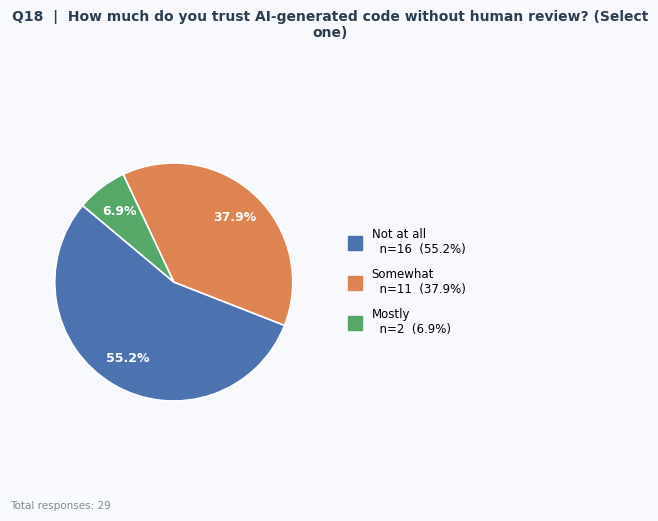


══════════════════════════════════════════════════════════════════════════
  Q19  [single]
  Do you think AI-assisted development will replace traditional
  development roles? (Select one)
══════════════════════════════════════════════════════════════════════════
  Respondents: 29
──────────────────────────────────────────────────────────────────────────
  Category                                          n       %    95 % CI (Wilson)
──────────────────────────────────────────────────────────────────────────
  There will be changes, but software develop...   15   51.7%  [0.344, 0.686]
  It will create new roles and shift existing...   11   37.9%  [0.227, 0.560]
  It will not replace traditional development...    2    6.9%  [0.019, 0.220]
  It will significantly reduce the need for d...    1    3.5%  [0.006, 0.172]
──────────────────────────────────────────────────────────────────────────
  Dominant    : There will be changes, but software development will remain human-centered.
  Entr

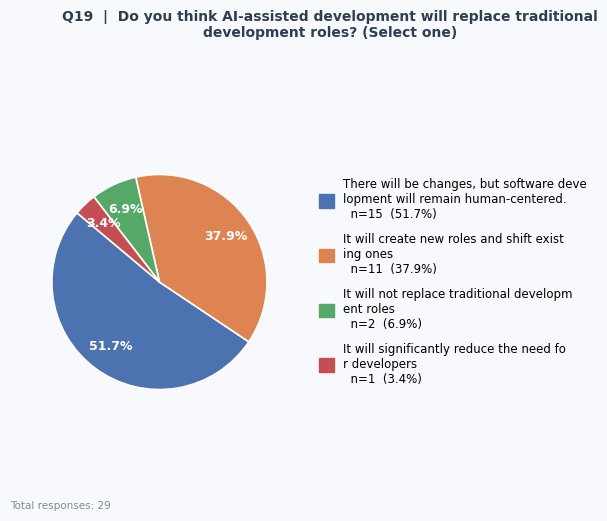


══════════════════════════════════════════════════════════════════════════
  Q20  [single]
  How do you believe AI-assisted development affects the learning curve
  for junior developers? (Select one)
══════════════════════════════════════════════════════════════════════════
  Respondents: 29
──────────────────────────────────────────────────────────────────────────
  Category                                          n       %    95 % CI (Wilson)
──────────────────────────────────────────────────────────────────────────
  Reduces opportunities to learn core problem...   21   72.4%  [0.543, 0.853]
  No significant effect                             2    6.9%  [0.019, 0.220]
  Accelerates learning and skill acquisition        2    6.9%  [0.019, 0.220]
  They will work at a different level of abst...    1    3.5%  [0.006, 0.172]
  Much harder for juniors to get a foothold a...    1    3.5%  [0.006, 0.172]
  Considering AI can be used as a learning as...    1    3.5%  [0.006, 0.172]
  I t

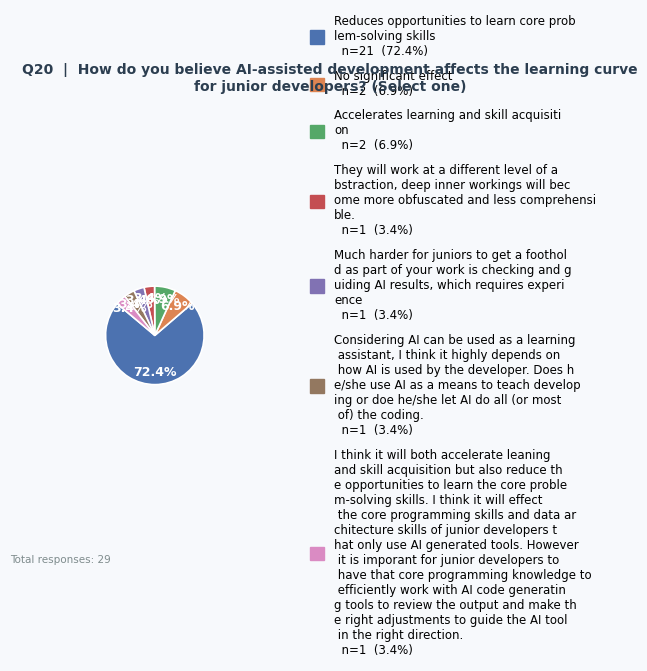


══════════════════════════════════════════════════════════════════════════════
  Q21  [open-ended]  —  Greatest risk of heavy reliance on AI-generated code
  In your opinion, what is the greatest risk of relying heavily on AI-
  generated code? (Open-ended response)
══════════════════════════════════════════════════════════════════════════════
  25 response(s)

   1. jr engineers won't find job as those skill can be replaced with AI

   2. AI only has old code it has been trained on, it misses the latest
      and newest improvements. AI does not really use good design
      principles.

   3. Lack of transparency with issues. Currently an incomplete coverage
      of test path. Loss of knowledge on the deep, inner workings of IT
      systems. Issues with core problems (that seem unexplainable)
      determination. Low security due to lack of Ai quality control.

   4. Code looks good, but is not, developers all have to be able to
      judge this (not just the seniors)

   5. Increa

In [22]:
# Analysis: Future of AI in Software Development (Part 2). Questions 18, 19, 20, 21, 22, 23.

for q in range(18,24):
    show_question(SHEETS,q)

## Q18 — Trust in AI-Generated Code Without Human Review

### Observation

Twenty-nine of 31 respondents answered this question. The distribution skews strongly toward distrust: **"Not at all"** dominates at 55.2% (n=16), **"Somewhat"** follows at 37.9% (n=11), and only two respondents (6.9%) selected **"Mostly"**. No respondent selected a "Completely" or equivalent maximum-trust option — assuming one existed in the original instrument — or if none was offered, the three available categories already reveal an unambiguous picture: more than nine in ten respondents either do not trust or only partially trust AI-generated code when it has not been reviewed by a human. The combined "not at all" and "somewhat" categories account for 93.1% of the sample.

### Statistical Support

The normalised Shannon entropy of **0.801** (1.270 bits out of a maximum of 1.585 bits for three categories) reflects a moderately concentrated distribution — skewed but not maximally so. The chi-squared test yields χ²(2) = 10.414, p = 0.006, confirming that the dominance of the "Not at all" category is statistically significant rather than a sampling artefact. The Wilson CI for "Not at all" [0.376, 0.716] spans a wide range due to the sample size, but its lower bound exceeds 37%, establishing that majority-level distrust is a genuine signal. The CI for "Mostly" [0.019, 0.220] encompasses a range from near-negligible to roughly one in five — meaning that while high-trust respondents are clearly a small minority in this sample, their true population prevalence could be meaningfully larger than the two observed cases suggest. The "Somewhat" CI [0.227, 0.560] overlaps substantially with "Not at all", making the precise boundary between these two positions statistically uncertain, though the directional finding — low trust overall — is robust.

### Interpretation

Q18 delivers one of the most consequential and practically significant findings of the entire survey. The question isolates a specific and critical behaviour: deploying AI-generated code without human review. The response distribution — 55.2% expressing zero trust in this scenario — means that a majority of respondents, all of whom use GenAI daily (Q08), would not deploy AI-generated code without reviewing it first. This is not passive uncertainty; it is an active, experienced-based position held by practitioners who encounter the failures that make unreviewed deployment dangerous on a regular basis.

The finding must be read against the backdrop of Q08's 83.9% daily usage rate. The apparent tension — daily use combined with fundamental distrust — resolves when trust and use are understood as distinct dimensions. Respondents are not using GenAI tools because they trust the output implicitly; they are using them as productivity accelerators while maintaining a persistent human review layer as the quality and security gate. The workflow implied by this combination is: generate with AI, validate with human judgment. This is a fundamentally different adoption model from the autonomous deployment scenarios that some GenAI proponents envisage, and it has direct implications for how productivity gains from AI tools should be measured and how the developer role should be redefined.

**The 55.2% "Not at all" majority** represents the most unambiguous expression of professional caution in the survey. These are respondents who have used GenAI tools sufficiently to develop a clear, experience-based view that the output is not trustworthy without review. The sources of this distrust are well-documented in Q11: 83.9% have experienced AI-generated code that did not follow provided specifications, 80.7% have encountered logic and algorithmic errors, and 54.8% have experienced security vulnerabilities. For a practitioner who has encountered these failures repeatedly, zero trust without review is not an irrational or overly conservative position — it is an empirically calibrated one. The "Not at all" response does not mean these respondents believe AI tools are worthless; combined with their 83.9% daily usage rate, it means they have learned to treat AI as a powerful but unreliable collaborator that requires checking rather than a trustworthy autonomous agent that can be delegated to.

**The 37.9% "Somewhat" trust group** occupies the most nuanced position. Partial trust implies contextual judgment — these respondents likely trust AI-generated code more for some tasks (boilerplate code, well-defined utility functions, documentation) and less for others (security-critical paths, complex business logic, architectural decisions). This calibrated, task-dependent trust is arguably the most sophisticated adoption posture: neither blanket acceptance nor blanket rejection, but differential trust grounded in experience of where AI tools perform reliably and where they do not. The 37.9% who hold this position are implicitly applying the understanding of AI limitations that Q16 identifies as the second most essential future skill (58.6%).

**The 6.9% "Mostly" group** (n=2) is small enough that individual-level inference is unreliable, but their existence is worth noting. Two out of 29 respondents in this experienced, senior-heavy sample are willing to mostly trust AI-generated code without human review. This could reflect exceptionally well-constrained development contexts where AI output is highly predictable (e.g., template-based code generation for well-defined patterns), very specific domains where review is built into automated testing pipelines rather than human inspection, or a genuinely more optimistic assessment of current AI capabilities. With only two cases, the Wilson CI [0.019, 0.220] spans from near-zero to 22% of the population, making any inference speculative.

The complete absence of a "Completely trust" response — whether as a structural feature of the instrument or as an empirical finding — is independently significant. In a sample where every respondent works in an organisation that permits or encourages GenAI use (Q07) and 83.9% use it daily (Q08), not a single practitioner expresses complete trust in AI-generated code without review. This universal rejection of unconditional trust defines the floor of professional norms around AI adoption in this community: however widely AI tools are used and however enthusiastically their adoption is encouraged, the principle that human review remains necessary has not been surrendered by any respondent in the sample.

This finding has direct and actionable implications for the research's central question about future developer skills. If human review of AI-generated code is both universal in practice (implied by the distrust data) and near-universally endorsed as professionally necessary, then code review skill — already identified as the single most essential future competency in Q16 (79.3%) — is not merely a nice-to-have addition to the curriculum but a non-negotiable professional requirement. The trust data in Q18 provides the normative grounding that the skill selection in Q16 implies: review is essential because trust without review is unprofessional given the known failure profile of current AI tools.

### Cross-Question Synthesis

Q18 completes a coherent four-question narrative about the human-AI relationship in software development:

| Question | Finding |
|---|---|
| Q07 — Organisational stance | 100% permit or encourage GenAI use |
| Q08 — Usage frequency | 83.9% use GenAI daily |
| Q11 — Issues experienced | 80–84% report logic errors and specification failures |
| Q18 — Trust without review | 55.2% not at all; 37.9% somewhat; 6.9% mostly |

The arc is clear: organisations permit adoption, individuals adopt enthusiastically, repeated exposure to failures calibrates trust downward to the point where a majority of daily users would not trust the output without review. This is a mature, experience-based professional norm emerging in real time — not a theoretical caution promoted by researchers or regulators, but a bottom-up consensus formed through daily encounters with AI-generated code in production contexts.

### Limitation

The three-point scale — Not at all, Somewhat, Mostly — compresses a potentially continuous trust dimension into three coarse categories that may not capture the full range of respondents' positions. A respondent who trusts AI-generated code for boilerplate utility functions but not for security-critical paths is forced into "Somewhat" regardless of how sharp the contextual distinction they draw. The question's framing — "without human review" — is also binary in a way that development practice is not: human review exists on a spectrum from cursory glance to exhaustive testing, and "without review" as a concept may have been interpreted differently by different respondents. The two-respondent dropout from Q08 to Q18 (31 → 29) is unexplained and could represent the most extreme positions in either direction. Finally, as with all self-report data on professional behaviour, stated trust levels may diverge from actual practice — under time pressure, the developer who reports "Not at all" trust may in practice deploy AI-generated code with only cursory checking, making the behavioural implications of the trust data uncertain.

## Q19 — Will AI-Assisted Development Replace Traditional Development Roles?

### Observation

Twenty-nine of 31 respondents answered this question. The distribution concentrates heavily in the two moderate-change categories: **"There will be changes, but software development will remain human-centred"** dominates at 51.7% (n=15), followed by **"It will create new roles and shift existing ones"** at 37.9% (n=11). Together these two positions account for 89.6% of the sample — nearly nine in ten respondents. The two extreme positions are marginal: **"It will not replace traditional development roles"** at 6.9% (n=2) and **"It will significantly reduce the need for developers"** at 3.5% (n=1). The distribution is therefore structurally bimodal around a centrist consensus, with the dominant category expressing continuity-with-change and the second-largest expressing transformation-with-continuity — positions that are adjacent in outlook and differ primarily in emphasis rather than direction.

### Statistical Support

The normalised Shannon entropy of **0.728** (1.456 bits out of a maximum of 2.0 bits for four categories) reflects a moderately concentrated distribution — more focused than Q03 or Q04, less focused than Q08 or Q18. The chi-squared test yields χ²(3) = 19.414, p = 0.0002, confirming that the concentration in the two centrist categories is statistically significant. The Wilson CI for the dominant category [0.344, 0.686] is wide but its lower bound exceeds 34%, establishing genuine plurality status. The CIs for the top two categories overlap substantially — [0.344, 0.686] versus [0.227, 0.560] — meaning the relative ranking between "human-centred change" and "role creation and shift" cannot be distinguished with confidence at this sample size. The extreme positions have CIs that approach zero at their lower bounds, confirming their statistical marginality.

### Interpretation

Q19 asks the question that underlies the entire survey — will AI replace developers? — and the answer from this experienced, daily-GenAI-using sample is a clear and nuanced **no, but**. The "no" is the 89.6% rejecting significant replacement; the "but" is encoded in the near-universal acknowledgement that the role will change substantially.

**The 51.7% plurality holding that "software development will remain human-centred"** represents a considered professional position, not a defensive one. These are practitioners who use GenAI daily, understand its capabilities from first-hand experience, and have documented its failure modes in Q11 and Q17. Their conclusion is not that AI is harmless or insignificant — they are the same respondents who identified security risks (72.4%, Q17), de-skilling concerns (69.0%, Q17), and technical debt accumulation (62.1%, Q17) as major challenges. Rather, their position is that the complexity, ambiguity, contextual dependency, and human-communication demands of real-world software development create a residual space of irreducibly human work that current and near-future AI cannot fill. This is a technologically literate optimism — not the naivety of those unfamiliar with AI capabilities, but the calibrated confidence of those who have tested those capabilities against production realities daily.

The specific phrase "human-centred" in this response option deserves unpacking in the context of the broader survey findings. Human-centredness in AI-assisted development, as implied by the Q14 and Q16 data, involves a fundamental reorientation of what "the work" consists of. If code generation, documentation, and test case production migrate substantially to AI (Q13: 50–57% anticipate this), then the human-centred residual is not a diminished version of the old role — it is a qualitatively different one. The human becomes the architect of requirements, the evaluator of AI output, the auditor of security, the guardian of system coherence, and the ultimate accountable party for what goes into production. This is not less work; it is different work requiring the skills that Q16 identifies as most essential — critical thinking, understanding AI limitations, prompt engineering, secure coding — rather than the skills Q14 identifies as declining, such as syntax memorisation and manual documentation.

**The 37.9% selecting "It will create new roles and shift existing ones"** holds a position that is structurally adjacent to the dominant category but emphasises transformation over continuity. Where the dominant group focuses on what will remain (human-centredness), this group focuses on what will change (role definitions and job profiles). The two positions are not contradictory — they represent different framings of the same underlying expectation: AI changes the job substantially without eliminating it. The 37.9% group likely includes respondents who see the emergence of distinctly new specialisations — AI oversight engineer, prompt architect, model integration specialist, AI governance auditor — as the mechanism through which the profession adapts rather than simply an existing role doing the same things with better tools. This framing is consistent with the write-in response in Q09 ("all kinds of general questions — not software-related") and with Q14's strong signals around AI collaboration and customisation skills: the new roles are not variations on the old role but structurally novel positions in the human-AI development ecosystem.

Reading the dominant and second categories together, the **combined 89.6% centrist consensus** makes an important statement about professional self-awareness in this community. These are not respondents in denial about AI's impact; they have documented that impact extensively across thirteen prior questions. They are respondents who have updated their professional self-concept to accommodate AI as a permanent and significant presence in their workflow while maintaining a coherent account of why human developers remain necessary and valuable. This kind of grounded confidence — "the role changes but doesn't disappear" — is arguably the most important attitudinal resource for navigating the transition this survey documents.

**The 6.9% who believe AI will not replace traditional roles** (n=2) represent the most conservative position in the sample — one that may underweight the capability trajectory of AI tools or overweight the stickiness of established professional roles. Their marginal presence in the data does not make their position unreasonable, but it suggests it is not the informed consensus view of daily GenAI users in this sample.

**The single respondent (3.5%) who anticipates significant reduction in developer need** occupies the most transformative position and is the only respondent to project meaningful job displacement. Their presence as an isolated data point is insufficient for inference but worth noting as the most bearish professional outlook in the sample — a position that is more common in public discourse about AI than it is among the practitioners who use these tools daily. The gap between public AI discourse (where developer replacement is a frequently discussed scenario) and practitioner consensus (where 96.5% reject significant replacement) is itself a finding worth highlighting.

### The Paradox of Experienced Non-Replacement Belief

The most analytically interesting feature of Q19 is the relationship between its findings and those of Q12 and Q13. In Q12, 54.8% of respondents expect AI to be involved in more than 60% of developer work within five years. In Q13, 50% anticipate AI taking over code writing responsibilities and 56.7% anticipate AI taking over documentation. Yet in Q19, 89.6% believe software development will remain human-centred or simply shift roles rather than see significant replacement. These positions are not contradictory — they reflect a sophisticated understanding of the distinction between task displacement and role displacement.

A developer whose AI handles 70% of code writing, 100% of documentation, and 80% of test case generation is still a developer — but one spending their time on architecture, requirements, review, security, integration, and stakeholder communication rather than on production. The work has been transformed more than reduced. Q19's centrist consensus is not complacency about AI's impact; it is a professional theory of comparative advantage — the tasks that remain human are not the ones AI cannot do at all, but the ones where human judgment, accountability, contextual awareness, and stakeholder relationships are irreplaceable regardless of AI capability levels.

### Cross-Question Synthesis

Q19 synthesises the forward-looking thread running through the second half of the survey:

| Question | Finding | Relationship to Q19 |
|---|---|---|
| Q12 | 54.8% expect >60% AI involvement in 5 years | AI will dominate task execution — but not eliminate the role |
| Q13 | 50% expect AI to take over code writing | Core production task displaced — role reorients around oversight |
| Q14 | AI collaboration 96.6% positive; syntax memorisation 69% decreasing | Skill profile shifting, not disappearing |
| Q16 | Critical thinking 79.3%; AI limitation understanding 58.6% | The residual human skills are higher-order, not vestigial |
| Q17 | De-skilling 69.0%; technical debt 62.1% | Risks of poor transition, not of the role becoming redundant |
| Q18 | 55.2% no trust without review; 37.9% partial trust | Human review remains necessary — preserving the reviewer role |

The causal chain is coherent: AI takes over more task execution (Q12, Q13), the role reorients around oversight and evaluation (Q14, Q16), risks of poor transition are significant (Q17), but the need for human judgment in review and security remains (Q18), therefore the role persists in transformed form (Q19).

### Limitation

The four response options in Q19 are not symmetrically framed: two express versions of "change without replacement" (the dominant positions), one expresses "no change", and one expresses "replacement". This asymmetric framing may have nudged respondents toward the change-but-not-replacement positions by offering two variants of that view and only one variant of the replacement view. A more symmetric instrument might have offered "significant replacement" alongside "moderate replacement" as distinct options, potentially revealing more nuance in the minority transformationist position. The question also conflates two distinct concerns — quantitative job reduction (fewer developer positions) and qualitative role transformation (the same positions requiring different skills) — which respondents may have answered from different framings. The two-respondent dropout from Q08 to Q19 represents a minor but unexplained gap. As with Q12's forward-looking distribution, Q19 responses reflect current sentiment projected from current capability experience rather than knowledge of actual future states — the 89.6% centrist consensus could shift substantially if AI capability improvements in the next two to three years exceed the rate that current experience implies.

## Q20 — AI-Assisted Development and the Junior Developer Learning Curve

### Observation

Twenty-nine of 31 respondents answered this question. The distribution is the most lopsided of any single-choice question in the survey: **"Reduces opportunities to learn core problem-solving skills"** dominates at 72.4% (n=21), making it the clearest consensus finding on any forward-looking question in the study. The remaining six categories each capture one or two respondents — No significant effect (6.9%, n=2), Accelerates learning and skill acquisition (6.9%, n=2), and four single-respondent write-in responses (3.5% each) expressing nuanced positions. The write-in responses are substantively significant despite their small counts: they describe abstraction-level shifts, access barriers for juniors, the dual potential of AI as both learning aid and skill-bypass tool, and a composite view that AI simultaneously accelerates and erodes different aspects of learning. Structurally, the question attracted a mix of pre-defined selections and free-text elaborations, suggesting that respondents felt the pre-defined options did not fully capture their thinking — except for the dominant category, which 72.4% selected without modification.

### Statistical Support

The normalised Shannon entropy of **0.548** (1.539 bits out of a maximum of 2.807 bits for seven effective categories) is among the lowest in the survey, reflecting the strong concentration in the dominant category. The chi-squared test yields χ²(6) = 80.345, p < 0.001 — the highest chi-squared statistic of any question in the survey, confirming that the dominance of the concern about reduced learning opportunities is an exceptionally strong signal, not a sampling artefact. The Wilson CI for the dominant category [0.543, 0.853] has a lower bound exceeding 54%, establishing with high confidence that genuine majority-level concern about junior developer de-skilling is present in the population this sample represents. The remaining categories all have CIs with lower bounds near zero — [0.019, 0.220] for the two two-respondent categories — meaning nothing statistically reliable can be said about their true prevalence beyond confirming they are minority positions.

### Interpretation

Q20 generates the strongest quantitative consensus of any forward-looking question in the survey: nearly three in four experienced practitioners, all daily GenAI users, believe AI-assisted development **reduces** the opportunities available to junior developers to learn core problem-solving skills. This is not a theoretical concern raised by academics or regulators observing from outside the adoption process — it is the dominant view of the practitioners who are already operating in AI-assisted environments and observing junior developers within them.

**The 72.4% selecting "Reduces opportunities to learn core problem-solving skills"** are expressing a specific and coherent pedagogical concern. The concern is not that junior developers will lack access to AI tools, nor that AI tools will be too difficult for them to use — it is precisely the opposite: that AI tools will be too easy to use, and that ease of access to generated solutions will short-circuit the productive cognitive struggle through which deep programming competency is built.

The underlying mechanism is well-understood in educational psychology as the **desirable difficulty** principle: learning is most durable when it involves effortful retrieval, problem decomposition, error diagnosis, and iterative refinement. These are precisely the activities that GenAI tools can bypass. When a junior developer types a problem description into ChatGPT and receives a working solution, the solution-finding process — which would have encoded understanding of the problem structure, algorithm design, and implementation tradeoffs — never occurs. The code exists, the task is completed, but the competency is not built. Repeated at scale across a junior developer's first two to three years, this pattern produces practitioners who can direct AI tools but cannot reason independently about the problems those tools are solving.

This concern is not hypothetical for the respondents expressing it. With 45.2% holding more than ten years of experience (Q02) and 51.6% in Team Lead or Manager roles (Q01), many of these respondents are directly responsible for the professional development of junior developers in their organisations. They are not projecting about an abstract future junior developer — they are observing actual early-career professionals in their teams, right now, whose learning trajectories are already being shaped by daily AI tool availability. The 72.4% consensus is a managerial and pedagogical alarm raised by practitioners with direct observational access to the phenomenon they are describing.

**The four write-in responses**, despite each representing only 3.5% of the sample, collectively articulate a richer theoretical landscape than the dominant pre-defined option captures alone:

*"They will work at a different level of abstraction, deep inner workings will become more obfuscated and less comprehensible"* — This respondent anticipates not just reduced learning but a structural shift in what junior developers understand about the systems they build. As abstraction layers accumulate and implementation details are hidden behind AI-generated code, the mental models that senior developers have built through years of low-level problem-solving become progressively less transmissible to the next generation. This is a systemic knowledge-continuity risk rather than merely an individual skill-development concern.

*"Much harder for juniors to get a foothold as part of your work is checking and guiding AI results, which requires experience"* — This observation exposes a structural paradox in AI-assisted development: the entry-level tasks that traditionally provided safe learning opportunities for junior developers (writing boilerplate code, implementing well-defined features, fixing simple bugs) are precisely the tasks most amenable to AI automation. As these tasks migrate to AI, the remaining work requires the judgment and experience that juniors have not yet had the opportunity to build. The entry ramp into the profession narrows precisely when its difficulty increases — an access and equity concern with implications well beyond skill development.

*"Considering AI can be used as a learning assistant, I think it highly depends on how AI is used by the developer"* — This respondent articulates the position that AI's effect on junior learning is not determined by the technology but by the practice: used as a Socratic learning partner (asking AI to explain rather than generate, using AI to check understanding rather than bypass thinking), AI can accelerate learning. Used as a solution generator (paste problem, copy answer), it erodes it. This is the most optimistic nuanced position in the question, and it implies that the learning outcome difference lies in developer intent and metacognitive practice, which are in turn shaped by educational culture, managerial guidance, and organisational norms. The 72.4% majority concern, on this reading, is not about AI's inherent effect but about the most common way junior developers actually use it.

*"I think it will both accelerate learning and skill acquisition but also reduce the opportunities to learn core problem-solving skills"* — This is the most theoretically sophisticated response in the question, acknowledging that AI's effect on learning is not unidirectional. It accelerates the acquisition of certain skills — syntax familiarity, API knowledge, framework usage — while simultaneously reducing the depth of problem-solving competency development. The respondent elaborates that this makes foundational programming knowledge more important, not less, for junior developers who wish to review and redirect AI output effectively. This nuanced position is consistent with Q14's finding that Fundamental Concepts is strongly increasing in importance (81.5% positive) precisely in an era when AI can generate implementations.

### The De-Skilling Triad

Q20 completes a triad of de-skilling concerns that runs through the second half of the survey:

**Q14** — "Memorizing syntax and APIs" rated as Decreasing by 69% of respondents: the explicit recognition that certain traditionally-valued skills are being displaced by AI capability.

**Q17** — "Developer de-skilling or over-reliance on AI" rated as the second most anticipated challenge (69.0%): the systemic, organisational-level expression of the concern.

**Q20** — "Reduces opportunities to learn core problem-solving skills" selected by 72.4% of respondents: the individual-level, developmental expression of the same concern, specifically targeted at the entry point into the profession.

Together these three data points describe a coherent and troubling dynamic: AI tools are displacing the skills that traditional development practice built through repetition (Q14), practitioners anticipate this creating systemic over-reliance at the workforce level (Q17), and they observe it most acutely in the learning trajectories of the junior developers who will constitute the next generation of the profession (Q20). The concern is not that experienced developers will lose their skills — their foundation was built before AI assistance was ubiquitous — but that the pipeline through which new developers acquire those foundations is being structurally altered in ways that may produce a generation of practitioners whose competency is shallow but fluent, capable of directing AI effectively but unable to function when AI fails or when problems fall outside AI's training distribution.

### Implications for Education and Curriculum Design

The 72.4% consensus in Q20 has the most direct and actionable implications of any finding in the survey for educational institutions and training programmes. If the dominant professional view is that AI-assisted development reduces junior learning opportunities, then the educational response cannot be to simply incorporate AI tools into curricula without structural adaptation. The specific risk is that educational AI assistance replicates the same bypass of productive struggle that workplace AI assistance creates — students who learn to generate code with AI assistance in university programmes may arrive in the workplace with even less foundational competency than the current generation of junior developers, whose AI-assisted learning trajectories are already raising concern among the experienced practitioners who manage them.

The educational design implication is not AI prohibition — the three-category combined finding (no significant effect 6.9%, accelerates learning 6.9%, nuanced views 10.5%) suggests that some respondents believe beneficial AI-assisted learning is possible. Rather, the implication is deliberate structural preservation of foundational problem-solving activities that AI tools are prevented from bypassing: assignments that require documented reasoning processes rather than working code as the deliverable, evaluation of debugging and explanation competency rather than solution correctness alone, and explicit AI-free assessment components designed to verify that the foundational competency AI can mask is genuinely present.

### Cross-Question Synthesis

| Q20 concern | Supporting evidence |
|---|---|
| Reduces core problem-solving learning | Q14: Fundamental Concepts strongly increasing (81.5%) — needed precisely because AI bypasses its development |
| Junior access barrier | Q01: No junior/student category in sample — may reflect already-reduced entry-level hiring |
| Depends on how AI is used | Q09: Self-development and Learning at 45.2% — AI as learning tool already practised by many |
| Accelerates surface learning, erodes deep learning | Q16: Critical thinking 79.3% most essential — the deep competency most at risk |
| Abstraction level shift | Q13: Code writing takeover anticipated by 50% — the foundational practice most at risk |

### Limitation

The question's dominant pre-defined option — "Reduces opportunities to learn core problem-solving skills" — expresses a specific and somewhat leading framing that may have anchored responses toward the concern-oriented end of the spectrum. Respondents who held nuanced views combining acceleration and reduction (as one write-in explicitly expressed) may have selected the dominant pre-defined option as the closest available match rather than the truest representation of their position, inflating the apparent consensus. The seven effective categories resulting from write-in responses create an uneven comparison: the pre-defined dominant option was available to all respondents as a clear, concise selection, while nuanced or optimistic positions required either selecting an ambiguous alternative or composing a free-text response — a higher cognitive effort that may have systematically undersupported minority positions. The sample's demographic skew toward senior practitioners (Q02) and managers (Q01) means the concern about junior de-skilling is expressed from an observer rather than an experiential position — junior developers themselves were not meaningfully represented in the sample and might hold markedly different views about the effect of AI on their own learning trajectories.

## Q21, Q22, Q23 — Open-Ended Responses: Risks, Hiring, and Additional Insights

*Note on method: Open-ended questions do not admit the same statistical treatment as the closed questions preceding them. The analysis below applies qualitative thematic coding to identify recurrent patterns, representative voices, and outlier positions, then reads them against the quantitative findings established across Q01–Q20.*

---

## Q21 — Greatest Risk of Heavy Reliance on AI-Generated Code

### Thematic Structure

Twenty-five of 31 respondents provided responses to this question. The 25 responses cluster into five recurring themes, with substantial overlap between them — most responses touch more than one:

**Theme 1 — The Illusion of Correctness (responses 4, 6, 9, 10, 14, 16, 21, 22, 25)**
The most pervasive concern across the responses is the deceptive surface quality of AI-generated code. Response 9 articulates it most precisely: *"the illusion of correctness without understanding"* — code that is syntactically clean and plausible but semantically wrong, insecure, or unmaintainable. Response 4 extends this beyond senior developers: *"developers all have to be able to judge this, not just the seniors"* — identifying a distributional problem, not just an individual one. Response 6's brutal brevity — *"coders will have no clue what the code does"* — and response 22's *"just following blindly what AI tools say without knowing why and what"* express the same concern in compressed form. Response 14's single word — *"ignorance"* — is the most economical formulation in the entire survey. Together these responses define what might be termed the **opacity risk**: AI-generated code creates the appearance of understood, owned, validated output while the actual understanding, ownership, and validation have been bypassed.

**Theme 2 — Knowledge Erosion and De-skilling (responses 11, 15, 19, 20)**
The second major theme directly echoes and extends Q20's 72.4% consensus finding. Response 11 articulates the learning-through-struggle argument explicitly: *"the struggle of getting to a solution to a problem is lower or even non-existent which is why they'll learn less critical thinking"* — adding the corollary that *"problems AI cannot solve will also be unsolvable to these developers"*, defining the brittleness that results from shallow, AI-dependent competency. Response 19 projects forward: *"in time people will not be able to produce high level code themselves, at least the people who started using AI from the beginning"*. Response 20 identifies a specific and underappreciated failure mode: applications built through prompting that *"cannot be modified with prompts but also not by software engineers"* — a dead end where neither the human nor the AI can maintain what was collaboratively built. This last point is one of the most insightful technical observations in the entire survey: vibe-coded or prompt-assembled systems may reach a complexity threshold beyond which they become unmaintainable by any means.

**Theme 3 — Security, Quality, and Maintenance Gaps (responses 2, 3, 5, 17, 18, 21)**
Responses in this theme describe the technical consequences of AI-generated code in production systems: security vulnerabilities (17, 18), incomplete test coverage (3), inefficient code structure (21), and AI's tendency to omit non-functional requirements. Response 18 makes an important structural observation: *"AI does not incorporate key aspects, like security, scalability etc. unless specifically asked for"* — identifying that AI's default output optimises for immediate functional correctness while systematically underweighting the non-functional properties that determine long-term system quality. Response 3's mention of *"loss of knowledge on the deep, inner workings of IT systems"* bridges this theme with Theme 2: the system-level understanding needed to diagnose production failures is eroding alongside the implementation-level understanding needed to produce reliable code.

**Theme 4 — Maintenance Burden and Long-Term Cost (responses 5, 8, 21, 23)**
Response 8 provides one of the most analytically rigorous observations in the survey: AI-generated solutions *"will most likely work, but will lack re-usability and maintainability, which in the long term will lead to higher costs of maintenance"*. Response 23 makes the complementary economic argument: *"initially writing code is like 1/10th of your time. Most of the time you read, debug, maintain and refactor code. So quickly scaffolding code gives you the false impression of being fast, while long-term it may drag you down"*. The insight that code writing is the minor fraction of total software lifecycle effort — and that AI's primary productivity gains accrue precisely in that minor fraction while potentially degrading the major fraction (maintenance, debugging, refactoring) — is one of the most important technical-economic observations in the survey. Response 5's terse *"increased rework rate"* quantifies the same concern in three words. This theme connects directly to Q17's 62.1% concern about technical debt accumulation: the debt is not just a quality problem but a time and cost problem that becomes visible only after the short-term productivity illusion has faded.

**Theme 5 — Structural and Systemic Risk (responses 1, 7, 23)**
A smaller cluster of responses steps back from individual code quality to address structural professional risks. Response 1 — *"jr engineers won't find job as those skills can be replaced with AI"* — anticipates the entry-level labour market contraction implied by Q20's learning curve findings. Response 7 draws a principled boundary: *"vibe coding is good for private use but not for commercial projects"* — articulating a normative position about appropriate deployment contexts that the broader professional community has not yet formalised. Response 23, the longest and most discursive in the survey, offers a sceptical macro-level analysis: challenging the AI productivity narrative, arguing the bubble will burst, and explicitly criticising both AI boosters and doomers for overestimating LLM capabilities. The citation of a Reuters study finding that *"AI slows down some experienced software developers"* grounds this position in emerging empirical evidence rather than pure intuition. This response is an outlier in its breadth and scepticism — but it is the kind of outlier that longitudinal data may eventually vindicate or refute.

### Cross-Question Integration

The qualitative richness of Q21 validates and elaborates the quantitative patterns established across the survey. The illusion of correctness (Theme 1) is the mechanism behind Q11's high rates of specification failures and logic errors. Knowledge erosion (Theme 2) is the individual-level process that Q17's de-skilling concern describes at the systemic level and Q20 observes in junior developers specifically. Security and quality gaps (Theme 3) anchor the four-question security triangle traced from Q10 through Q11, Q14, and Q17. The maintenance burden theme (Theme 4) explains why technical debt accumulation ranks third in Q17 and why Code Review received the lowest utility rating combined with maximum disagreement in Q10. The structural risks (Theme 5) extend Q19's role-change findings into the labour market implications that the closed-question format could not fully capture.

---

## Q22 — How the Hiring Process Will Change with Mainstream AI Tools

### Thematic Structure

Twenty-four of 31 respondents answered this question. The responses organise around four positions that can be mapped along two dimensions: *how much* the hiring process will change, and *in what direction* it will change.

**Position 1 — Fundamentals become more important, not less (responses 2, 6, 9, 13, 20, 22, 23, 24)**
The largest and most coherent cluster of responses argues that AI mainstreaming will increase the premium on foundational knowledge rather than reduce it. Response 2 states the argument precisely: *"trendy frameworks come and go every month, but deep, foundational knowledge is timeless"*, advocating for emphasis on mathematics, algorithms, and statistics. Response 9 reframes the developer role in hiring terms: *"developers will be expected to act as intelligent stewards of AI tools, not just coders"* — a phrase that elegantly encapsulates the Q14 and Q16 skill shift in a single hiring-relevant formulation. Response 22 is emphatic: *"understanding the core fundamentals, knowing what makes software 'high-quality', secure, readable, well-tested, maintainable, scalable, will become even MORE important than it already is"*. Response 23 provides the most direct translation: hiring will assess the ability to understand and review AI-generated code rather than produce code from scratch. Response 24 formulates it as the sharpest pivot: *"no technical but rather critical thinking and challenging fundamental knowledge"*. This cluster converges on a hiring philosophy where the interview question shifts from "can you write this function?" to "can you evaluate, critique, and improve this function that an AI generated?"

**Position 2 — New skills must be explicitly assessed (responses 3, 5, 8, 12, 16)**
A second cluster anticipates that hiring will incorporate specifically AI-era competencies: prompt engineering and context engineering (3, 8), AI tool integration in daily workflow (12), problem-solving with AI rather than without it (16), understanding of AI capabilities and limitations (5). Response 3 is the most radical in this cluster: *"tests will NOT be done on development skills but on Context Engineering skills and the ability to switch between different developments on the fly"* — arguing that multi-project parallel management enabled by AI waiting time becomes a new competency dimension. This position is in tension with Position 1 — it emphasises new skills where Position 1 emphasises preserved fundamentals — but the two are not necessarily contradictory: the emerging consensus appears to be that both are required, with fundamentals providing the evaluative capacity and AI skills providing the operational effectiveness.

**Position 3 — Hiring will become harder and more polarised (responses 1, 7, 11, 15)**
A smaller but notable cluster anticipates that AI mainstreaming will not smooth the hiring process but complicate it in specific ways. Response 1 (*"more difficult to find good engineers"*) and response 11 observe a bifurcation: *"some companies will want to know whether you can develop without AI and other companies will expect much more from a junior dev making it much harder to get started after graduation"*. Response 15 identifies a structural market shift: *"less need for junior developers; critical thinking and deep system/coding knowledge will get more important"* — a supply-demand dynamic consistent with Q20's entry-level access concern. Response 7 quantifies the current trajectory: *"startups in Silicon Valley can write 80% of their code with AI and this will impact the demand for developers in the future"* — though the implications for Netherlands-based ICT companies may differ substantially from Silicon Valley startup culture.

**Position 4 — Limited or no change (responses 4, 10, 14, 17, 18, 19)**
A minority cluster expresses scepticism about significant hiring change: responses 4, 14, and 19 suggest fundamentals will remain the primary hiring criterion regardless of AI tools. Response 17 provides the most candid practitioner account: the respondent currently asks only *"a brief question about their thoughts and use cases"* and does not consider AI mature enough to determine hiring decisions. Response 18 describes active AI exclusion from current interviews to preserve skill-signal validity. This cluster's most important contribution is practical: it describes what is actually happening in hiring right now, as opposed to what should or will happen — and the answer is that many hiring managers have not yet adapted their processes to the AI-assisted development reality.

### Key Synthesising Insight

Reading across Q22's responses, the dominant emerging hiring philosophy can be summarised as: **assess judgment, not production**. Traditional technical interviews test whether a candidate can produce correct code under constrained conditions — a proxy for the ability to produce code in a production environment. In an AI-assisted development environment, production is partially delegated to AI; what remains irreducibly human is the judgment to direct, evaluate, and validate that production. Response 9's "intelligent stewards" formulation captures this most elegantly; response 20's *"analytical skills, review and quickly spot inefficient generated code, capable of using the right prompts"* operationalises it most concretely.

---

## Q23 — Additional Comments on AI in Software Development

### Thematic Structure

Sixteen of 31 respondents provided additional comments. Despite the open invitation, the responses are not random — they cluster tightly around themes that have already appeared in the survey, with several notable additions.

**The MBO/HBO competency crisis (response 1)** provides the most alarming practitioner observation in the entire survey: *"we fully stopped with MBO interns, HBO is also on the line since the knowledge level is insufficient"*. This is not a theoretical projection but a current operational decision — an organisation that has withdrawn from the internship pipeline because AI-assisted education has produced graduates whose foundational knowledge is insufficient for supervised professional work. This single data point, from a single organisation, prefigures the structural risk that Q20's 72.4% concern projects at scale: if educational AI assistance erodes foundational competency in students, the entry-level talent pipeline degrades, and organisations that depend on internships and junior hiring for knowledge transfer and cost management face a systemic recruitment problem.

**The performance evaluation problem (response 4)** raises an issue absent from the closed-question battery: *"it is harder to judge the performance of coworkers without enough skill when they use AI, because AI will increase their performance and makes code look good"*. This identifies a management and HR challenge that has no obvious precedent: AI assistance decouples output quality from individual competency in a way that makes traditional performance evaluation unreliable. A junior developer producing apparently competent code with heavy AI assistance and a senior developer producing the same code independently are indistinguishable by output alone. This has implications for promotion decisions, performance reviews, skills assessment, and the feedback mechanisms through which organisations identify training needs and development opportunities.

**The "use it only if you can evaluate the results" norm (response 5)** expresses a professional standard that the survey data implies but Q23 makes explicit: *"use it, only if you are able to evaluate AI results. So still domain knowledge is needed"*. This is the most concise formulation of the mature adoption posture that Q18's distrust finding and Q16's critical thinking priority together imply. It also identifies the prerequisite gate for AI tool use: evaluation capability must precede adoption, not follow from it — a norm that the 83.9% daily adoption rate in Q08 may not always respect.

**The AI-as-tool versus AI-as-revolution debate (responses 12, 15, 16)** produces three positions that neatly bracket the range of informed opinion. Response 12 is maximally modest: *"another tool in the toolbelt, not a replacement for any current tools"*. Response 15 is moderately optimistic: *"AI is a baby still just learned to walk, I am sure in the near future we will see big progress"*. Response 16 is the most sceptical and detailed: *"reading code you didn't write is harder than writing code. And 'writing code' was never the bottleneck. So for me, AI assistance can help as a fancy auto-complete to make me (maybe) 5–10% more productive"* — directly contesting the high productivity-gain claims that motivate many AI adoption decisions. This respondent's point about reading versus writing aligns with response 23 in Q21: both argue that the software development bottleneck has never been code writing speed, and therefore that AI's primary productivity gains accrue in the wrong place.

**The AI policy and governance gap (response 10)** adds a dimension not captured in the closed questions: *"most companies also have AI policies, limiting the number of things developers can do with AI tools and what AI tools can be used. I think this might also work restricting in some ways"*. This observation — that organisational AI governance may constrain adoption more than encourage it — complicates the uniformly permissive organisational stance documented in Q07, suggesting that formal policy and informal stance may diverge, and that governance constraints may be a more active friction point than the Q07 binary captured.

**The Dutch-language response (response 8)** — *"AI verhoogt de productiviteit, maar menselijke expertise blijft essentieel voor context, besluitvorming en ethiek"* (AI increases productivity, but human expertise remains essential for context, decision-making, and ethics) — expresses the survey's central finding in the respondent's native language. Its inclusion is noteworthy: in a survey conducted in English, reverting to Dutch for the open-ended response may signal either a stronger personal connection to the sentiment or a preference for precision in the native language when expressing a nuanced professional position. The content — productivity gains acknowledged, human expertise in context and ethics preserved — captures the centrist consensus of Q19 in a single sentence.

### Synthesis Across Q21, Q22, Q23

The three open-ended questions, taken together, perform a function that the closed-question battery cannot: they reveal the **reasoning structures** behind the quantitative patterns. The closed questions established that 72.4% of respondents are concerned about junior de-skilling, 72.4% see security risks as the top challenge, and 79.3% identify critical thinking as the most essential future skill. The open-ended questions explain *why* these patterns hold and *how* practitioners are thinking about them.

Several findings emerge uniquely from the qualitative data and cannot be read from any closed question:

**The maintenance economy argument** (Q21 responses 8, 23): Code writing is a minor fraction of total development effort. AI's productivity gains in code writing are real but misallocated — they accelerate the cheapest phase while potentially degrading the most expensive ones (maintenance, debugging, refactoring). This structural economic argument is the strongest intellectual challenge to naive AI productivity optimism in the survey.

**The unmaintainable prompt-assembled system** (Q21 response 20): Systems built primarily through prompt engineering may reach a complexity threshold where neither prompting nor manual engineering can maintain them — a unique failure mode with no historical precedent in software development that deserves specific attention from researchers and practitioners.

**The judgment-based hiring paradigm** (Q22): The emerging professional consensus on hiring is to assess judgment, evaluative capacity, and foundational understanding rather than code production skill — a paradigm shift that multiple respondents articulate independently and convergently, suggesting it reflects a genuine emerging norm rather than a single respondent's idiosyncratic view.

**The performance evaluation paradox** (Q23 response 4): AI assistance decouples output quality from individual competency, making traditional performance evaluation unreliable. This is an organisational management challenge with no current solution framework in the survey data.

**The MBO/HBO pipeline warning** (Q23 response 1): The talent pipeline for entry-level developers may already be degrading as educational AI assistance produces graduates with insufficient foundational knowledge for supervised professional work. This is an acute near-term risk rather than a long-term projection.

### Limitation

Open-ended questions carry distinctive methodological limitations relative to the closed-question battery. Self-selection into response: only 16 respondents answered Q23 (51.6% of the sample), and those who did are likely those with stronger views — the non-responders' perspectives on AI in software development are invisible. Length and articulateness bias: longer, more articulate responses (Q21 response 23, Q22 response 9) may receive disproportionate analytical attention relative to shorter responses of equal informational value, despite each representing a single respondent. The absence of a coding framework applied before reading the data means that thematic categories emerged inductively rather than being defined a priori — a standard qualitative analysis approach but one that introduces analyst interpretation into category construction. Finally, the anonymity of the survey prevents follow-up or clarification: response 20's observation about unmaintainable prompt-assembled systems, for instance, would benefit significantly from elaboration that the survey format cannot provide.